In [1]:
import pandas as pd
import numpy as np

In [2]:
# ---------------------------------------------------------
# UTTAR PRADESH
# ---------------------------------------------------------

# ---------------------------------------------------------
# Teacher data
# ---------------------------------------------------------

up_tch = pd.read_csv(
    "UDISE - UTTAR PRADESH-20260815T091846Z-1-001/UDISE - UTTAR PRADESH/teacher_data_UTTAR PRADESH_2025-26/09_tch.csv"
)

up_tch["female_ratio"] = (
    up_tch["female"] / up_tch["total_tch"]
)

teacher_ratio_up = up_tch[
    ["pseudocode", "female_ratio"]
].copy()


# ---------------------------------------------------------
# School profile data
# ---------------------------------------------------------

up_profile = pd.read_csv(
    "UDISE - UTTAR PRADESH-20260815T091846Z-1-001/UDISE - UTTAR PRADESH/profile_data_1_UTTAR PRADESH_2025-26/09_prof1.csv"
)

profile_up = up_profile[
    ["pseudocode", "rural_urban"]
].copy()

# 1 = Rural, 2 = Urban
profile_up["rural_urban"] = profile_up["rural_urban"].map({
    1: "Rural",
    2: "Urban"
})


# ---------------------------------------------------------
# Enrolment data
# ---------------------------------------------------------

up_enr = pd.read_csv(
    "UDISE - UTTAR PRADESH-20260815T091846Z-1-001/UDISE - UTTAR PRADESH/enrolment_data_2_UTTAR PRADESH_2025-26/09_enr2.csv"
)

age_enr = up_enr[
    up_enr["item_group"] == 8
].copy()

girls_cols = ["cpp_g"] + [
    f"c{i}_g" for i in range(1, 13)
]

boys_cols = ["cpp_b"] + [
    f"c{i}_b" for i in range(1, 13)
]

trans_cols = ["cpp_t"] + [
    f"c{i}_t" for i in range(1, 13)
]

age_enr["girls"] = age_enr[girls_cols].sum(axis=1)

age_enr["boys"] = age_enr[boys_cols].sum(axis=1)

age_enr["transgender"] = age_enr[trans_cols].sum(axis=1)

age_enr["total_students"] = (
    age_enr["girls"]
    + age_enr["boys"]
    + age_enr["transgender"]
)

age_enr_up = up_enr[
    up_enr["item_group"] == 8
].copy()
# ---------------------------------------------------------
# Aggregate enrolment to school level
# ---------------------------------------------------------

school_enr_up = (
    age_enr
    .groupby("pseudocode")
    .agg(
        total_girls=("girls", "sum"),
        total_students=("total_students", "sum")
    )
    .reset_index()
)

school_enr_up["girls_enrolment_ratio"] = (
    school_enr_up["total_girls"]
    / school_enr_up["total_students"]
)


# ---------------------------------------------------------
# Merge enrolment + teacher data
# ---------------------------------------------------------

school_gender_data_up = pd.merge(
    school_enr_up[
        ["pseudocode", "girls_enrolment_ratio"]
    ],
    teacher_ratio_up,
    on="pseudocode",
    how="inner"
)


# ---------------------------------------------------------
# Add Rural / Urban
# ---------------------------------------------------------

school_gender_data_up = pd.merge(
    school_gender_data_up,
    profile_up,
    on="pseudocode",
    how="inner"
)


# ---------------------------------------------------------
# Add State
# ---------------------------------------------------------

school_gender_data_up["State"] = "Uttar Pradesh"


# ---------------------------------------------------------
# Final columns
# ---------------------------------------------------------

school_gender_data_up.head(20)

,pseudocode,girls_enrolment_ratio,female_ratio,rural_urban,State
0,1000070,0.536585,0.400000,Rural,Uttar Pradesh
1,1000096,0.500000,0.000000,Rural,Uttar Pradesh
2,1000102,0.565789,1.000000,Rural,Uttar Pradesh
3,1000139,0.490196,1.000000,Rural,Uttar Pradesh
4,1000163,0.505747,0.571429,Rural,Uttar Pradesh
5,1000171,0.496753,0.727273,Rural,Uttar Pradesh
6,1000184,0.318182,0.000000,Rural,Uttar Pradesh
7,1000196,0.455224,0.750000,Rural,Uttar Pradesh
8,1000206,0.480519,0.600000,Rural,Uttar Pradesh
9,1000263,0.527559,0.000000,Rural,Uttar Pradesh


In [3]:
# ---------------------------------------------------------
# MAHARASHTRA
# ---------------------------------------------------------

# ---------------------------------------------------------
# Teacher data
# ---------------------------------------------------------

mh_tch = pd.read_csv(
    "UDISE - MAHARASHTRA-20260815T091847Z-1-001/UDISE - MAHARASHTRA/teacher_data_MAHARASHTRA_2025-26/27_tch.csv"
)

mh_tch["female_ratio"] = (
    mh_tch["female"] / mh_tch["total_tch"]
)

teacher_ratio_mh = mh_tch[
    ["pseudocode", "female_ratio"]
].copy()


# ---------------------------------------------------------
# School profile data
# ---------------------------------------------------------

mh_profile = pd.read_csv(
    "UDISE - MAHARASHTRA-20260815T091847Z-1-001/UDISE - MAHARASHTRA/profile_data_1_MAHARASHTRA_2025-26/27_prof1.csv"
)

profile_mh = mh_profile[
    ["pseudocode", "rural_urban"]
].copy()

# 1 = Rural, 2 = Urban
profile_mh["rural_urban"] = profile_mh["rural_urban"].map({
    1: "Rural",
    2: "Urban"
})


# ---------------------------------------------------------
# Enrolment data
# ---------------------------------------------------------

mh_enr = pd.read_csv(
    "UDISE - MAHARASHTRA-20260815T091847Z-1-001/UDISE - MAHARASHTRA/enrolment_data_2_MAHARASHTRA_2025-26/27_enr2.csv"
)

age_enr = mh_enr[
    mh_enr["item_group"] == 8
].copy()

girls_cols = ["cpp_g"] + [
    f"c{i}_g" for i in range(1, 13)
]

boys_cols = ["cpp_b"] + [
    f"c{i}_b" for i in range(1, 13)
]

trans_cols = ["cpp_t"] + [
    f"c{i}_t" for i in range(1, 13)
]

age_enr["girls"] = age_enr[girls_cols].sum(axis=1)

age_enr["boys"] = age_enr[boys_cols].sum(axis=1)

age_enr["transgender"] = age_enr[trans_cols].sum(axis=1)

age_enr["total_students"] = (
    age_enr["girls"]
    + age_enr["boys"]
    + age_enr["transgender"]
)

age_enr_mh = mh_enr[
    mh_enr["item_group"] == 8
].copy()

# ---------------------------------------------------------
# Aggregate enrolment to school level
# ---------------------------------------------------------

school_enr_mh = (
    age_enr
    .groupby("pseudocode")
    .agg(
        total_girls=("girls", "sum"),
        total_students=("total_students", "sum")
    )
    .reset_index()
)

school_enr_mh["girls_enrolment_ratio"] = (
    school_enr_mh["total_girls"]
    / school_enr_mh["total_students"]
)


# ---------------------------------------------------------
# Merge enrolment + teacher data
# ---------------------------------------------------------

school_gender_data_mh = pd.merge(
    school_enr_mh[
        ["pseudocode", "girls_enrolment_ratio"]
    ],
    teacher_ratio_mh,
    on="pseudocode",
    how="inner"
)


# ---------------------------------------------------------
# Add Rural / Urban
# ---------------------------------------------------------

school_gender_data_mh = pd.merge(
    school_gender_data_mh,
    profile_mh,
    on="pseudocode",
    how="inner"
)


# ---------------------------------------------------------
# Add State
# ---------------------------------------------------------

school_gender_data_mh["State"] = "Maharashtra"


# ---------------------------------------------------------
# Final columns
# ---------------------------------------------------------

school_gender_data_mh.head(20)

,pseudocode,girls_enrolment_ratio,female_ratio,rural_urban,State
0,1000002,0.493671,0.333333,Rural,Maharashtra
1,1000181,0.530864,0.000000,Rural,Maharashtra
2,1000182,0.069767,0.750000,Rural,Maharashtra
3,1000208,0.387097,0.000000,Rural,Maharashtra
4,1000308,0.281690,0.714286,Rural,Maharashtra
5,1000325,0.000000,0.666667,Rural,Maharashtra
6,1000328,0.545455,1.000000,Rural,Maharashtra
7,1000424,0.562500,0.000000,Rural,Maharashtra
8,1000727,0.544304,0.000000,Rural,Maharashtra
9,1001125,0.510823,1.000000,Urban,Maharashtra


In [4]:
# ---------------------------------------------------------
# COMBINED DATA — UP + MAHARASHTRA
# ---------------------------------------------------------

combined_gender_data = pd.concat(
    [
        school_gender_data_up,
        school_gender_data_mh
    ],
    ignore_index=True
)

# Rename female teacher ratio
combined_gender_data = combined_gender_data.rename(
    columns={
        "female_ratio": "female_teacher_share"
    }
)

# Check
combined_gender_data.head()

,pseudocode,girls_enrolment_ratio,female_teacher_share,rural_urban,State
0,1000070,0.536585,0.400000,Rural,Uttar Pradesh
1,1000096,0.500000,0.000000,Rural,Uttar Pradesh
2,1000102,0.565789,1.000000,Rural,Uttar Pradesh
3,1000139,0.490196,1.000000,Rural,Uttar Pradesh
4,1000163,0.505747,0.571429,Rural,Uttar Pradesh


In [5]:
# =========================================================
# COMPLETE SCHOOL-WISE DATA RETENTION + MISSING-VALUE AUDIT
# UTTAR PRADESH + MAHARASHTRA
# =========================================================

import pandas as pd
import numpy as np


# =========================================================
# 1. HELPER — SCHOOL-WISE REDUCTION
# =========================================================

def schoolwise_reduction(
    before_df,
    after_df,
    before_name,
    after_name
):

    # Unique school IDs before
    before_schools = set(
        before_df["pseudocode"]
        .dropna()
        .unique()
    )

    # Unique school IDs after
    after_schools = set(
        after_df["pseudocode"]
        .dropna()
        .unique()
    )

    # Schools retained
    retained_schools = (
        before_schools & after_schools
    )

    # Schools lost
    lost_schools = (
        before_schools - after_schools
    )

    print(f"\n{before_name} → {after_name}")

    print(
        f"Schools before        : "
        f"{len(before_schools):,}"
    )

    print(
        f"Schools after         : "
        f"{len(after_schools):,}"
    )

    print(
        f"Schools retained      : "
        f"{len(retained_schools):,}"
    )

    print(
        f"Schools lost          : "
        f"{len(lost_schools):,}"
    )

    print(
        f"School-wise reduction : "
        f"{len(before_schools) - len(after_schools):,}"
    )

    return {
        "before_schools": len(before_schools),
        "after_schools": len(after_schools),
        "retained_schools": len(retained_schools),
        "lost_schools": len(lost_schools),
        "reduction": (
            len(before_schools)
            - len(after_schools)
        ),
        "lost_pseudocodes": lost_schools
    }


# =========================================================
# 2. HELPER — MERGE SCHOOL-WISE AUDIT
# =========================================================

def merge_schoolwise_audit(
    left_df,
    right_df,
    merged_df,
    left_name,
    right_name
):

    left_schools = set(
        left_df["pseudocode"]
        .dropna()
        .unique()
    )

    right_schools = set(
        right_df["pseudocode"]
        .dropna()
        .unique()
    )

    merged_schools = set(
        merged_df["pseudocode"]
        .dropna()
        .unique()
    )

    left_not_matched = (
        left_schools - right_schools
    )

    right_not_matched = (
        right_schools - left_schools
    )

    print("\n" + "-" * 80)
    print(
        f"{left_name} + {right_name}"
    )
    print("-" * 80)

    print(
        f"Schools in left dataset       : "
        f"{len(left_schools):,}"
    )

    print(
        f"Schools in right dataset      : "
        f"{len(right_schools):,}"
    )

    print(
        f"Schools after inner merge     : "
        f"{len(merged_schools):,}"
    )

    print(
        f"Left schools not matched      : "
        f"{len(left_not_matched):,}"
    )

    print(
        f"Right schools not matched     : "
        f"{len(right_not_matched):,}"
    )

    print(
        f"School-wise reduction from left: "
        f"{len(left_schools) - len(merged_schools):,}"
    )

    return {
        "left_schools": len(left_schools),
        "right_schools": len(right_schools),
        "merged_schools": len(merged_schools),
        "left_not_matched": len(left_not_matched),
        "right_not_matched": len(right_not_matched),
        "reduction": (
            len(left_schools)
            - len(merged_schools)
        )
    }


# =========================================================
# 3. HELPER — MISSING VALUE REPORT
# =========================================================

def missing_report(
    df,
    state,
    dataset_name,
    variables
):

    rows = []

    unique_schools = (
        df["pseudocode"].nunique()
    )

    for variable in variables:

        missing_count = (
            df[variable].isna().sum()
        )

        rows.append({

            "State": state,

            "Dataset": dataset_name,

            "Variable": variable,

            "Rows": len(df),

            "Unique Schools": unique_schools,

            "Missing Count": missing_count,

            "Missing %": round(
                missing_count / len(df) * 100,
                2
            )

            if len(df) > 0
            else 0

        })

    return pd.DataFrame(rows)


# =========================================================
# =========================================================
# UTTAR PRADESH
# =========================================================
# =========================================================

print("\n")
print("=" * 90)
print("UTTAR PRADESH — SCHOOL-WISE DATA AUDIT")
print("=" * 90)


# ---------------------------------------------------------
# A. ORIGINAL DATASETS
# ---------------------------------------------------------

print("\n")
print("--- ORIGINAL DATASETS ---")

print(
    f"Teacher data       : "
    f"{len(up_tch):,} rows | "
    f"{up_tch['pseudocode'].nunique():,} schools"
)

print(
    f"Profile data       : "
    f"{len(up_profile):,} rows | "
    f"{up_profile['pseudocode'].nunique():,} schools"
)

print(
    f"Enrolment data     : "
    f"{len(up_enr):,} rows | "
    f"{up_enr['pseudocode'].nunique():,} schools"
)


# ---------------------------------------------------------
# B. CHECK DUPLICATE SCHOOL IDs
# ---------------------------------------------------------

print("\n")
print("--- DUPLICATE SCHOOL-ID CHECK ---")

print(
    f"Teacher duplicate rows     : "
    f"{up_tch['pseudocode'].duplicated().sum():,}"
)

print(
    f"Profile duplicate rows     : "
    f"{up_profile['pseudocode'].duplicated().sum():,}"
)

print(
    f"Enrolment duplicate rows   : "
    f"{up_enr['pseudocode'].duplicated().sum():,}"
)


# ---------------------------------------------------------
# C. ENROLMENT → AGE PROFILE
# ---------------------------------------------------------

print("\n")
print("--- ENROLMENT → AGE PROFILE ---")

up_reduction_1 = schoolwise_reduction(
    up_enr,
    age_enr_up,
    "Original enrolment",
    "Age Profile"
)


# ---------------------------------------------------------
# D. AGE PROFILE → SCHOOL-LEVEL ENROLMENT
# ---------------------------------------------------------

print("\n")
print("--- AGE PROFILE → SCHOOL-LEVEL ENROLMENT ---")

up_reduction_2 = schoolwise_reduction(
    age_enr_up,
    school_enr_up,
    "Age Profile",
    "School-level enrolment"
)


# ---------------------------------------------------------
# E. SCHOOL-LEVEL ENROLMENT → TEACHER MERGE
# ---------------------------------------------------------

up_merge_1 = pd.merge(
    school_enr_up[
        [
            "pseudocode",
            "girls_enrolment_ratio"
        ]
    ],
    teacher_ratio_up,
    on="pseudocode",
    how="inner"
)

print("\n")
print("--- SCHOOL-LEVEL ENROLMENT + TEACHER ---")

up_merge_1_audit = merge_schoolwise_audit(
    school_enr_up,
    teacher_ratio_up,
    up_merge_1,
    "School-level enrolment",
    "Teacher data"
)


# ---------------------------------------------------------
# F. ADD SCHOOL PROFILE
# ---------------------------------------------------------

up_merge_2 = pd.merge(
    up_merge_1,
    profile_up,
    on="pseudocode",
    how="inner"
)

print("\n")
print("--- ADD SCHOOL PROFILE ---")

up_merge_2_audit = merge_schoolwise_audit(
    up_merge_1,
    profile_up,
    up_merge_2,
    "Enrolment + Teacher",
    "School profile"
)


# ---------------------------------------------------------
# G. FINAL UP DATASET
# ---------------------------------------------------------

print("\n")
print("--- FINAL UTTAR PRADESH DATASET ---")

print(
    f"Final rows             : "
    f"{len(school_gender_data_up):,}"
)

print(
    f"Final unique schools   : "
    f"{school_gender_data_up['pseudocode'].nunique():,}"
)


# ---------------------------------------------------------
# H. DIRECT TEACHER → FINAL SCHOOL RETENTION
# ---------------------------------------------------------

print("\n")
print("=" * 90)
print("UTTAR PRADESH — TEACHER SCHOOLS → FINAL SCHOOLS")
print("=" * 90)

up_teacher_schools = set(
    up_tch["pseudocode"]
    .dropna()
    .unique()
)

up_final_schools = set(
    school_gender_data_up["pseudocode"]
    .dropna()
    .unique()
)

up_enrolment_schools = set(
    school_enr_up["pseudocode"]
    .dropna()
    .unique()
)

up_profile_schools = set(
    profile_up["pseudocode"]
    .dropna()
    .unique()
)

up_teacher_not_enrolment = (
    up_teacher_schools
    - up_enrolment_schools
)

up_teacher_not_profile = (
    up_teacher_schools
    - up_profile_schools
)

up_teacher_to_final_lost = (
    up_teacher_schools
    - up_final_schools
)

up_teacher_retained = (
    up_teacher_schools
    & up_final_schools
)

print(
    f"Teacher schools                 : "
    f"{len(up_teacher_schools):,}"
)

print(
    f"Final analytical schools        : "
    f"{len(up_final_schools):,}"
)

print(
    f"Teacher schools retained        : "
    f"{len(up_teacher_retained):,}"
)

print(
    f"Teacher schools lost            : "
    f"{len(up_teacher_to_final_lost):,}"
)

print(
    f"School-wise reduction            : "
    f"{len(up_teacher_schools) - len(up_final_schools):,}"
)

print("\nReason-specific checks:")

print(
    f"Teacher schools not in enrolment: "
    f"{len(up_teacher_not_enrolment):,}"
)

print(
    f"Teacher schools not in profile  : "
    f"{len(up_teacher_not_profile):,}"
)


# =========================================================
# =========================================================
# MAHARASHTRA
# =========================================================
# =========================================================

print("\n\n")
print("=" * 90)
print("MAHARASHTRA — SCHOOL-WISE DATA AUDIT")
print("=" * 90)


# ---------------------------------------------------------
# A. ORIGINAL DATASETS
# ---------------------------------------------------------

print("\n")
print("--- ORIGINAL DATASETS ---")

print(
    f"Teacher data       : "
    f"{len(mh_tch):,} rows | "
    f"{mh_tch['pseudocode'].nunique():,} schools"
)

print(
    f"Profile data       : "
    f"{len(mh_profile):,} rows | "
    f"{mh_profile['pseudocode'].nunique():,} schools"
)

print(
    f"Enrolment data     : "
    f"{len(mh_enr):,} rows | "
    f"{mh_enr['pseudocode'].nunique():,} schools"
)


# ---------------------------------------------------------
# B. CHECK DUPLICATE SCHOOL IDs
# ---------------------------------------------------------

print("\n")
print("--- DUPLICATE SCHOOL-ID CHECK ---")

print(
    f"Teacher duplicate rows     : "
    f"{mh_tch['pseudocode'].duplicated().sum():,}"
)

print(
    f"Profile duplicate rows     : "
    f"{mh_profile['pseudocode'].duplicated().sum():,}"
)

print(
    f"Enrolment duplicate rows   : "
    f"{mh_enr['pseudocode'].duplicated().sum():,}"
)


# ---------------------------------------------------------
# C. ENROLMENT → AGE PROFILE
# ---------------------------------------------------------

print("\n")
print("--- ENROLMENT → AGE PROFILE ---")

mh_reduction_1 = schoolwise_reduction(
    mh_enr,
    age_enr_mh,
    "Original enrolment",
    "Age Profile"
)


# ---------------------------------------------------------
# D. AGE PROFILE → SCHOOL-LEVEL ENROLMENT
# ---------------------------------------------------------

print("\n")
print("--- AGE PROFILE → SCHOOL-LEVEL ENROLMENT ---")

mh_reduction_2 = schoolwise_reduction(
    age_enr_mh,
    school_enr_mh,
    "Age Profile",
    "School-level enrolment"
)


# ---------------------------------------------------------
# E. SCHOOL-LEVEL ENROLMENT → TEACHER MERGE
# ---------------------------------------------------------

mh_merge_1 = pd.merge(
    school_enr_mh[
        [
            "pseudocode",
            "girls_enrolment_ratio"
        ]
    ],
    teacher_ratio_mh,
    on="pseudocode",
    how="inner"
)

print("\n")
print("--- SCHOOL-LEVEL ENROLMENT + TEACHER ---")

mh_merge_1_audit = merge_schoolwise_audit(
    school_enr_mh,
    teacher_ratio_mh,
    mh_merge_1,
    "School-level enrolment",
    "Teacher data"
)


# ---------------------------------------------------------
# F. ADD SCHOOL PROFILE
# ---------------------------------------------------------

mh_merge_2 = pd.merge(
    mh_merge_1,
    profile_mh,
    on="pseudocode",
    how="inner"
)

print("\n")
print("--- ADD SCHOOL PROFILE ---")

mh_merge_2_audit = merge_schoolwise_audit(
    mh_merge_1,
    profile_mh,
    mh_merge_2,
    "Enrolment + Teacher",
    "School profile"
)


# ---------------------------------------------------------
# G. FINAL MAHARASHTRA DATASET
# ---------------------------------------------------------

print("\n")
print("--- FINAL MAHARASHTRA DATASET ---")

print(
    f"Final rows             : "
    f"{len(school_gender_data_mh):,}"
)

print(
    f"Final unique schools   : "
    f"{school_gender_data_mh['pseudocode'].nunique():,}"
)


# ---------------------------------------------------------
# H. DIRECT TEACHER → FINAL SCHOOL RETENTION
# ---------------------------------------------------------

print("\n")
print("=" * 90)
print("MAHARASHTRA — TEACHER SCHOOLS → FINAL SCHOOLS")
print("=" * 90)

mh_teacher_schools = set(
    mh_tch["pseudocode"]
    .dropna()
    .unique()
)

mh_final_schools = set(
    school_gender_data_mh["pseudocode"]
    .dropna()
    .unique()
)

mh_enrolment_schools = set(
    school_enr_mh["pseudocode"]
    .dropna()
    .unique()
)

mh_profile_schools = set(
    profile_mh["pseudocode"]
    .dropna()
    .unique()
)

mh_teacher_not_enrolment = (
    mh_teacher_schools
    - mh_enrolment_schools
)

mh_teacher_not_profile = (
    mh_teacher_schools
    - mh_profile_schools
)

mh_teacher_to_final_lost = (
    mh_teacher_schools
    - mh_final_schools
)

mh_teacher_retained = (
    mh_teacher_schools
    & mh_final_schools
)

print(
    f"Teacher schools                 : "
    f"{len(mh_teacher_schools):,}"
)

print(
    f"Final analytical schools        : "
    f"{len(mh_final_schools):,}"
)

print(
    f"Teacher schools retained        : "
    f"{len(mh_teacher_retained):,}"
)

print(
    f"Teacher schools lost            : "
    f"{len(mh_teacher_to_final_lost):,}"
)

print(
    f"School-wise reduction            : "
    f"{len(mh_teacher_schools) - len(mh_final_schools):,}"
)

print("\nReason-specific checks:")

print(
    f"Teacher schools not in enrolment: "
    f"{len(mh_teacher_not_enrolment):,}"
)

print(
    f"Teacher schools not in profile  : "
    f"{len(mh_teacher_not_profile):,}"
)


# =========================================================
# =========================================================
# COMBINED FINAL DATASET
# =========================================================
# =========================================================

combined_gender_data = pd.concat(
    [
        school_gender_data_up,
        school_gender_data_mh
    ],
    ignore_index=True
)

combined_gender_data = combined_gender_data.rename(
    columns={
        "female_ratio": "female_teacher_share"
    }
)


print("\n\n")
print("=" * 90)
print("COMBINED FINAL DATASET")
print("=" * 90)

print(
    f"Uttar Pradesh schools       : "
    f"{school_gender_data_up['pseudocode'].nunique():,}"
)

print(
    f"Maharashtra schools         : "
    f"{school_gender_data_mh['pseudocode'].nunique():,}"
)

print(
    f"Combined rows               : "
    f"{len(combined_gender_data):,}"
)

print(
    f"Combined unique schools     : "
    f"{combined_gender_data['pseudocode'].nunique():,}"
)


# =========================================================
# 4. MISSING-VALUE REPORT
# =========================================================

teacher_variables = [
    "pseudocode",
    "female",
    "total_tch",
    "female_ratio"
]

profile_variables = [
    "pseudocode",
    "rural_urban"
]

enrolment_variables = [
    "pseudocode",
    "total_girls",
    "total_students",
    "girls_enrolment_ratio"
]

final_variables = [
    "pseudocode",
    "girls_enrolment_ratio",
    "female_ratio",
    "rural_urban"
]


# =========================================================
# UP MISSING VALUES
# =========================================================

up_missing = pd.concat(

    [

        missing_report(
            up_tch,
            "Uttar Pradesh",
            "Teacher data (09_tch.csv)",
            teacher_variables
        ),

        missing_report(
            up_profile,
            "Uttar Pradesh",
            "School profile (09_prof1.csv)",
            profile_variables
        ),

        missing_report(
            school_enr_up,
            "Uttar Pradesh",
            "School-level enrolment",
            enrolment_variables
        ),

        missing_report(
            school_gender_data_up,
            "Uttar Pradesh",
            "Final analytical dataset",
            final_variables
        )

    ],

    ignore_index=True
)


# =========================================================
# MAHARASHTRA MISSING VALUES
# =========================================================

mh_missing = pd.concat(

    [

        missing_report(
            mh_tch,
            "Maharashtra",
            "Teacher data (27_tch.csv)",
            teacher_variables
        ),

        missing_report(
            mh_profile,
            "Maharashtra",
            "School profile (27_prof1.csv)",
            profile_variables
        ),

        missing_report(
            school_enr_mh,
            "Maharashtra",
            "School-level enrolment",
            enrolment_variables
        ),

        missing_report(
            school_gender_data_mh,
            "Maharashtra",
            "Final analytical dataset",
            final_variables
        )

    ],

    ignore_index=True
)


# =========================================================
# PRINT MISSING-VALUE REPORTS
# =========================================================

print("\n")
print("=" * 90)
print("MISSING VALUES — UTTAR PRADESH")
print("=" * 90)

print(
    up_missing.to_string(index=False)
)


print("\n")
print("=" * 90)
print("MISSING VALUES — MAHARASHTRA")
print("=" * 90)

print(
    mh_missing.to_string(index=False)
)


print("\n")
print("=" * 90)
print("MISSING VALUES — MAHARASHTRA")
print("=" * 90)

print(
    mh_missing.to_string(index=False)
)


# =========================================================
# FINAL ANALYTICAL MISSINGNESS
# =========================================================

final_missing = pd.concat(

    [

        missing_report(
            school_gender_data_up,
            "Uttar Pradesh",
            "Final analytical dataset",
            final_variables
        ),

        missing_report(
            school_gender_data_mh,
            "Maharashtra",
            "Final analytical dataset",
            final_variables
        )

    ],

    ignore_index=True
)


print("\n")
print("=" * 90)
print("FINAL ANALYTICAL DATA — MISSING VALUES")
print("=" * 90)

print(
    final_missing.to_string(index=False)
)



UTTAR PRADESH — SCHOOL-WISE DATA AUDIT


--- ORIGINAL DATASETS ---
Teacher data       : 265,278 rows | 265,278 schools
Profile data       : 265,278 rows | 265,278 schools
Enrolment data     : 2,491,171 rows | 264,965 schools


--- DUPLICATE SCHOOL-ID CHECK ---
Teacher duplicate rows     : 0
Profile duplicate rows     : 0
Enrolment duplicate rows   : 2,226,206


--- ENROLMENT → AGE PROFILE ---

Original enrolment → Age Profile
Schools before        : 264,965
Schools after         : 264,965
Schools retained      : 264,965
Schools lost          : 0
School-wise reduction : 0


--- AGE PROFILE → SCHOOL-LEVEL ENROLMENT ---

Age Profile → School-level enrolment
Schools before        : 264,965
Schools after         : 264,965
Schools retained      : 264,965
Schools lost          : 0
School-wise reduction : 0


--- SCHOOL-LEVEL ENROLMENT + TEACHER ---

--------------------------------------------------------------------------------
School-level enrolment + Teacher data
------------------------

In [6]:
# =========================================================
# COMBINED DATA — UP + MAHARASHTRA
# =========================================================

combined_gender_data = pd.concat(
    [
        school_gender_data_up,
        school_gender_data_mh
    ],
    ignore_index=True
)

# Rename female teacher ratio
combined_gender_data = combined_gender_data.rename(
    columns={
        "female_ratio": "female_teacher_share"
    }
)


# =========================================================
# 1. COMBINED DATA — BEFORE MISSING-VALUE REMOVAL
# =========================================================

print("\n")
print("=" * 90)
print("COMBINED DATA — BEFORE MISSING-VALUE REMOVAL")
print("=" * 90)

print(
    f"Total rows             : "
    f"{len(combined_gender_data):,}"
)

print(
    f"Unique schools         : "
    f"{combined_gender_data['pseudocode'].nunique():,}"
)


# =========================================================
# 2. MISSING VALUES IN ANALYTICAL VARIABLES
# =========================================================

analysis_variables = [
    "girls_enrolment_ratio",
    "female_teacher_share",
    "rural_urban"
]

print("\n")
print("--- MISSING VALUES ---")

for variable in analysis_variables:

    missing = combined_gender_data[variable].isna().sum()

    print(
        f"{variable:<25}: "
        f"{missing:,} missing "
        f"({missing / len(combined_gender_data) * 100:.2f}%)"
    )


# =========================================================
# 3. MISSING VALUES — STATE-WISE
# =========================================================

print("\n")
print("=" * 90)
print("MISSING VALUES — STATE-WISE")
print("=" * 90)

for state in ["Uttar Pradesh", "Maharashtra"]:

    state_data = combined_gender_data[
        combined_gender_data["State"] == state
    ]

    print(f"\n{state}")

    print(
        f"Total schools : "
        f"{state_data['pseudocode'].nunique():,}"
    )

    for variable in analysis_variables:

        missing = state_data[variable].isna().sum()

        print(
            f"{variable:<25}: "
            f"{missing:,} missing "
            f"({missing / len(state_data) * 100:.2f}%)"
        )


# =========================================================
# 4. IDENTIFY SCHOOLS WITH ANY REQUIRED MISSING VALUE
# =========================================================

missing_mask = combined_gender_data[
    analysis_variables
].isna().any(axis=1)

print("\n")
print("=" * 90)
print("SCHOOLS WITH ANY REQUIRED MISSING VALUE")
print("=" * 90)

print(
    f"Rows affected           : "
    f"{missing_mask.sum():,}"
)

print(
    f"Unique schools affected : "
    f"{combined_gender_data.loc[missing_mask, 'pseudocode'].nunique():,}"
)


# =========================================================
# 5. STATE-WISE IMPACT OF MISSING VALUES
# =========================================================

print("\n")
print("--- STATE-WISE SCHOOLS REMOVED DUE TO MISSING VALUES ---")

for state in ["Uttar Pradesh", "Maharashtra"]:

    state_data = combined_gender_data[
        combined_gender_data["State"] == state
    ]

    state_missing_mask = (
        state_data[analysis_variables]
        .isna()
        .any(axis=1)
    )

    print(
        f"{state:<20}: "
        f"{state_missing_mask.sum():,} schools removed"
    )


# =========================================================
# 6. DROP ROWS WITH MISSING ANALYTICAL VALUES
# =========================================================

combined_gender_data_clean = (
    combined_gender_data
    .dropna(
        subset=analysis_variables
    )
    .copy()
)


# =========================================================
# 7. FINAL ANALYTICAL DATASET
# =========================================================

print("\n")
print("=" * 90)
print("FINAL ANALYTICAL DATASET — AFTER MISSING-VALUE REMOVAL")
print("=" * 90)

print(
    f"Rows before removal     : "
    f"{len(combined_gender_data):,}"
)

print(
    f"Rows removed            : "
    f"{len(combined_gender_data) - len(combined_gender_data_clean):,}"
)

print(
    f"Rows retained           : "
    f"{len(combined_gender_data_clean):,}"
)

print(
    f"Unique schools retained : "
    f"{combined_gender_data_clean['pseudocode'].nunique():,}"
)


# =========================================================
# 8. FINAL STATE-WISE SAMPLE
# =========================================================

print("\n")
print("=" * 90)
print("FINAL ANALYTICAL SAMPLE — STATE-WISE")
print("=" * 90)

for state in ["Uttar Pradesh", "Maharashtra"]:

    state_data = combined_gender_data_clean[
        combined_gender_data_clean["State"] == state
    ]

    print(
        f"{state:<20}: "
        f"{len(state_data):,} schools"
    )


# =========================================================
# 9. VERIFY NO MISSING VALUES REMAIN
# =========================================================

print("\n")
print("=" * 90)
print("MISSING VALUES AFTER CLEANING")
print("=" * 90)

print(
    combined_gender_data_clean[
        analysis_variables
    ].isna().sum()
)


# =========================================================
# 10. CHECK FINAL DATA
# =========================================================

print("\n")
print("=" * 90)
print("FINAL DATA PREVIEW")
print("=" * 90)

print(
    combined_gender_data_clean.head()
)



COMBINED DATA — BEFORE MISSING-VALUE REMOVAL
Total rows             : 373,104
Unique schools         : 373,104


--- MISSING VALUES ---
girls_enrolment_ratio    : 0 missing (0.00%)
female_teacher_share     : 857 missing (0.23%)
rural_urban              : 0 missing (0.00%)


MISSING VALUES — STATE-WISE

Uttar Pradesh
Total schools : 264,965
girls_enrolment_ratio    : 0 missing (0.00%)
female_teacher_share     : 848 missing (0.32%)
rural_urban              : 0 missing (0.00%)

Maharashtra
Total schools : 108,139
girls_enrolment_ratio    : 0 missing (0.00%)
female_teacher_share     : 9 missing (0.01%)
rural_urban              : 0 missing (0.00%)


SCHOOLS WITH ANY REQUIRED MISSING VALUE
Rows affected           : 857
Unique schools affected : 857


--- STATE-WISE SCHOOLS REMOVED DUE TO MISSING VALUES ---
Uttar Pradesh       : 848 schools removed
Maharashtra         : 9 schools removed


FINAL ANALYTICAL DATASET — AFTER MISSING-VALUE REMOVAL
Rows before removal     : 373,104
Rows removed 

Descriptive Stats

In [7]:
combined_gender_data = combined_gender_data_clean.copy()

In [8]:
import pandas as pd

variables = [
    "girls_enrolment_ratio",
    "female_teacher_share"
]


def get_mode(series):
    mode_values = series.dropna().mode()

    if len(mode_values) == 0:
        return "No mode"

    if len(mode_values) > 1:
        return "No single mode"

    return mode_values.iloc[0]


summary = []


# ---------------------------------------------------------
# State + Rural/Urban groups
# ---------------------------------------------------------

groups = {
    "Uttar Pradesh - Rural": combined_gender_data[
        (combined_gender_data["State"] == "Uttar Pradesh") &
        (combined_gender_data["rural_urban"] == "Rural")
    ],

    "Uttar Pradesh - Urban": combined_gender_data[
        (combined_gender_data["State"] == "Uttar Pradesh") &
        (combined_gender_data["rural_urban"] == "Urban")
    ],

    "Maharashtra - Rural": combined_gender_data[
        (combined_gender_data["State"] == "Maharashtra") &
        (combined_gender_data["rural_urban"] == "Rural")
    ],

    "Maharashtra - Urban": combined_gender_data[
        (combined_gender_data["State"] == "Maharashtra") &
        (combined_gender_data["rural_urban"] == "Urban")
    ],

    "Combined - Rural": combined_gender_data[
        combined_gender_data["rural_urban"] == "Rural"
    ],

    "Combined - Urban": combined_gender_data[
        combined_gender_data["rural_urban"] == "Urban"
    ]
}


# ---------------------------------------------------------
# Calculate descriptive statistics
# ---------------------------------------------------------

for group, df in groups.items():

    for variable in variables:

        x = df[variable].dropna()

        summary.append({
            "Group": group,
            "Variable": variable,
            "N": len(x),
            "Mean": x.mean(),
            "Median": x.median(),
            "Mode": get_mode(x),
            "Variance": x.var(ddof=0),
            "Standard Deviation": x.std(ddof=0),
            "Range": x.max() - x.min()
        })


summary_table_rural_urban = pd.DataFrame(summary)

summary_table_rural_urban

,Group,Variable,N,Mean,Median,Mode,Variance,Standard Deviation,Range
0,Uttar Pradesh - Rural,girls_enrolment_ratio,223641,0.490423,0.490000,0.5,0.013943,0.118079,1.0
1,Uttar Pradesh - Rural,female_teacher_share,223641,0.440897,0.428571,0.0,0.094836,0.307955,1.0
2,Uttar Pradesh - Urban,girls_enrolment_ratio,40476,0.470559,0.459184,1.0,0.028440,0.168641,1.0
3,Uttar Pradesh - Urban,female_teacher_share,40476,0.639194,0.687500,1.0,0.099743,0.315821,1.0
4,Maharashtra - Rural,girls_enrolment_ratio,80030,0.488334,0.490566,0.5,0.017872,0.133687,1.0
5,Maharashtra - Rural,female_teacher_share,80030,0.357095,0.333333,0.0,0.113986,0.337618,1.0
6,Maharashtra - Urban,girls_enrolment_ratio,28100,0.475554,0.466165,1.0,0.023144,0.152130,1.0
7,Maharashtra - Urban,female_teacher_share,28100,0.639275,0.666667,1.0,0.091302,0.302162,1.0
8,Combined - Rural,girls_enrolment_ratio,303671,0.489873,0.490196,0.5,0.014979,0.122389,1.0
9,Combined - Rural,female_teacher_share,303671,0.418812,0.400000,0.0,0.101246,0.318192,1.0


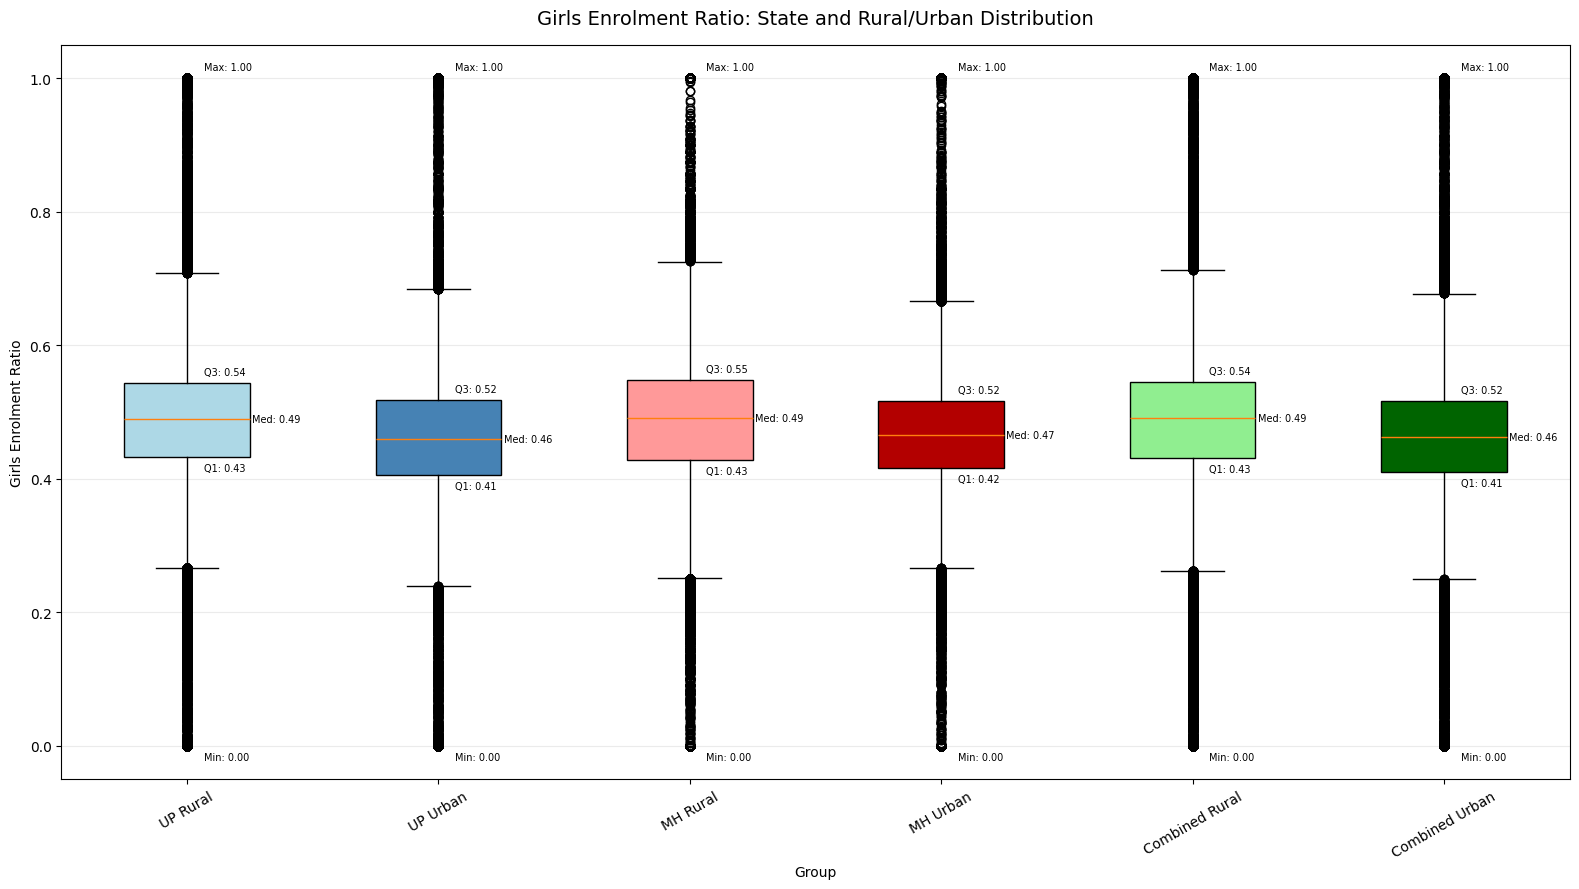

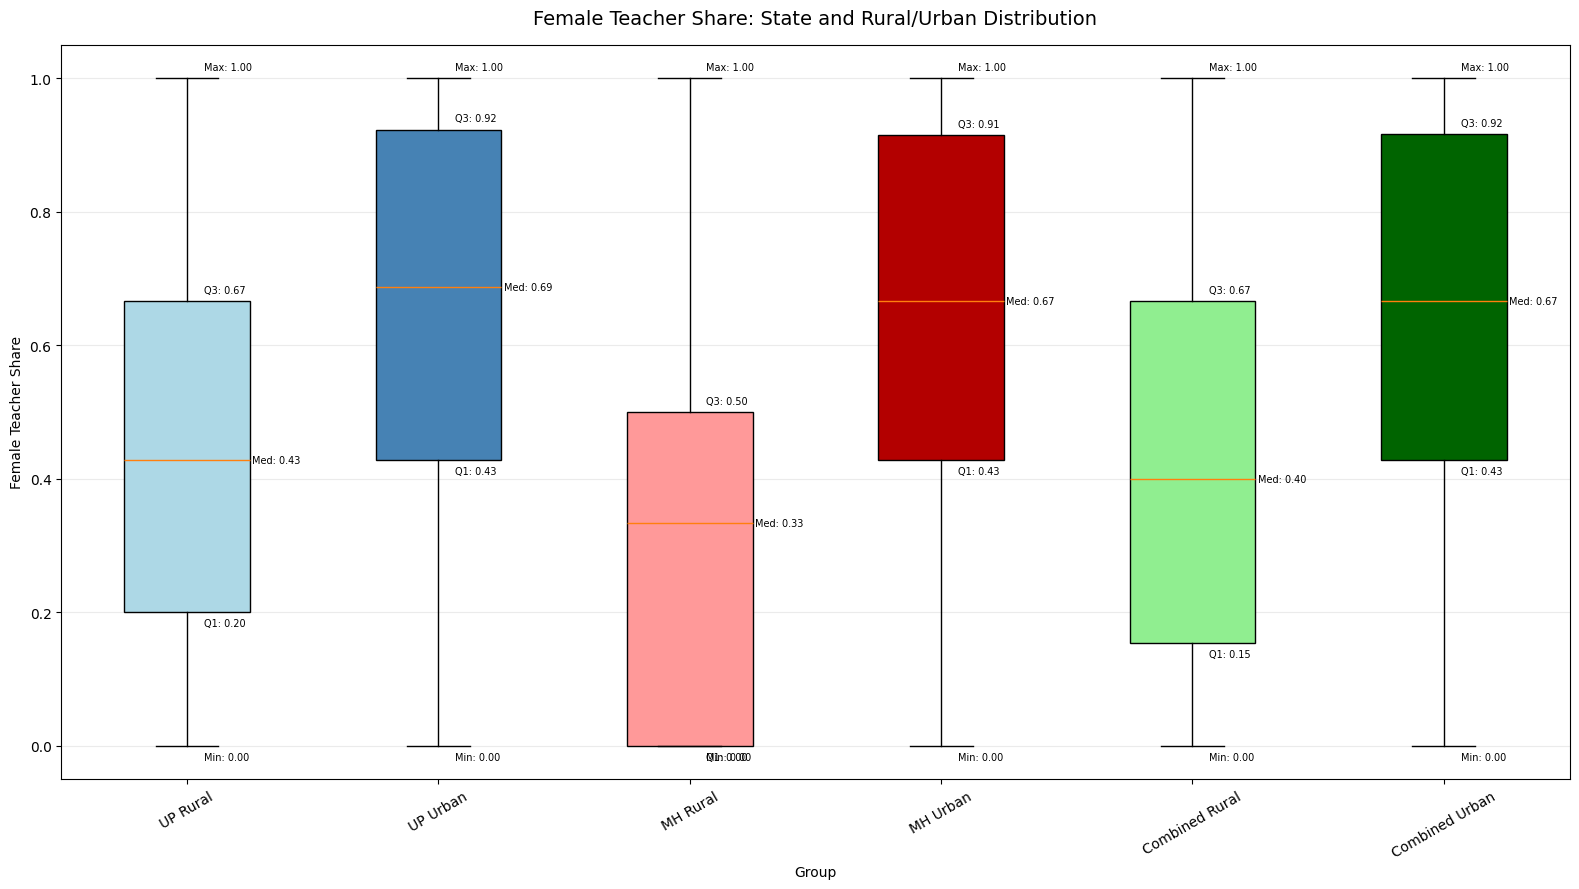

In [9]:
import matplotlib.pyplot as plt
import os

# ---------------------------------------------------------
# Create output folder
# ---------------------------------------------------------

os.makedirs("images", exist_ok=True)


# ---------------------------------------------------------
# Groups
# ---------------------------------------------------------

groups = {
    "UP Rural": combined_gender_data[
        (combined_gender_data["State"] == "Uttar Pradesh") &
        (combined_gender_data["rural_urban"] == "Rural")
    ],

    "UP Urban": combined_gender_data[
        (combined_gender_data["State"] == "Uttar Pradesh") &
        (combined_gender_data["rural_urban"] == "Urban")
    ],

    "MH Rural": combined_gender_data[
        (combined_gender_data["State"] == "Maharashtra") &
        (combined_gender_data["rural_urban"] == "Rural")
    ],

    "MH Urban": combined_gender_data[
        (combined_gender_data["State"] == "Maharashtra") &
        (combined_gender_data["rural_urban"] == "Urban")
    ],

    "Combined Rural": combined_gender_data[
        combined_gender_data["rural_urban"] == "Rural"
    ],

    "Combined Urban": combined_gender_data[
        combined_gender_data["rural_urban"] == "Urban"
    ]
}


# ---------------------------------------------------------
# Variables
# ---------------------------------------------------------

variables = [
    ("girls_enrolment_ratio", "Girls Enrolment Ratio"),
    ("female_teacher_share", "Female Teacher Share")
]


# ---------------------------------------------------------
# Colors
# Rural = lighter
# Urban = darker
# ---------------------------------------------------------

colors = [
    "#ADD8E6",   # UP Rural
    "#4682B4",   # UP Urban

    "#FF9999",   # MH Rural
    "#B30000",   # MH Urban

    "#90EE90",   # Combined Rural
    "#006400"    # Combined Urban
]


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

for variable, title in variables:

    labels = [
        "UP Rural",
        "UP Urban",
        "MH Rural",
        "MH Urban",
        "Combined Rural",
        "Combined Urban"
    ]

    data = [
        groups["UP Rural"][variable].dropna(),
        groups["UP Urban"][variable].dropna(),

        groups["MH Rural"][variable].dropna(),
        groups["MH Urban"][variable].dropna(),

        groups["Combined Rural"][variable].dropna(),
        groups["Combined Urban"][variable].dropna()
    ]

    fig, ax = plt.subplots(figsize=(16, 9))

    # -----------------------------------------------------
    # Boxplot
    # -----------------------------------------------------

    box = ax.boxplot(
        data,
        labels=labels,
        patch_artist=True,
        showfliers=True
    )

    # Apply colors
    for patch, color in zip(box["boxes"], colors):
        patch.set_facecolor(color)

    # -----------------------------------------------------
    # Titles and labels
    # -----------------------------------------------------

    ax.set_title(
        f"{title}: State and Rural/Urban Distribution",
        fontsize=14,
        pad=15
    )

    ax.set_xlabel("Group")
    ax.set_ylabel(title)

    ax.grid(
        axis="y",
        alpha=0.25
    )

    # -----------------------------------------------------
    # Statistics labels
    # -----------------------------------------------------

    for i, values in enumerate(data, start=1):

        minimum = values.min()
        q1 = values.quantile(0.25)
        median = values.quantile(0.50)
        q3 = values.quantile(0.75)
        maximum = values.max()

        stats = [
            (minimum, "Min"),
            (q1, "Q1"),
            (median, "Med"),
            (q3, "Q3"),
            (maximum, "Max")
        ]

        for value, label in stats:

            if value < median:
                x_offset = 12
                y_offset = -8

            elif value > median:
                x_offset = 12
                y_offset = 8

            else:
                x_offset = 47
                y_offset = 0

            ax.annotate(
                f"{label}: {value:.2f}",
                xy=(i, value),
                xytext=(x_offset, y_offset),
                textcoords="offset points",
                fontsize=7,
                ha="left",
                va="center"
            )

    # -----------------------------------------------------
    # Formatting
    # -----------------------------------------------------

    plt.xticks(rotation=30)
    plt.tight_layout()

    # -----------------------------------------------------
    # Save as SVG
    # -----------------------------------------------------

    filename = f"{variable}_rural_urban_boxplot.svg"

    plt.savefig(
        os.path.join("images", filename),
        format="svg",
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

In [10]:
def count_outliers(series):
    x = series.dropna()

    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = x[(x < lower_bound) | (x > upper_bound)]

    return {
        "N": len(x),
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower bound": lower_bound,
        "Upper bound": upper_bound,
        "Outlier count": len(outliers),
        "Outlier %": len(outliers) / len(x) * 100
    }


results = []


# ---------------------------------------------------------
# Groups
# ---------------------------------------------------------

groups = {

    # Overall groups
    "UP": combined_gender_data[
        combined_gender_data["State"] == "Uttar Pradesh"
    ],

    "MH": combined_gender_data[
        combined_gender_data["State"] == "Maharashtra"
    ],

    "Combined": combined_gender_data,

    # Rural / Urban groups
    "UP Rural": combined_gender_data[
        (combined_gender_data["State"] == "Uttar Pradesh") &
        (combined_gender_data["rural_urban"] == "Rural")
    ],

    "UP Urban": combined_gender_data[
        (combined_gender_data["State"] == "Uttar Pradesh") &
        (combined_gender_data["rural_urban"] == "Urban")
    ],

    "MH Rural": combined_gender_data[
        (combined_gender_data["State"] == "Maharashtra") &
        (combined_gender_data["rural_urban"] == "Rural")
    ],

    "MH Urban": combined_gender_data[
        (combined_gender_data["State"] == "Maharashtra") &
        (combined_gender_data["rural_urban"] == "Urban")
    ],

    "Combined Rural": combined_gender_data[
        combined_gender_data["rural_urban"] == "Rural"
    ],

    "Combined Urban": combined_gender_data[
        combined_gender_data["rural_urban"] == "Urban"
    ]
}


# ---------------------------------------------------------
# Variables
# ---------------------------------------------------------

variables = {
    "Girls Enrolment Ratio": "girls_enrolment_ratio",
    "Female Teacher Share": "female_teacher_share"
}


# ---------------------------------------------------------
# Calculate outliers
# ---------------------------------------------------------

for group_name, df in groups.items():

    for variable_name, column in variables.items():

        result = count_outliers(df[column])

        results.append({
            "Group": group_name,
            "Variable": variable_name,
            **result
        })


# ---------------------------------------------------------
# Final table
# ---------------------------------------------------------

outlier_table = pd.DataFrame(results)

outlier_table.round(4)

,Group,Variable,N,Q1,Q3,IQR,Lower bound,Upper bound,Outlier count,Outlier %
0,UP,Girls Enrolment Ratio,264117,0.4286,0.5400,0.1114,0.2614,0.7071,15814,5.9875
1,UP,Female Teacher Share,264117,0.2500,0.7143,0.4643,-0.4464,1.4107,0,0.0000
2,MH,Girls Enrolment Ratio,108130,0.4253,0.5405,0.1153,0.2524,0.7134,8752,8.0940
3,MH,Female Teacher Share,108130,0.0000,0.7000,0.7000,-1.0500,1.7500,0,0.0000
4,Combined,Girls Enrolment Ratio,372247,0.4274,0.5401,0.1127,0.2582,0.7092,24482,6.5768
5,Combined,Female Teacher Share,372247,0.2000,0.7143,0.5143,-0.5714,1.4857,0,0.0000
6,UP Rural,Girls Enrolment Ratio,223641,0.4324,0.5429,0.1104,0.2668,0.7085,11273,5.0407
7,UP Rural,Female Teacher Share,223641,0.2000,0.6667,0.4667,-0.5000,1.3667,0,0.0000
8,UP Urban,Girls Enrolment Ratio,40476,0.4061,0.5172,0.1111,0.2394,0.6839,4640,11.4636
9,UP Urban,Female Teacher Share,40476,0.4286,0.9231,0.4945,-0.3132,1.6648,0,0.0000


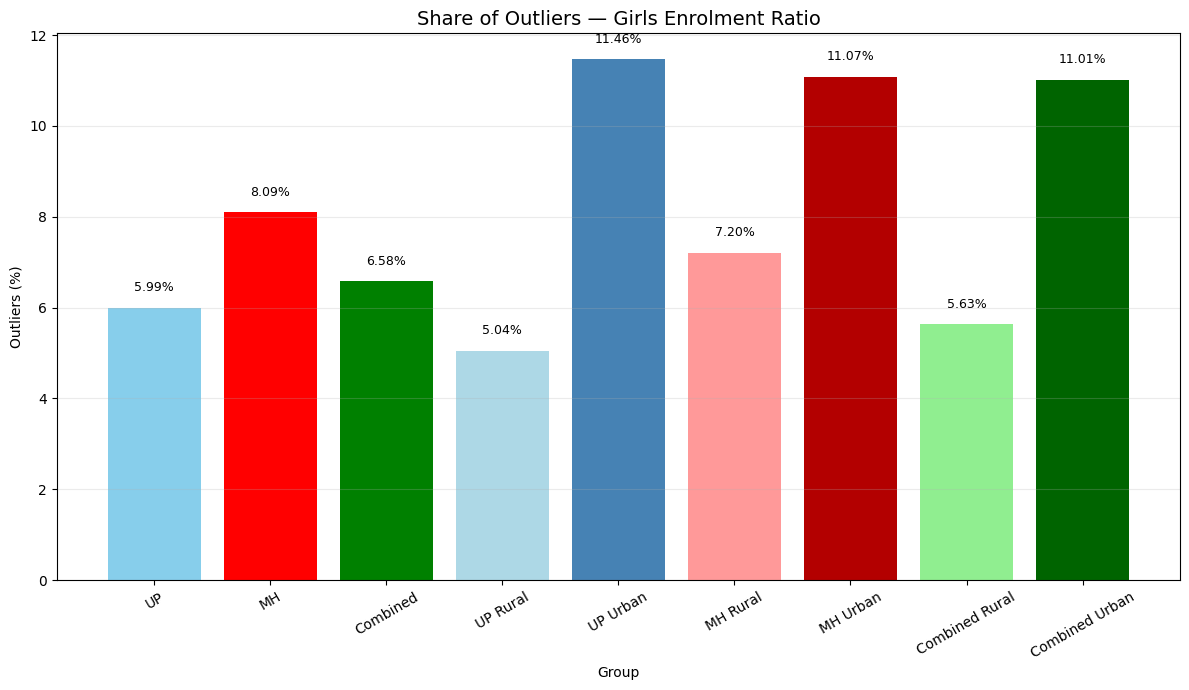

No outliers found for Female Teacher Share


In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------------------
# Plot share of outliers — only groups with outliers
# ---------------------------------------------------------

plot_colors = {
    "UP": "#87CEEB",
    "MH": "#FF0000",
    "Combined": "#008000",
    "UP Rural": "#ADD8E6",
    "UP Urban": "#4682B4",
    "MH Rural": "#FF9999",
    "MH Urban": "#B30000",
    "Combined Rural": "#90EE90",
    "Combined Urban": "#006400"
}

groups_order = [
    "UP",
    "MH",
    "Combined",
    "UP Rural",
    "UP Urban",
    "MH Rural",
    "MH Urban",
    "Combined Rural",
    "Combined Urban"
]

for variable_name in variables.keys():

    # Keep ONLY groups having at least one outlier
    plot_data = outlier_table[
        (outlier_table["Variable"] == variable_name) &
        (outlier_table["Outlier count"] > 0)
    ].copy()

    # Order groups
    plot_data["Group"] = pd.Categorical(
        plot_data["Group"],
        categories=groups_order,
        ordered=True
    )

    plot_data = plot_data.sort_values("Group")

    # Skip plot if no outliers exist
    if plot_data.empty:
        print(f"No outliers found for {variable_name}")
        continue

    # -----------------------------------------------------
    # Plot
    # -----------------------------------------------------

    fig, ax = plt.subplots(figsize=(12, 7))

    bars = ax.bar(
        plot_data["Group"],
        plot_data["Outlier %"],
        color=[
            plot_colors[group]
            for group in plot_data["Group"]
        ]
    )

    # -----------------------------------------------------
    # Percentage labels
    # -----------------------------------------------------

    for bar, value in zip(
        bars,
        plot_data["Outlier %"]
    ):

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{value:.2f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

    # -----------------------------------------------------
    # Formatting
    # -----------------------------------------------------

    ax.set_title(
        f"Share of Outliers — {variable_name}",
        fontsize=14
    )

    ax.set_xlabel("Group")
    ax.set_ylabel("Outliers (%)")

    ax.grid(
        axis="y",
        alpha=0.25
    )

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()

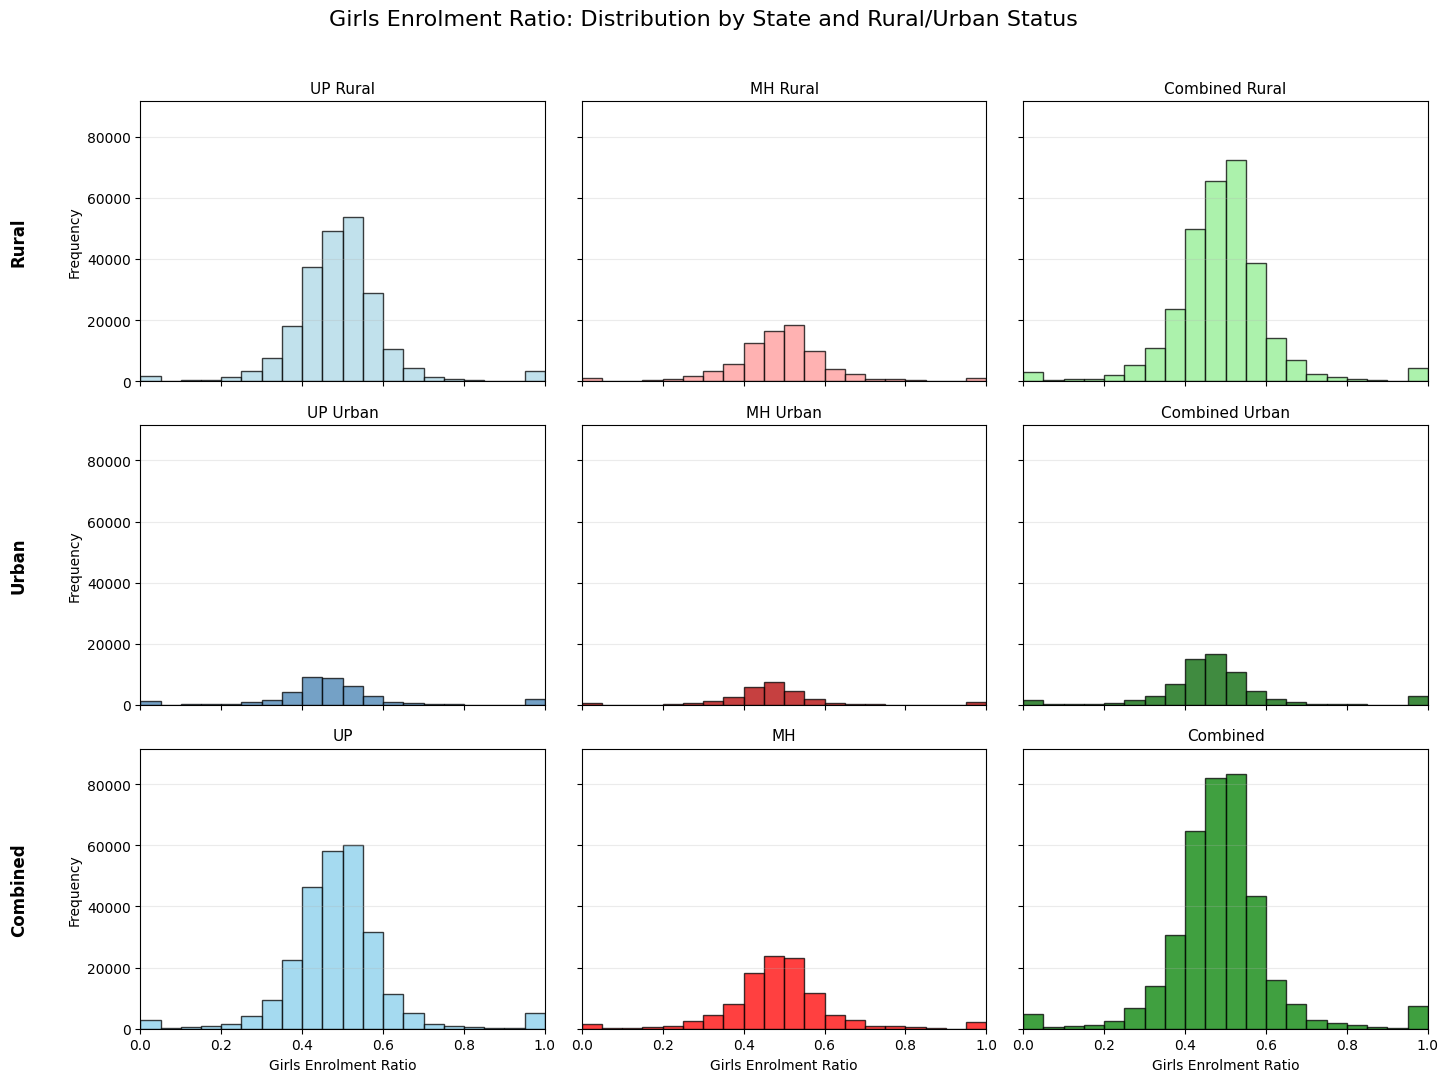

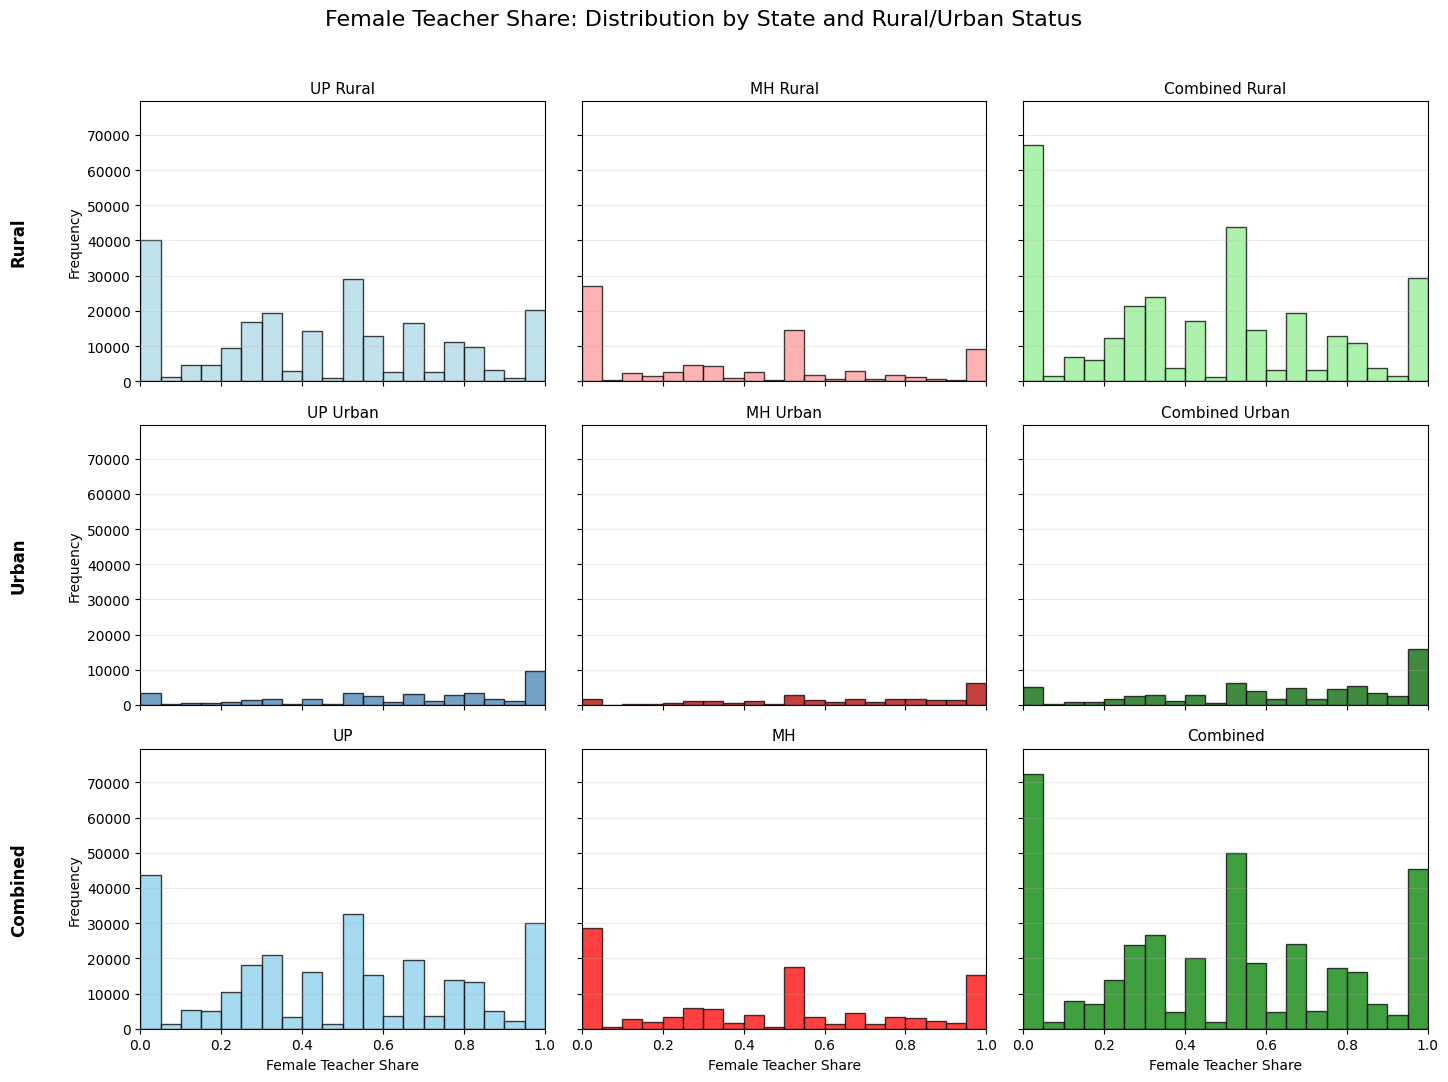

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os


# ---------------------------------------------------------
# Create output folder
# ---------------------------------------------------------

os.makedirs("images", exist_ok=True)


# ---------------------------------------------------------
# Standardized colors
#
# State:
# UP       = Sky Blue
# MH       = Red
# Combined = Green
#
# Rural = lighter
# Urban = darker
# Overall = base color
# ---------------------------------------------------------

plot_colors = {
    "UP Rural": "#ADD8E6",
    "UP Urban": "#4682B4",

    "MH Rural": "#FF9999",
    "MH Urban": "#B30000",

    "Combined Rural": "#90EE90",
    "Combined Urban": "#006400",

    "UP": "#87CEEB",
    "MH": "#FF0000",
    "Combined": "#008000"
}


# ---------------------------------------------------------
# Groups arranged as:
#
#             UP          MH          Combined
# Rural       UP Rural    MH Rural    Combined Rural
# Urban       UP Urban    MH Urban    Combined Urban
# Combined    UP          MH          Combined
# ---------------------------------------------------------

groups = [
    [
        ("UP Rural", combined_gender_data[
            (combined_gender_data["State"] == "Uttar Pradesh") &
            (combined_gender_data["rural_urban"] == "Rural")
        ]),

        ("MH Rural", combined_gender_data[
            (combined_gender_data["State"] == "Maharashtra") &
            (combined_gender_data["rural_urban"] == "Rural")
        ]),

        ("Combined Rural", combined_gender_data[
            combined_gender_data["rural_urban"] == "Rural"
        ])
    ],

    [
        ("UP Urban", combined_gender_data[
            (combined_gender_data["State"] == "Uttar Pradesh") &
            (combined_gender_data["rural_urban"] == "Urban")
        ]),

        ("MH Urban", combined_gender_data[
            (combined_gender_data["State"] == "Maharashtra") &
            (combined_gender_data["rural_urban"] == "Urban")
        ]),

        ("Combined Urban", combined_gender_data[
            combined_gender_data["rural_urban"] == "Urban"
        ])
    ],

    [
        ("UP", combined_gender_data[
            combined_gender_data["State"] == "Uttar Pradesh"
        ]),

        ("MH", combined_gender_data[
            combined_gender_data["State"] == "Maharashtra"
        ]),

        ("Combined", combined_gender_data)
    ]
]


# ---------------------------------------------------------
# Variables
# ---------------------------------------------------------

variables = [
    ("girls_enrolment_ratio", "Girls Enrolment Ratio"),
    ("female_teacher_share", "Female Teacher Share")
]


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

for variable, title in variables:

    # -----------------------------------------------------
    # Common X-axis
    # -----------------------------------------------------

    all_values = pd.concat([
        df[variable].dropna()
        for row in groups
        for group_name, df in row
    ])

    x_min = all_values.min()
    x_max = all_values.max()

    # Same bins for every subplot
    bin_edges = np.linspace(
        x_min,
        x_max,
        21
    )


    # -----------------------------------------------------
    # Common Y-axis
    # -----------------------------------------------------

    max_frequency = 0

    for row in groups:

        for group_name, df in row:

            x = df[variable].dropna()

            counts, _ = np.histogram(
                x,
                bins=bin_edges
            )

            max_frequency = max(
                max_frequency,
                counts.max()
            )

    y_max = max_frequency * 1.1


    # -----------------------------------------------------
    # Create 3 × 3 figure
    # -----------------------------------------------------

    fig, axes = plt.subplots(
        3,
        3,
        figsize=(15, 11),
        sharex=True,
        sharey=True
    )


    # -----------------------------------------------------
    # Plot
    # -----------------------------------------------------

    for row in range(3):

        for col in range(3):

            ax = axes[row, col]

            group_name, df = groups[row][col]

            x = df[variable].dropna()

            ax.hist(
                x,
                bins=bin_edges,
                color=plot_colors[group_name],
                edgecolor="black",
                alpha=0.75
            )

            ax.set_title(
                group_name,
                fontsize=11
            )

            ax.set_xlim(
                x_min,
                x_max
            )

            ax.set_ylim(
                0,
                y_max
            )

            ax.grid(
                axis="y",
                alpha=0.25
            )


    # -----------------------------------------------------
    # X-axis labels
    # -----------------------------------------------------

    for ax in axes[2, :]:
        ax.set_xlabel(title)


    # -----------------------------------------------------
    # Y-axis labels
    # -----------------------------------------------------

    for ax in axes[:, 0]:
        ax.set_ylabel("Frequency")


    # -----------------------------------------------------
    # Row labels
    # -----------------------------------------------------

    axes[0, 0].text(
        -0.30,
        0.5,
        "Rural",
        transform=axes[0, 0].transAxes,
        rotation=90,
        va="center",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

    axes[1, 0].text(
        -0.30,
        0.5,
        "Urban",
        transform=axes[1, 0].transAxes,
        rotation=90,
        va="center",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

    axes[2, 0].text(
        -0.30,
        0.5,
        "Combined",
        transform=axes[2, 0].transAxes,
        rotation=90,
        va="center",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )


    # -----------------------------------------------------
    # Overall title
    # -----------------------------------------------------

    fig.suptitle(
        f"{title}: Distribution by State and Rural/Urban Status",
        fontsize=16
    )


    # -----------------------------------------------------
    # Layout
    # -----------------------------------------------------

    plt.tight_layout(
        rect=[0.04, 0, 1, 0.96]
    )


    # -----------------------------------------------------
    # Save as SVG
    # -----------------------------------------------------

    filename = f"{variable}_state_rural_urban_distribution.svg"

    plt.savefig(
        os.path.join("images", filename),
        format="svg",
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

<b> Observations </b>

<ul>
<li> which tendency relevant for which variable (mean/median)
<li> how spread out are the variables (based on mean and s.d.)
<li> what does the mode say
</ul>

#### Demonstrating Central Limit Theorem

<b> choosing variable Female Teacher Share in the combined dataset </b>

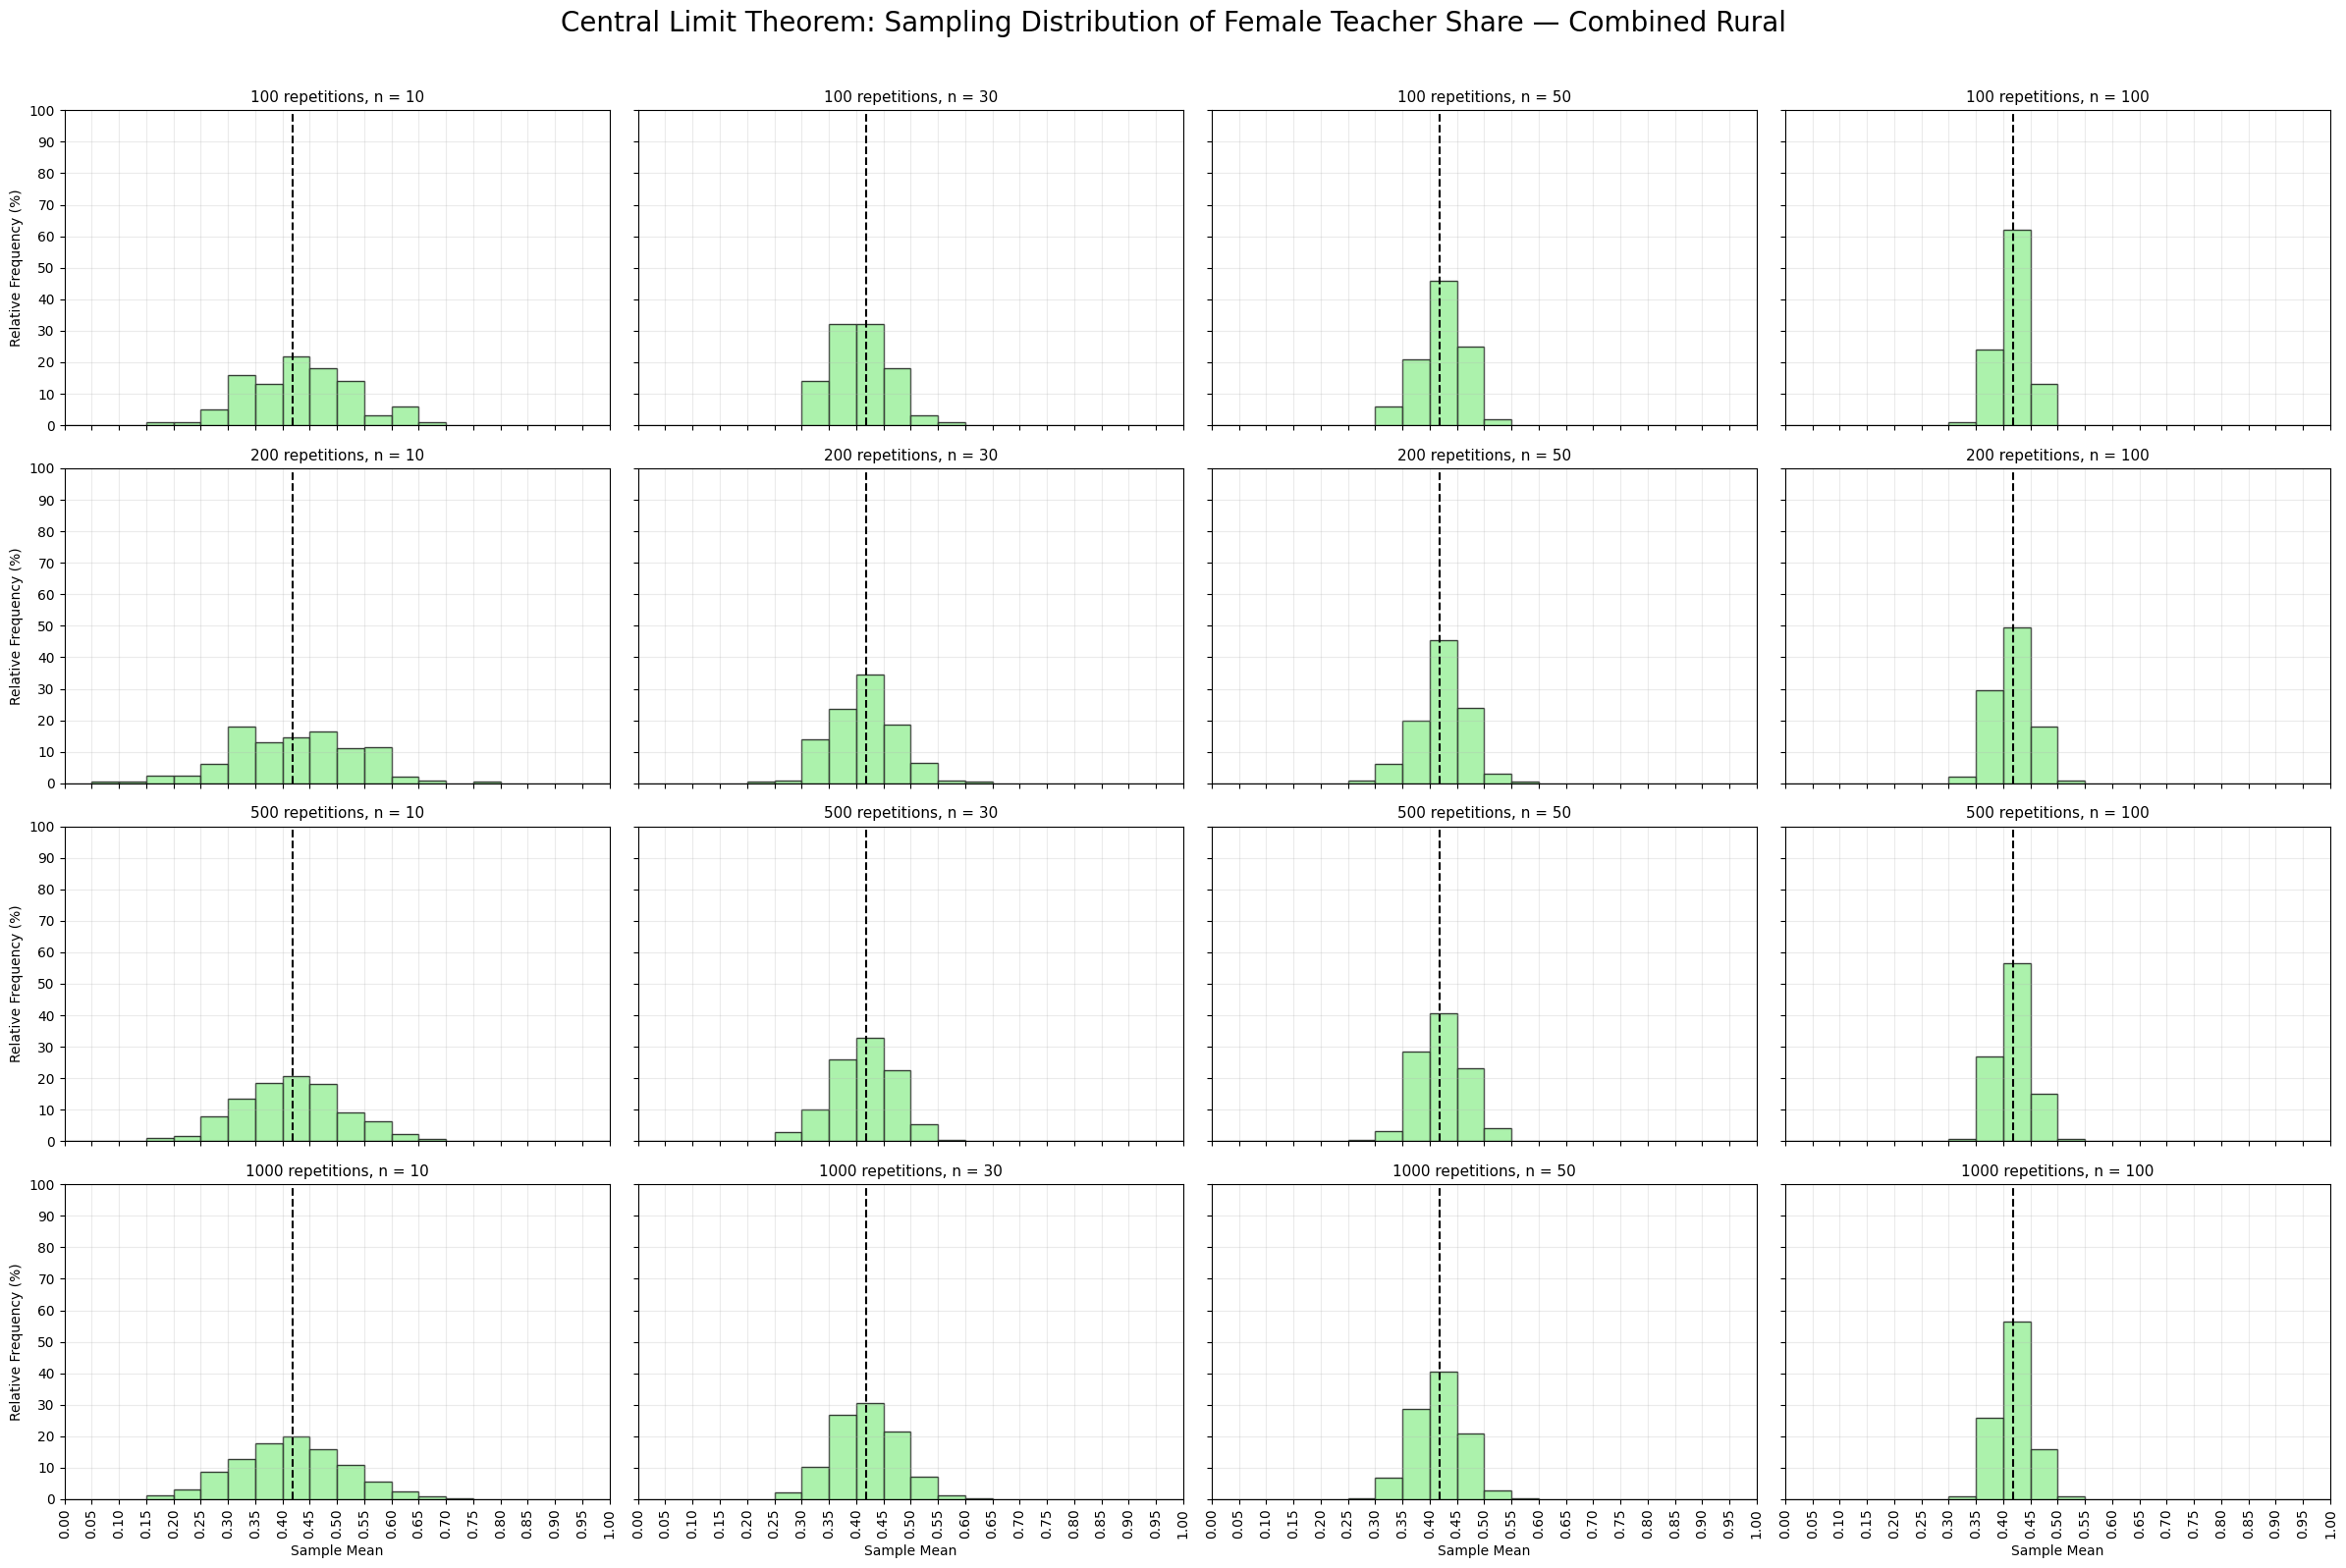

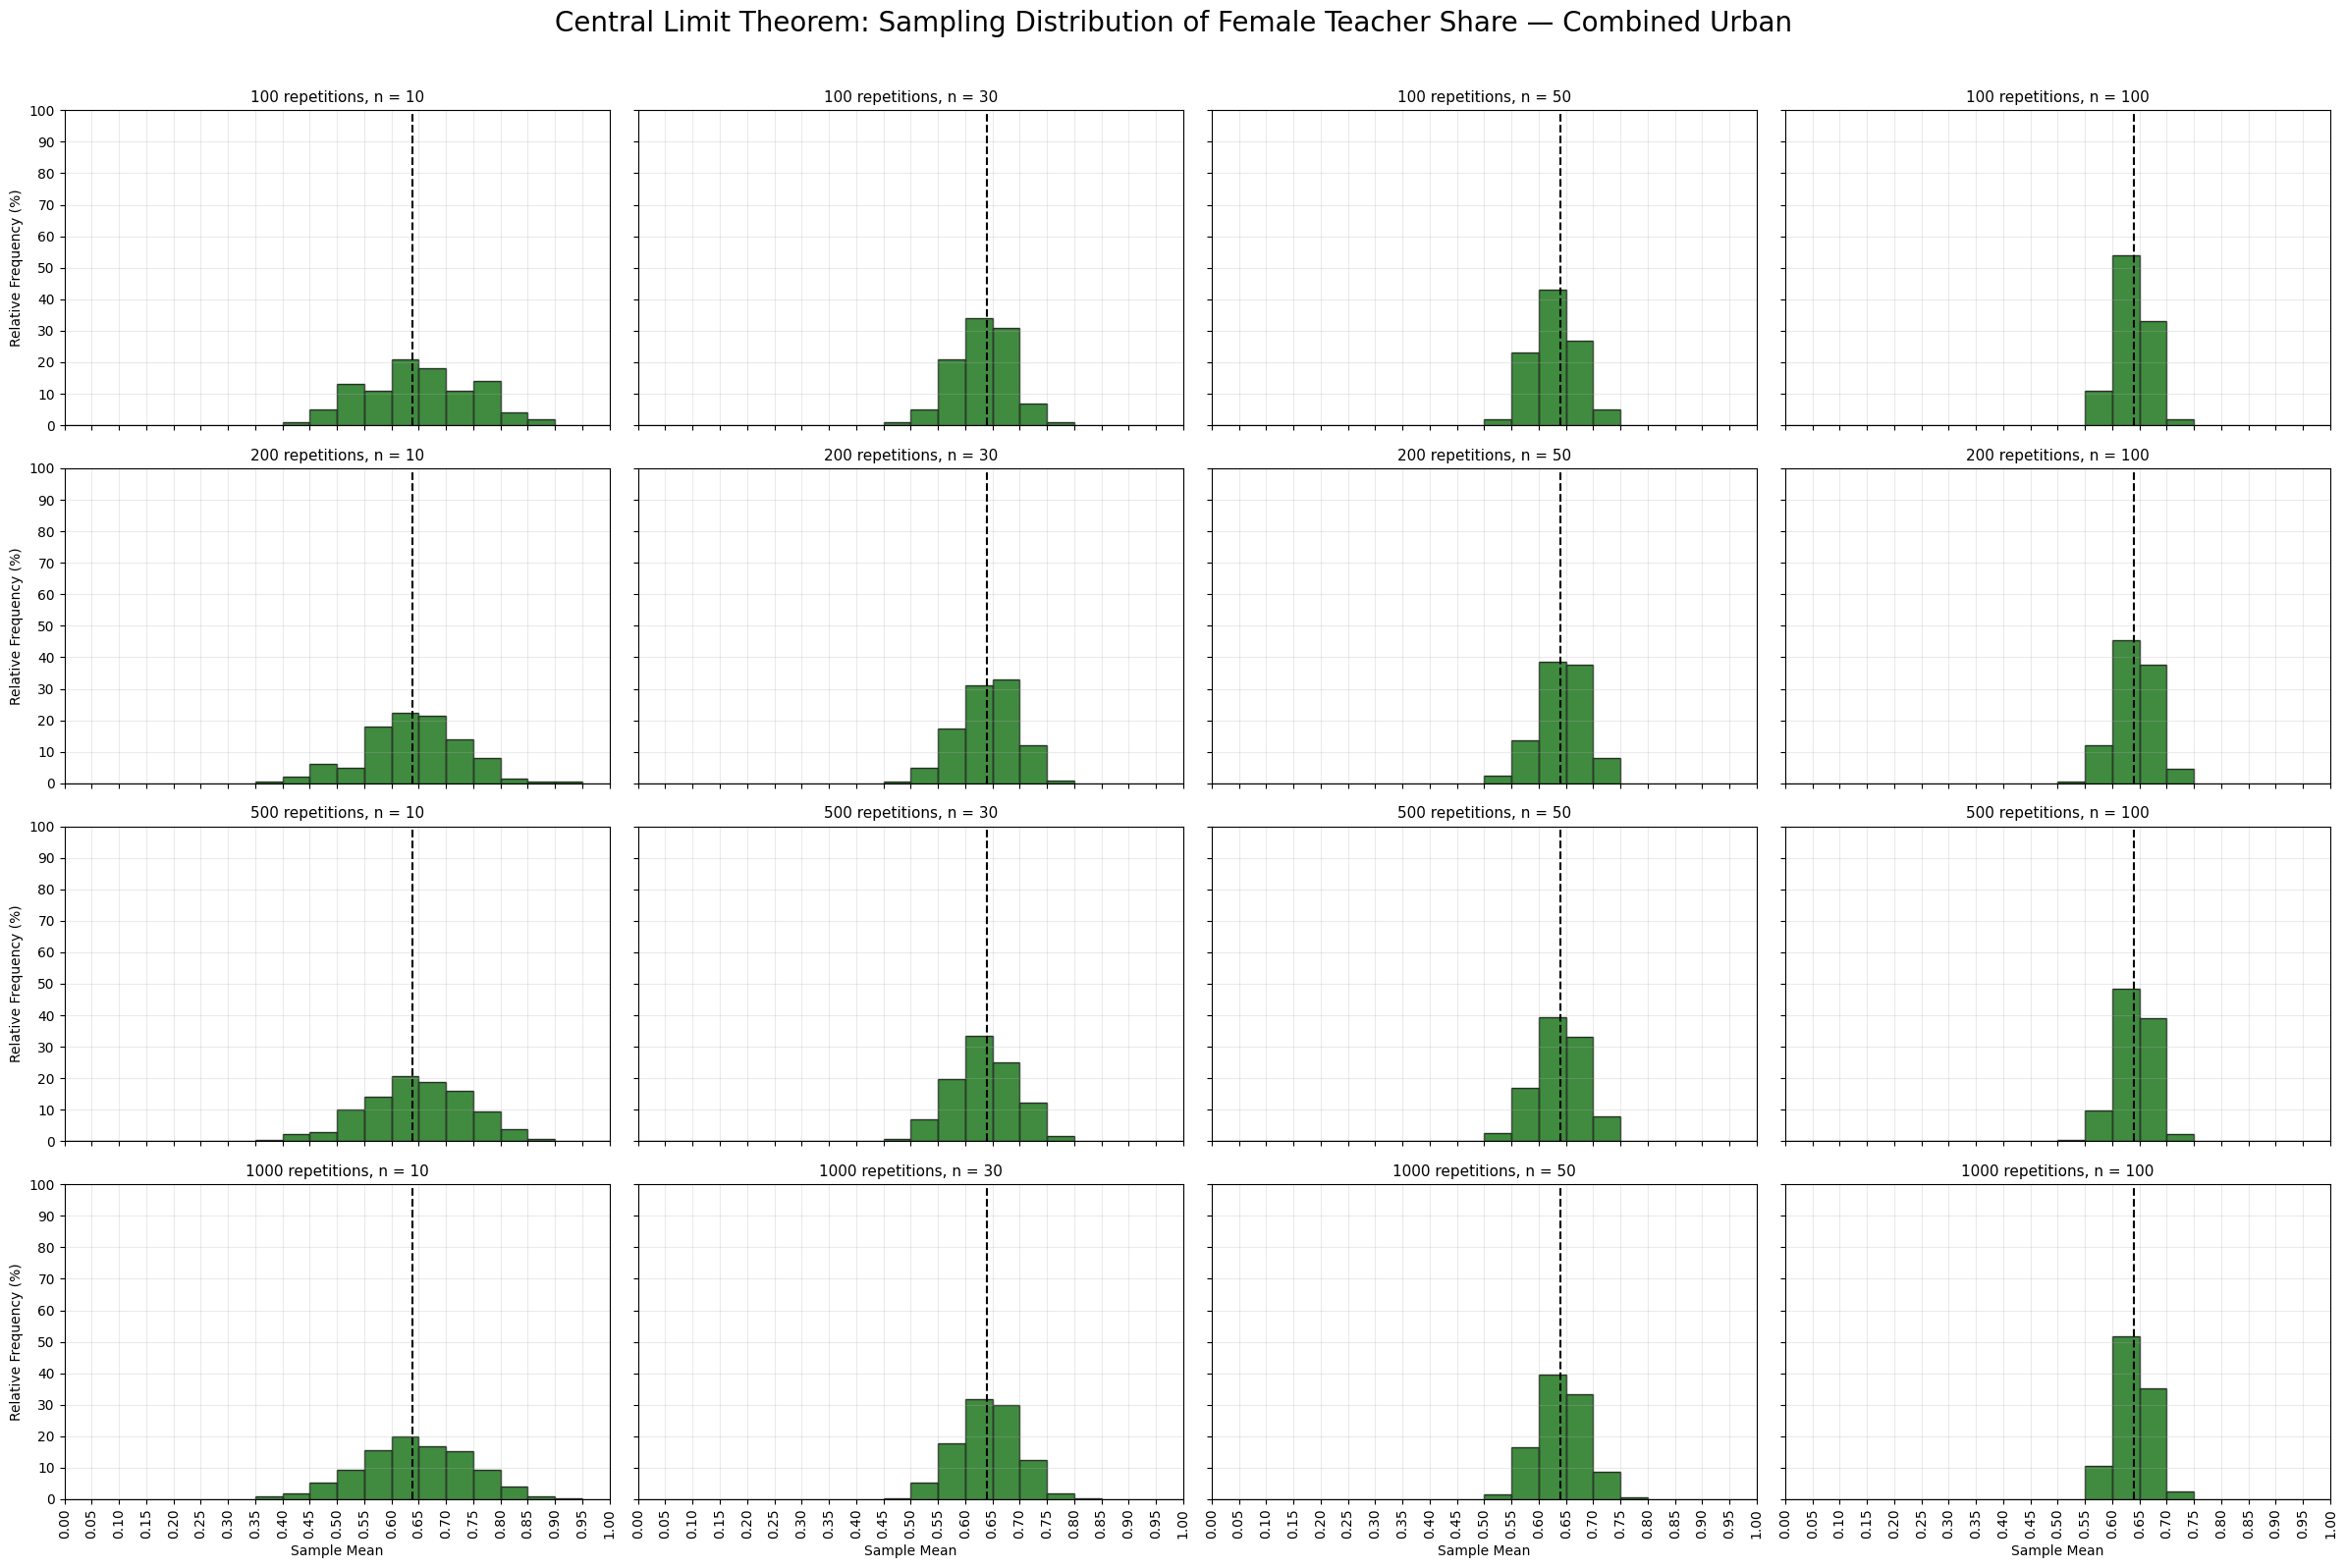

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ---------------------------------------------------------
# Create output folder
# ---------------------------------------------------------

os.makedirs("images", exist_ok=True)


# ---------------------------------------------------------
# Settings
# ---------------------------------------------------------

sample_sizes = [10, 30, 50, 100]
repetitions = [100, 200, 500, 1000]

rng = np.random.default_rng(42)


# ---------------------------------------------------------
# Standardized colors
# ---------------------------------------------------------

plot_colors = {
    "Combined Rural": "#90EE90",
    "Combined Urban": "#006400"
}


# ---------------------------------------------------------
# Rural and Urban populations
# ---------------------------------------------------------

populations = {
    "Combined Rural": combined_gender_data[
        combined_gender_data["rural_urban"] == "Rural"
    ]["female_teacher_share"].dropna().to_numpy(),

    "Combined Urban": combined_gender_data[
        combined_gender_data["rural_urban"] == "Urban"
    ]["female_teacher_share"].dropna().to_numpy()
}


# ---------------------------------------------------------
# Generate one figure for each population
# ---------------------------------------------------------

for population_name, population in populations.items():

    population_mean = population.mean()

    # -----------------------------------------------------
    # Generate sampling distributions
    # -----------------------------------------------------

    sampling_distributions = {}

    for reps in repetitions:

        for n in sample_sizes:

            sample_means = []

            for _ in range(reps):

                sample = rng.choice(
                    population,
                    size=n,
                    replace=False
                )

                sample_means.append(sample.mean())

            sampling_distributions[(reps, n)] = np.array(
                sample_means
            )


    # -----------------------------------------------------
    # Histogram bins
    # -----------------------------------------------------

    bins = np.linspace(0, 1, 21)


    # -----------------------------------------------------
    # Create 4 × 4 figure
    # -----------------------------------------------------

    fig, axes = plt.subplots(
        4,
        4,
        figsize=(24, 16),
        sharex=True,
        sharey=True
    )


    # -----------------------------------------------------
    # Plot sampling distributions
    # -----------------------------------------------------

    for row, reps in enumerate(repetitions):

        for col, n in enumerate(sample_sizes):

            ax = axes[row, col]

            values = sampling_distributions[(reps, n)]

            # Relative frequency (%)
            counts, bin_edges = np.histogram(
                values,
                bins=bins
            )

            relative_frequency_percent = (
                counts / len(values)
            ) * 100

            # Histogram
            ax.bar(
                bin_edges[:-1],
                relative_frequency_percent,
                width=np.diff(bin_edges),
                align="edge",
                color=plot_colors[population_name],
                edgecolor="black",
                alpha=0.75
            )

            # Population mean
            ax.axvline(
                population_mean,
                color="black",
                linestyle="--",
                linewidth=1.5
            )

            # Same scale
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 100)

            ax.set_xticks(
                np.arange(0, 1.01, 0.05)
            )

            ax.tick_params(
                axis="x",
                labelrotation=90
            )

            ax.set_yticks(
                np.arange(0, 101, 10)
            )

            # Title
            ax.set_title(
                f"{reps} repetitions, n = {n}",
                fontsize=11
            )

            ax.grid(
                axis="both",
                alpha=0.25
            )

            # X-axis label only bottom row
            if row == len(repetitions) - 1:
                ax.set_xlabel(
                    "Sample Mean",
                    fontsize=10
                )

            # Y-axis label only first column
            if col == 0:
                ax.set_ylabel(
                    "Relative Frequency (%)",
                    fontsize=10
                )


    # -----------------------------------------------------
    # Overall title
    # -----------------------------------------------------

    fig.suptitle(
        f"Central Limit Theorem: Sampling Distribution of "
        f"Female Teacher Share — {population_name}",
        fontsize=20,
        y=0.995
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.98]
    )


    # -----------------------------------------------------
    # Save as SVG
    # -----------------------------------------------------

    filename = (
        f"female_teacher_share_sampling_distribution_"
        f"{population_name.lower().replace(' ', '_')}.svg"
    )

    plt.savefig(
        os.path.join("images", filename),
        format="svg",
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

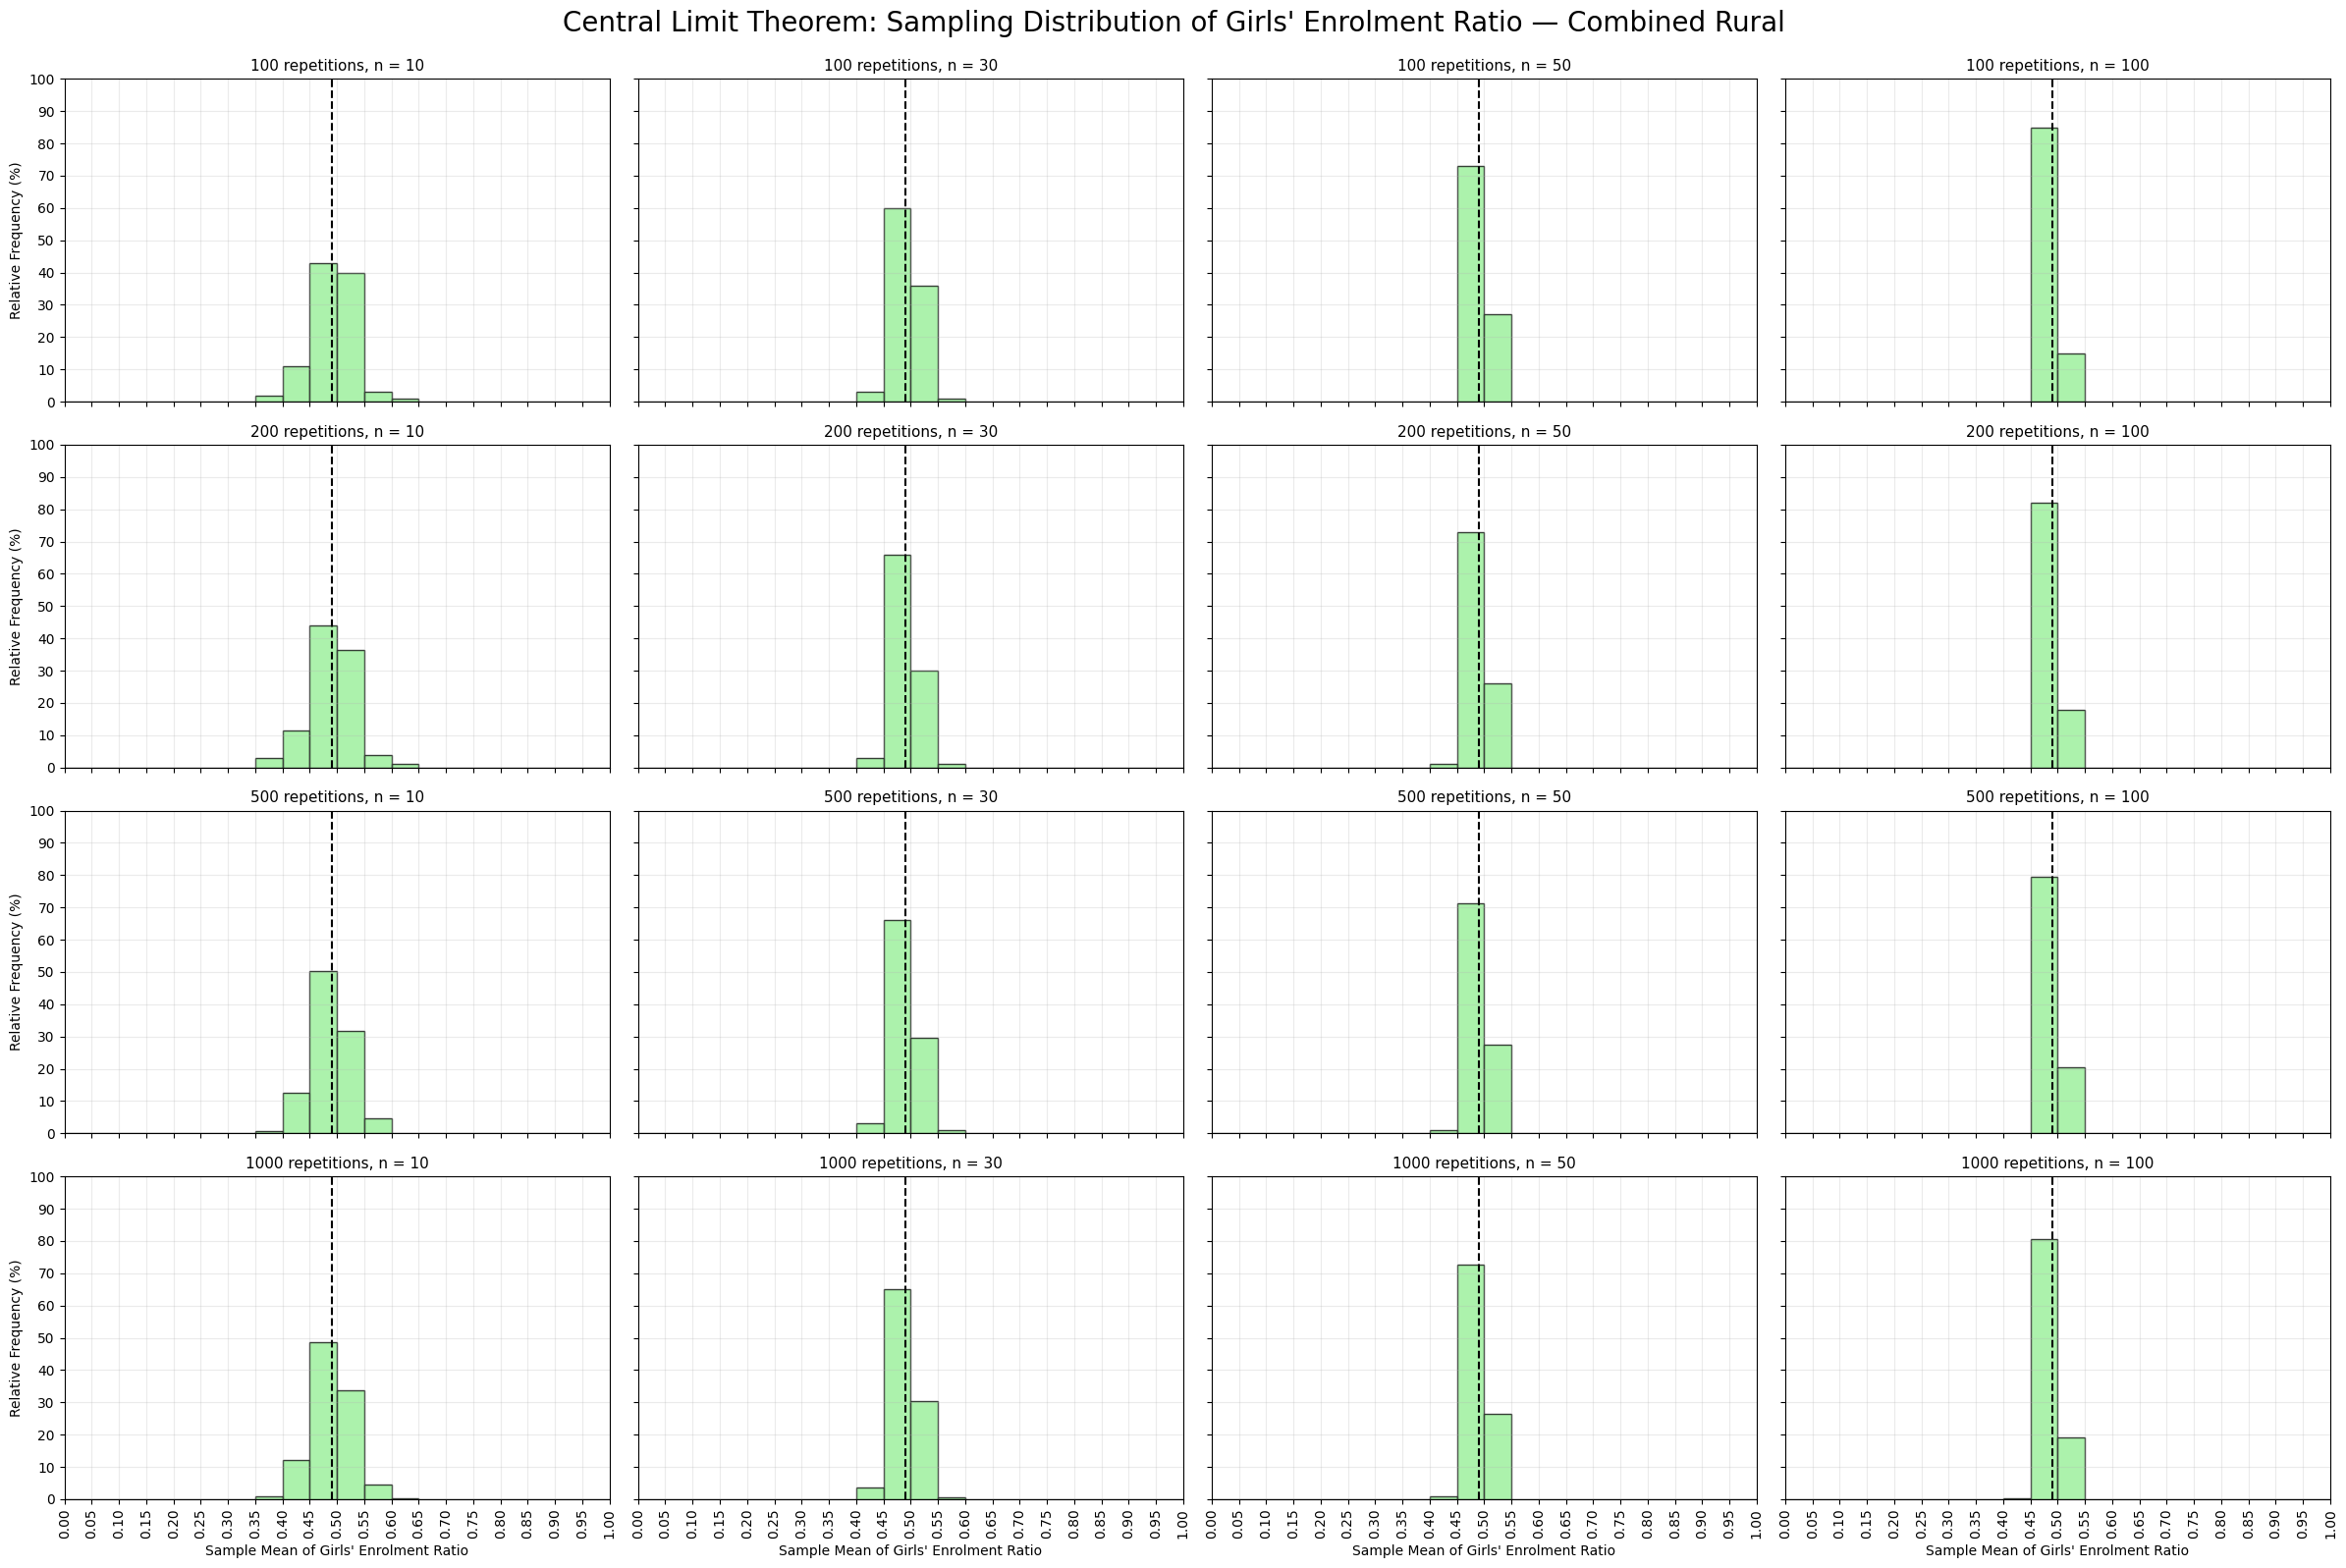

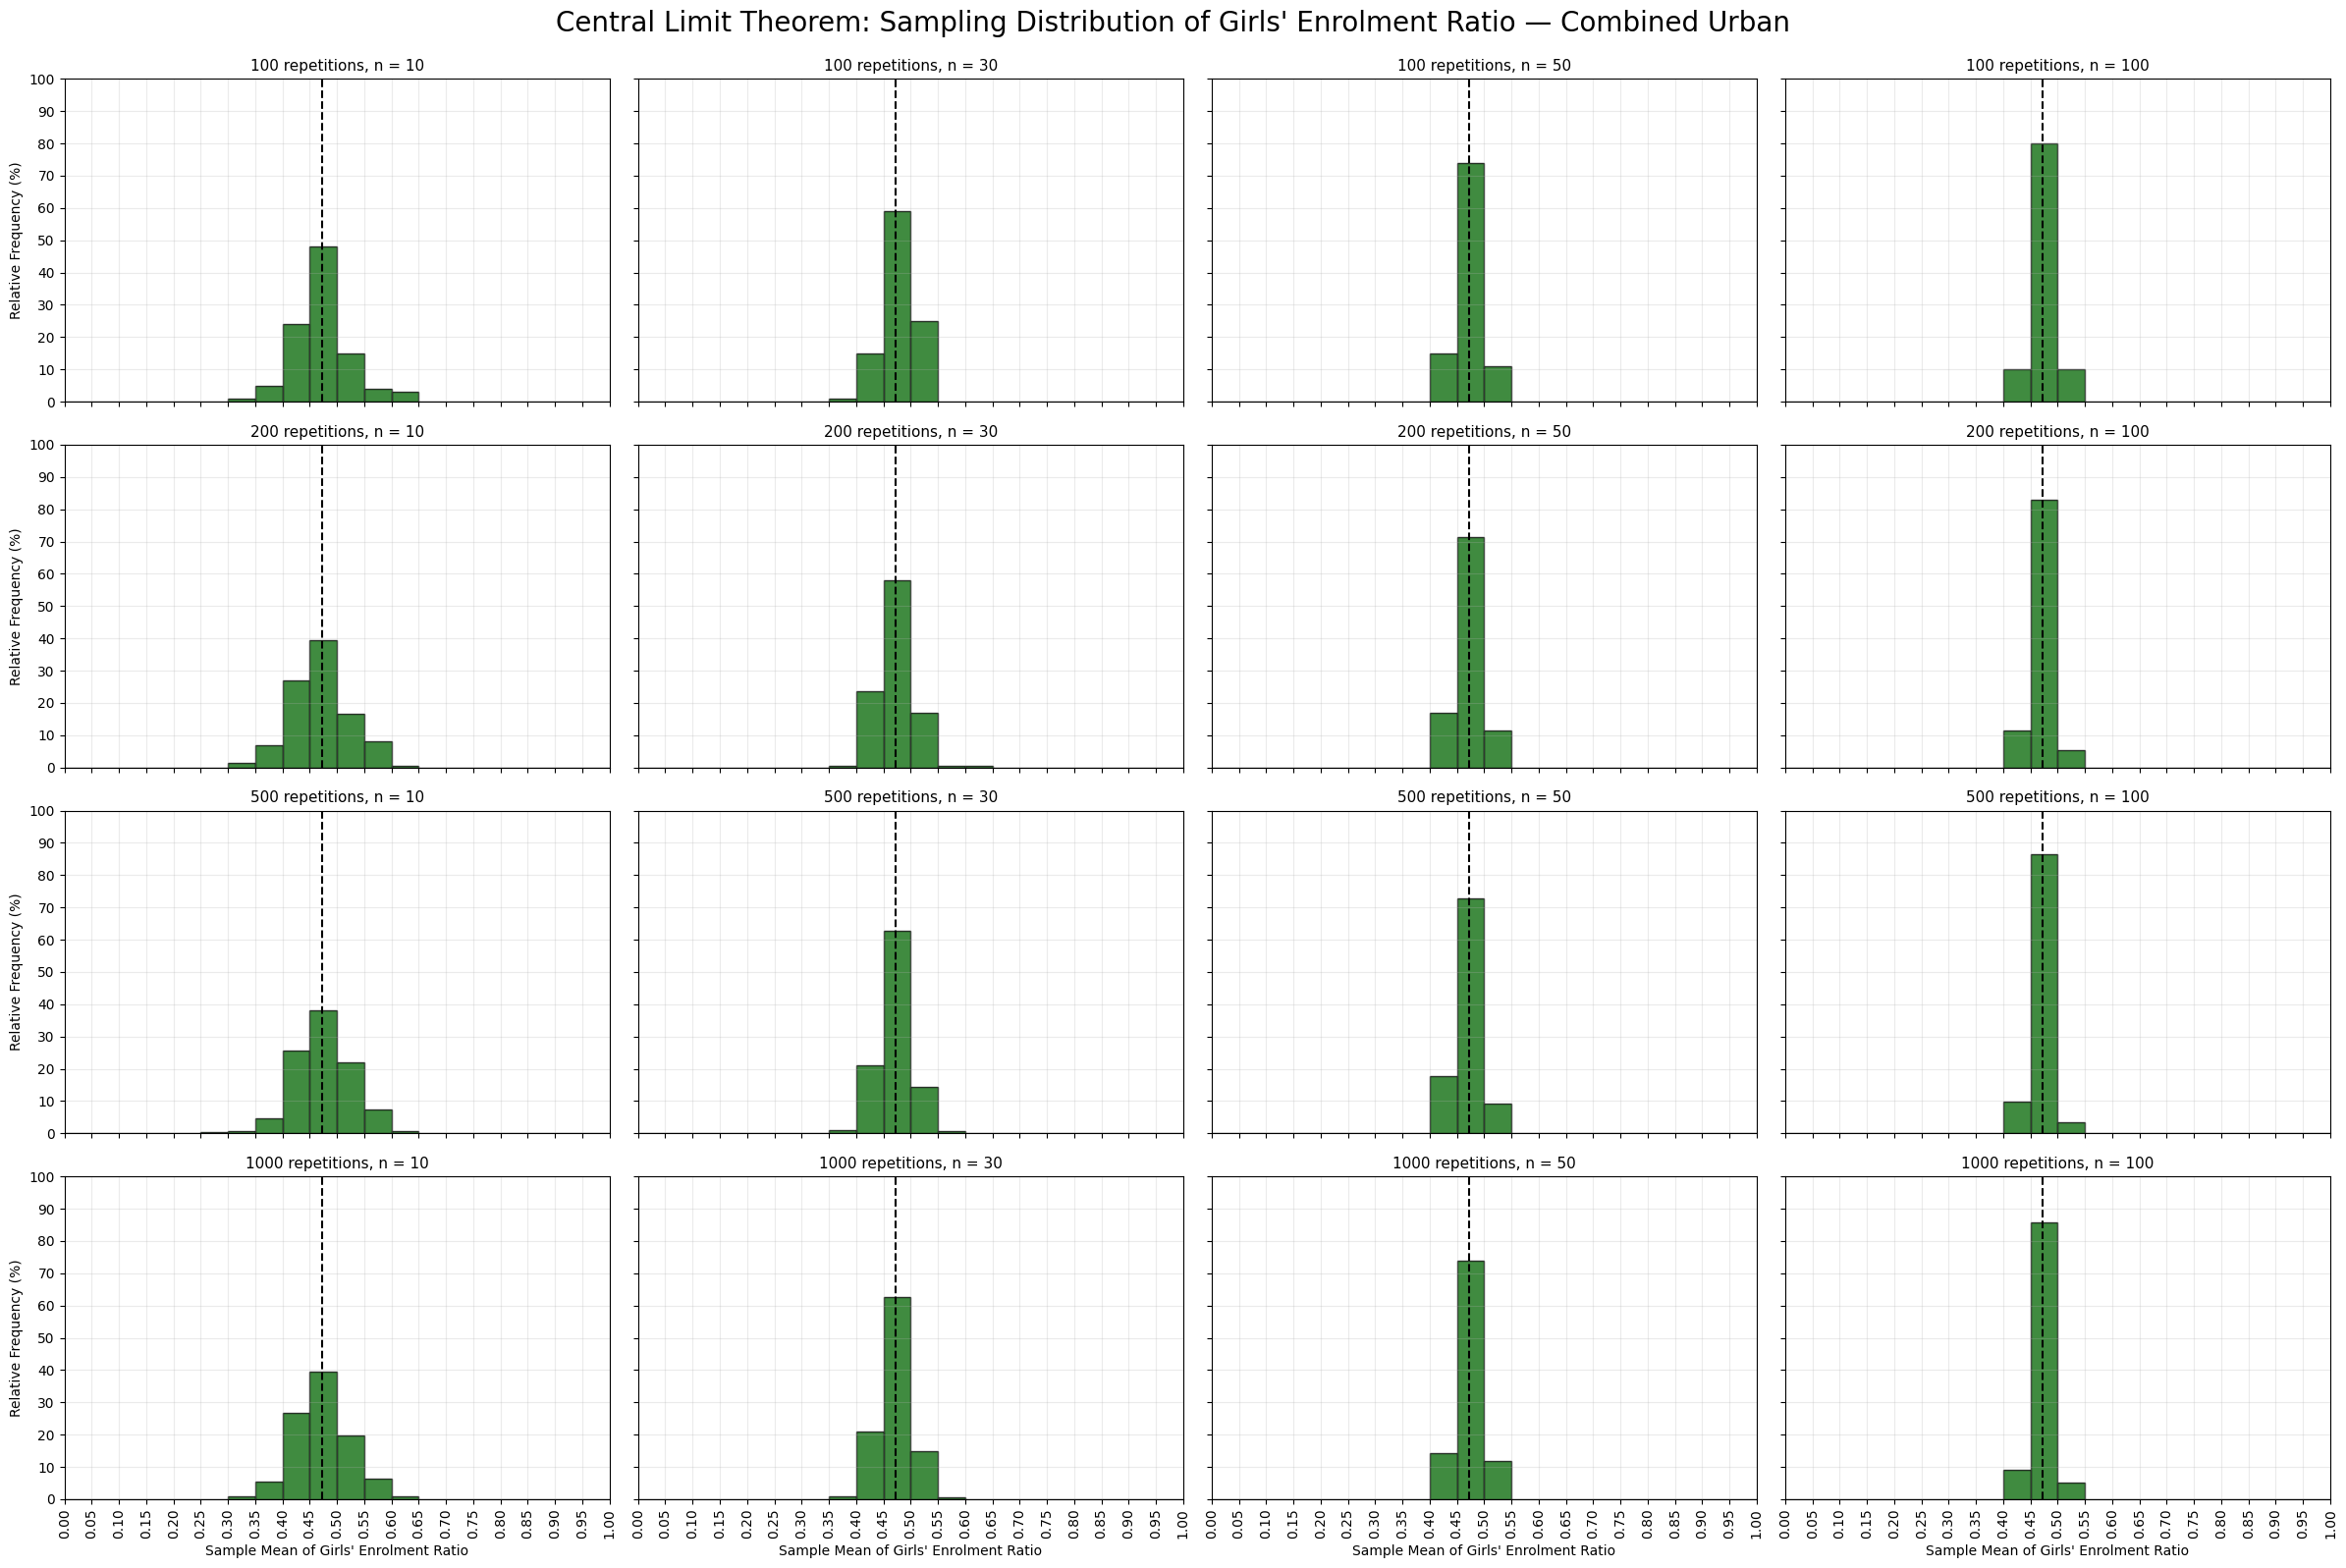

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Settings
# ---------------------------------------------------------

sample_sizes = [10, 30, 50, 100]
repetitions = [100, 200, 500, 1000]

# Fixed random seed
rng = np.random.default_rng(42)


# ---------------------------------------------------------
# Standardized colors
#
# Combined Rural = Light Green
# Combined Urban = Dark Green
# ---------------------------------------------------------

plot_colors = {
    "Combined Rural": "#90EE90",   # Light Green
    "Combined Urban": "#006400"    # Dark Green
}


# ---------------------------------------------------------
# Rural and Urban populations
# Using girls_enrolment_ratio
# ---------------------------------------------------------

populations = {
    "Combined Rural": combined_gender_data[
        combined_gender_data["rural_urban"] == "Rural"
    ]["girls_enrolment_ratio"].dropna().to_numpy(),

    "Combined Urban": combined_gender_data[
        combined_gender_data["rural_urban"] == "Urban"
    ]["girls_enrolment_ratio"].dropna().to_numpy()
}


# ---------------------------------------------------------
# Generate one figure for each population
# ---------------------------------------------------------

for population_name, population in populations.items():

    population_mean = population.mean()

    # -----------------------------------------------------
    # Generate sampling distributions
    # -----------------------------------------------------

    sampling_distributions = {}

    for reps in repetitions:

        for n in sample_sizes:

            sample_means = []

            for _ in range(reps):

                sample = rng.choice(
                    population,
                    size=n,
                    replace=False
                )

                sample_means.append(
                    sample.mean()
                )

            sampling_distributions[(reps, n)] = np.array(
                sample_means
            )


    # -----------------------------------------------------
    # Histogram bins
    # Same bins for all 16 graphs
    # -----------------------------------------------------

    bins = np.linspace(0, 1, 21)


    # -----------------------------------------------------
    # Create 4 × 4 figure
    # -----------------------------------------------------

    fig, axes = plt.subplots(
        4,
        4,
        figsize=(24, 16),
        sharex=True,
        sharey=True
    )


    # -----------------------------------------------------
    # Plot sampling distributions
    # -----------------------------------------------------

    for row, reps in enumerate(repetitions):

        for col, n in enumerate(sample_sizes):

            ax = axes[row, col]

            values = sampling_distributions[(reps, n)]


            # -------------------------------------------------
            # Relative frequency (%)
            # -------------------------------------------------

            counts, bin_edges = np.histogram(
                values,
                bins=bins
            )

            relative_frequency_percent = (
                counts / len(values)
            ) * 100


            # -------------------------------------------------
            # Histogram
            # -------------------------------------------------

            ax.bar(
                bin_edges[:-1],
                relative_frequency_percent,
                width=np.diff(bin_edges),
                align="edge",
                color=plot_colors[population_name],
                edgecolor="black",
                alpha=0.75
            )


            # -------------------------------------------------
            # Population mean
            # -------------------------------------------------

            ax.axvline(
                population_mean,
                color="black",
                linestyle="--",
                linewidth=1.5
            )


            # -------------------------------------------------
            # Same scale for every graph
            # -------------------------------------------------

            ax.set_xlim(0, 1)
            ax.set_ylim(0, 100)


            # X-axis every 0.05

            ax.set_xticks(
                np.arange(0, 1.01, 0.05)
            )

            ax.tick_params(
                axis="x",
                labelrotation=90
            )


            # Y-axis every 10%

            ax.set_yticks(
                np.arange(0, 101, 10)
            )


            # -------------------------------------------------
            # Title
            # -------------------------------------------------

            ax.set_title(
                f"{reps} repetitions, n = {n}",
                fontsize=11
            )


            ax.grid(
                axis="both",
                alpha=0.25
            )


            # -------------------------------------------------
            # X-axis label only bottom row
            # -------------------------------------------------

            if row == len(repetitions) - 1:

                ax.set_xlabel(
                    "Sample Mean of Girls' Enrolment Ratio",
                    fontsize=10
                )


            # -------------------------------------------------
            # Y-axis label only first column
            # -------------------------------------------------

            if col == 0:

                ax.set_ylabel(
                    "Relative Frequency (%)",
                    fontsize=10
                )


    # ---------------------------------------------------------
    # Overall title
    # ---------------------------------------------------------

    fig.suptitle(
        f"Central Limit Theorem: Sampling Distribution of "
        f"Girls' Enrolment Ratio — {population_name}",
        fontsize=20,
        y=0.995
    )
    
    filename = (
        f"girls_enrolment_ratio_sampling_distribution_"
        f"{population_name.lower().replace(' ', '_')}.svg"
    )

    plt.savefig(
        os.path.join("images", filename),
        format="svg",
        bbox_inches="tight"
    )

    plt.tight_layout()
    plt.show()

Relative frequency (proportion) was used to make the sampling distributions comparable by showing the percentage of observations falling around a value, rather than the raw number of observations.

In [15]:
import numpy as np

# ---------------------------------------------------------
# Experimental settings
# ---------------------------------------------------------

sample_sizes = [10, 30, 50, 100]
repetitions = [100, 200, 500, 1000]

# Fixed random seed
rng = np.random.default_rng(42)


# ---------------------------------------------------------
# Rural population
# ---------------------------------------------------------

rural_population = combined_gender_data[
    combined_gender_data["rural_urban"] == "Rural"
]["female_teacher_share"].dropna().to_numpy()


# ---------------------------------------------------------
# Urban population
# ---------------------------------------------------------

urban_population = combined_gender_data[
    combined_gender_data["rural_urban"] == "Urban"
]["female_teacher_share"].dropna().to_numpy()


# ---------------------------------------------------------
# Population means
# ---------------------------------------------------------

rural_population_mean = rural_population.mean()
urban_population_mean = urban_population.mean()

print("Population means")
print(
    f"Combined Rural : {rural_population_mean:.4f}"
)
print(
    f"Combined Urban : {urban_population_mean:.4f}"
)


# ---------------------------------------------------------
# Generate sampling distributions
# ---------------------------------------------------------

sampling_distributions_rural = {}
sampling_distributions_urban = {}


for reps in repetitions:

    for n in sample_sizes:

        # -------------------------------------------------
        # Rural
        # -------------------------------------------------

        rural_sample_means = []

        for _ in range(reps):

            sample = rng.choice(
                rural_population,
                size=n,
                replace=False
            )

            rural_sample_means.append(
                sample.mean()
            )

        sampling_distributions_rural[(reps, n)] = np.array(
            rural_sample_means
        )


        # -------------------------------------------------
        # Urban
        # -------------------------------------------------

        urban_sample_means = []

        for _ in range(reps):

            sample = rng.choice(
                urban_population,
                size=n,
                replace=False
            )

            urban_sample_means.append(
                sample.mean()
            )

        sampling_distributions_urban[(reps, n)] = np.array(
            urban_sample_means
        )


# ---------------------------------------------------------
# Print results — RURAL BLOCK
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("COMBINED RURAL")
print("=" * 60)

print(f"Population mean = {rural_population_mean:.4f}")

for reps in repetitions:

    print(f"\n{reps} repetitions")

    for n in sample_sizes:

        values = sampling_distributions_rural[(reps, n)]

        print(
            f"n={n:3d}  "
            f"mean={values.mean():.4f}  "
            f"SD={values.std(ddof=1):.4f}"
        )


# ---------------------------------------------------------
# Print results — URBAN BLOCK
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("COMBINED URBAN")
print("=" * 60)

print(f"Population mean = {urban_population_mean:.4f}")

for reps in repetitions:

    print(f"\n{reps} repetitions")

    for n in sample_sizes:

        values = sampling_distributions_urban[(reps, n)]

        print(
            f"n={n:3d}  "
            f"mean={values.mean():.4f}  "
            f"SD={values.std(ddof=1):.4f}"
        )

Population means
Combined Rural : 0.4188
Combined Urban : 0.6392

COMBINED RURAL
Population mean = 0.4188

100 repetitions
n= 10  mean=0.4339  SD=0.0957
n= 30  mean=0.4192  SD=0.0561
n= 50  mean=0.4320  SD=0.0463
n=100  mean=0.4166  SD=0.0297

200 repetitions
n= 10  mean=0.4129  SD=0.1090
n= 30  mean=0.4191  SD=0.0605
n= 50  mean=0.4241  SD=0.0473
n=100  mean=0.4233  SD=0.0316

500 repetitions
n= 10  mean=0.4196  SD=0.0991
n= 30  mean=0.4235  SD=0.0579
n= 50  mean=0.4192  SD=0.0427
n=100  mean=0.4186  SD=0.0343

1000 repetitions
n= 10  mean=0.4232  SD=0.0995
n= 30  mean=0.4153  SD=0.0578
n= 50  mean=0.4189  SD=0.0434
n=100  mean=0.4194  SD=0.0323

COMBINED URBAN
Population mean = 0.6392

100 repetitions
n= 10  mean=0.6616  SD=0.0898
n= 30  mean=0.6453  SD=0.0584
n= 50  mean=0.6392  SD=0.0474
n=100  mean=0.6397  SD=0.0346

200 repetitions
n= 10  mean=0.6393  SD=0.0936
n= 30  mean=0.6359  SD=0.0550
n= 50  mean=0.6377  SD=0.0413
n=100  mean=0.6374  SD=0.0333

500 repetitions
n= 10  mean=0

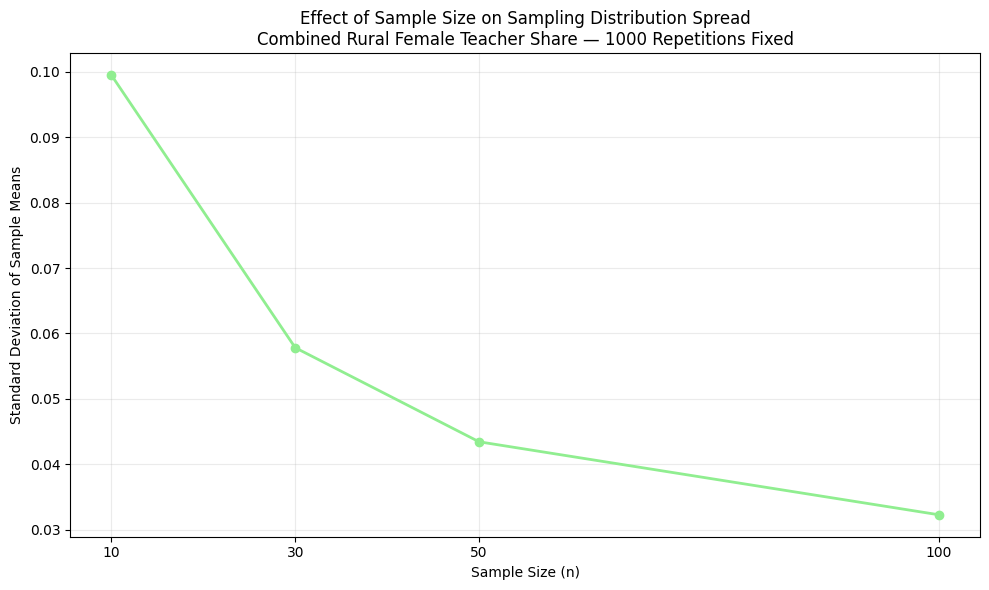

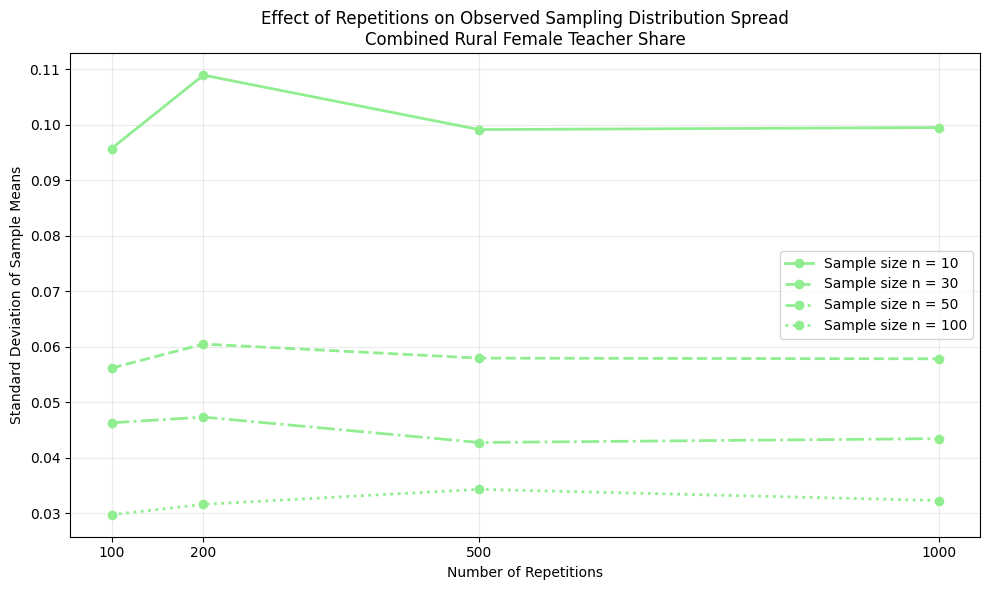

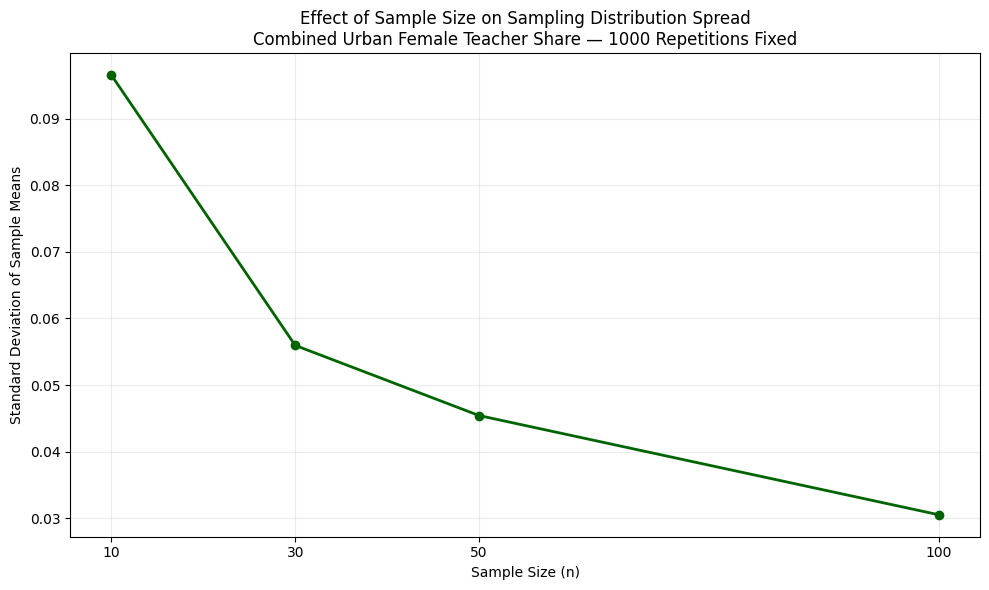

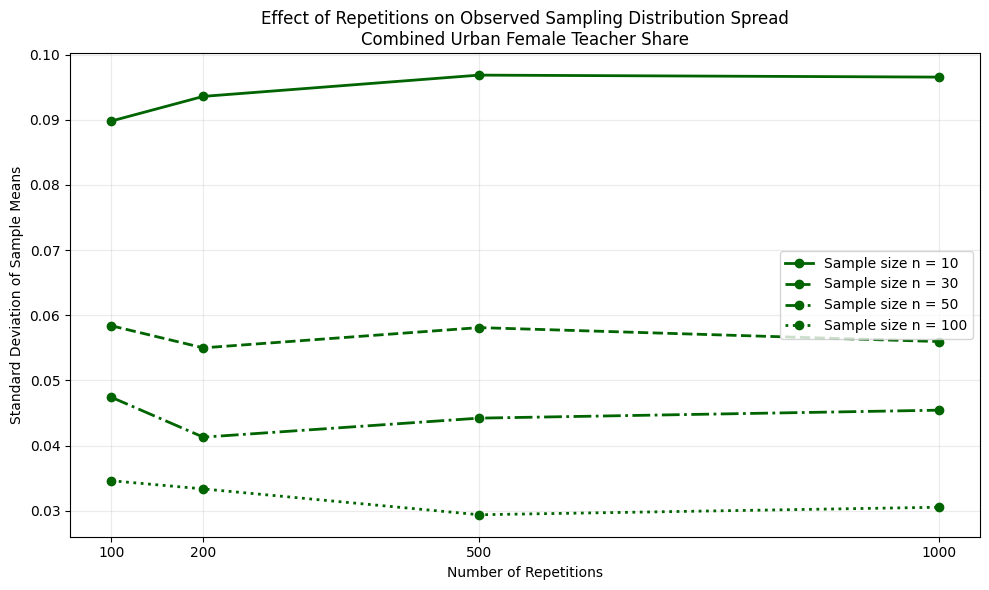

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import os


# =========================================================
# CREATE OUTPUT FOLDER
# =========================================================

os.makedirs("images", exist_ok=True)


# =========================================================
# STANDARDIZED COLORS
# =========================================================

population_colors = {
    "Combined Rural Female Teacher Share": "#90EE90",   # Light Green
    "Combined Urban Female Teacher Share": "#006400"    # Dark Green
}


# =========================================================
# LINE STYLES FOR SAMPLE SIZES
# =========================================================

line_styles = {
    10: "-",
    30: "--",
    50: "-.",
    100: ":"
}


# =========================================================
# FUNCTION TO PLOT BOTH SD GRAPHS
# =========================================================

def plot_sd_graphs(
    sampling_distributions,
    population_name
):

    # -----------------------------------------------------
    # Select standardized color
    # -----------------------------------------------------

    color = population_colors[population_name]


    # -----------------------------------------------------
    # Calculate SDs
    # -----------------------------------------------------

    sd_results = {}

    for reps in repetitions:

        for n in sample_sizes:

            values = sampling_distributions[(reps, n)]

            sd_results[(reps, n)] = values.std(
                ddof=1
            )


    # =====================================================
    # GRAPH 1
    # SD vs Sample Size
    # Fixed: 1000 repetitions
    # =====================================================

    fixed_reps = 1000

    plt.figure(figsize=(10, 6))

    sds = [
        sd_results[(fixed_reps, n)]
        for n in sample_sizes
    ]

    plt.plot(
        sample_sizes,
        sds,
        marker="o",
        color=color,
        linewidth=2
    )

    plt.xlabel("Sample Size (n)")
    plt.ylabel("Standard Deviation of Sample Means")

    plt.title(
        f"Effect of Sample Size on Sampling Distribution Spread\n"
        f"{population_name} — 1000 Repetitions Fixed"
    )

    plt.xticks(sample_sizes)

    plt.grid(
        alpha=0.25
    )

    plt.tight_layout()


    # -----------------------------------------------------
    # Save Graph 1
    # -----------------------------------------------------

    filename_1 = (
        f"sd_vs_sample_size_"
        f"{population_name.lower().replace(' ', '_')}.svg"
    )

    plt.savefig(
        os.path.join("images", filename_1),
        format="svg",
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


    # =====================================================
    # GRAPH 2
    # SD vs Number of Repetitions
    # =====================================================

    plt.figure(figsize=(10, 6))

    for n in sample_sizes:

        sds = [
            sd_results[(reps, n)]
            for reps in repetitions
        ]

        plt.plot(
            repetitions,
            sds,
            marker="o",
            color=color,
            linestyle=line_styles[n],
            linewidth=2,
            label=f"Sample size n = {n}"
        )

    plt.xlabel("Number of Repetitions")
    plt.ylabel("Standard Deviation of Sample Means")

    plt.title(
        f"Effect of Repetitions on Observed Sampling Distribution Spread\n"
        f"{population_name}"
    )

    plt.xticks(repetitions)

    plt.grid(
        alpha=0.25
    )

    plt.legend()

    plt.tight_layout()


    # -----------------------------------------------------
    # Save Graph 2
    # -----------------------------------------------------

    filename_2 = (
        f"sd_vs_repetitions_"
        f"{population_name.lower().replace(' ', '_')}.svg"
    )

    plt.savefig(
        os.path.join("images", filename_2),
        format="svg",
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


# =========================================================
# RURAL
# =========================================================

plot_sd_graphs(
    sampling_distributions_rural,
    "Combined Rural Female Teacher Share"
)


# =========================================================
# URBAN
# =========================================================

plot_sd_graphs(
    sampling_distributions_urban,
    "Combined Urban Female Teacher Share"
)

#### Correlation

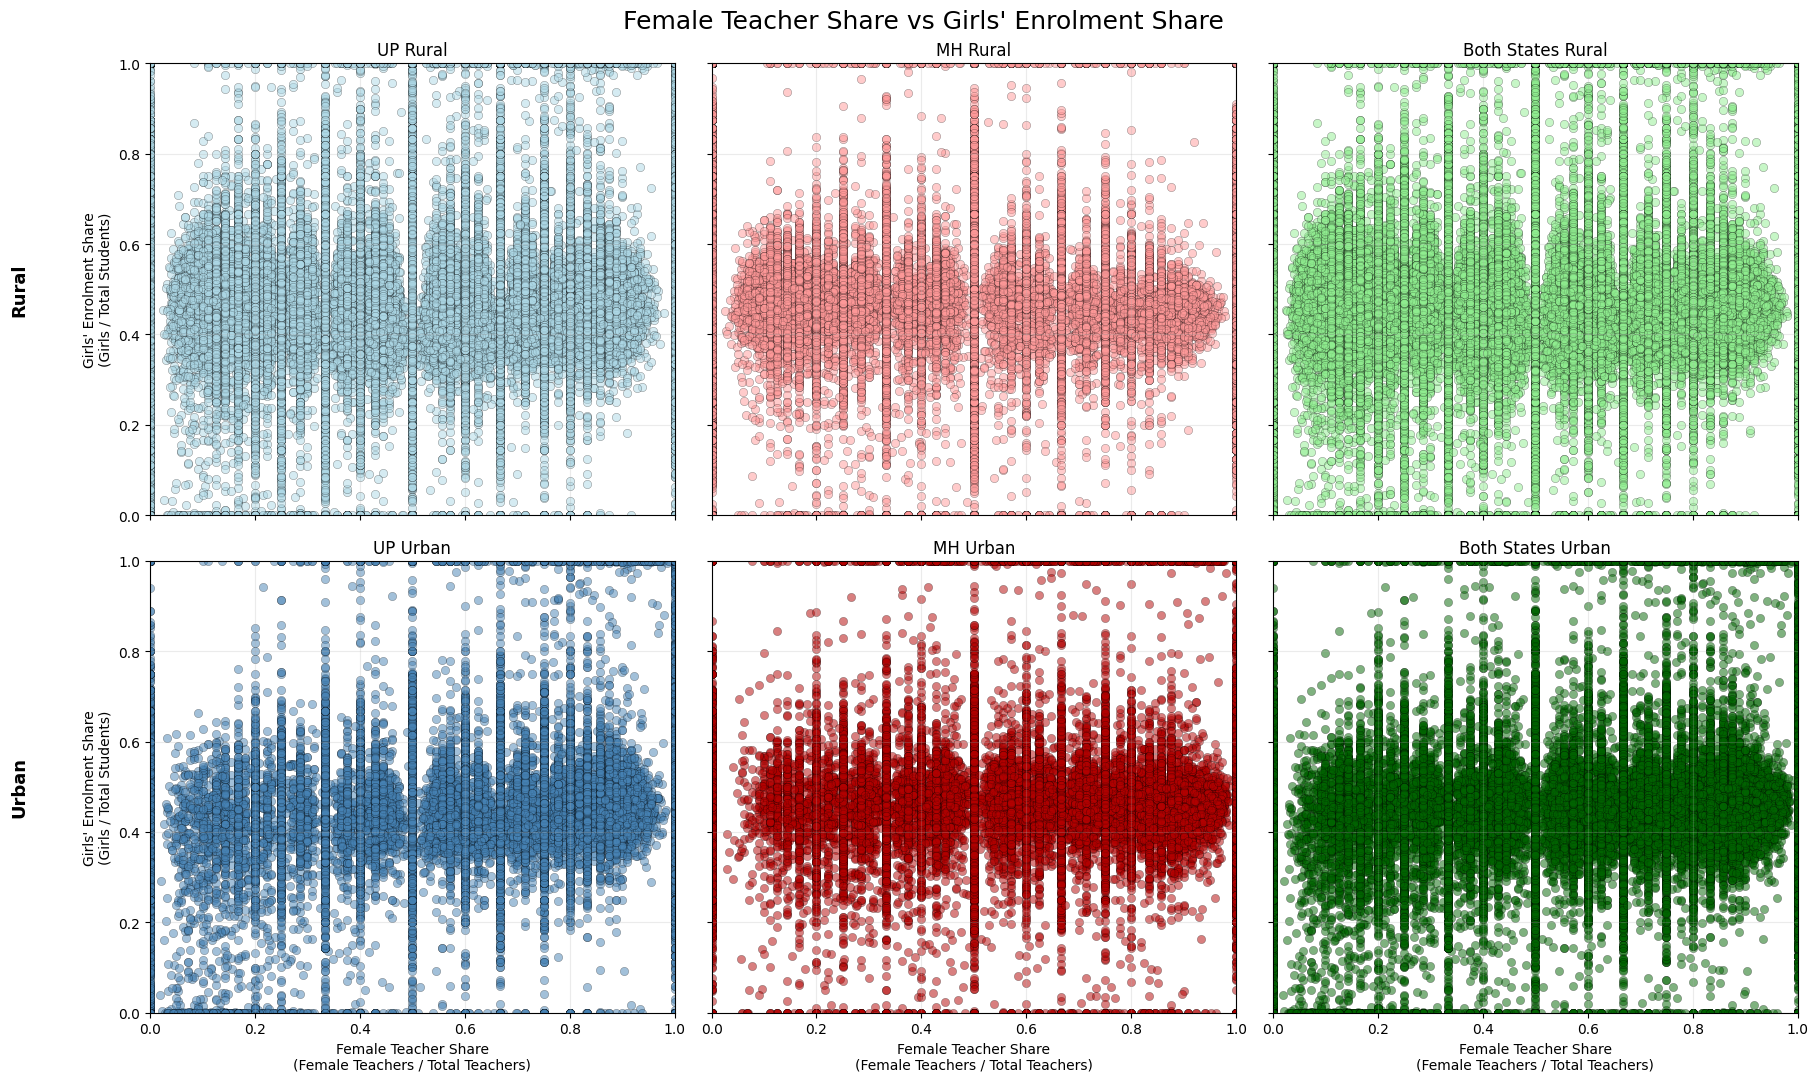

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ---------------------------------------------------------
# Standardized colors
#
# State:
# UP       = Blue
# MH       = Red
# Both     = Green
#
# Rural = lighter
# Urban = darker
# ---------------------------------------------------------

plot_colors = {
    "UP Rural": "#ADD8E6",          # Light Blue
    "UP Urban": "#4682B4",          # Dark Blue

    "MH Rural": "#FF9999",          # Light Red
    "MH Urban": "#B30000",          # Dark Red

    "Both States Rural": "#90EE90", # Light Green
    "Both States Urban": "#006400"  # Dark Green
}


# ---------------------------------------------------------
# Define groups
# ---------------------------------------------------------

groups = [
    [
        ("UP Rural", combined_gender_data[
            (combined_gender_data["State"] == "Uttar Pradesh") &
            (combined_gender_data["rural_urban"] == "Rural")
        ]),

        ("MH Rural", combined_gender_data[
            (combined_gender_data["State"] == "Maharashtra") &
            (combined_gender_data["rural_urban"] == "Rural")
        ]),

        ("Both States Rural", combined_gender_data[
            combined_gender_data["rural_urban"] == "Rural"
        ])
    ],

    [
        ("UP Urban", combined_gender_data[
            (combined_gender_data["State"] == "Uttar Pradesh") &
            (combined_gender_data["rural_urban"] == "Urban")
        ]),

        ("MH Urban", combined_gender_data[
            (combined_gender_data["State"] == "Maharashtra") &
            (combined_gender_data["rural_urban"] == "Urban")
        ]),

        ("Both States Urban", combined_gender_data[
            combined_gender_data["rural_urban"] == "Urban"
        ])
    ]
]


# ---------------------------------------------------------
# Variables
# ---------------------------------------------------------

x_variable = "female_teacher_share"
y_variable = "girls_enrolment_ratio"


# ---------------------------------------------------------
# Common X and Y limits
# ---------------------------------------------------------

all_x = combined_gender_data[x_variable].dropna()
all_y = combined_gender_data[y_variable].dropna()

x_min = all_x.min()
x_max = all_x.max()

y_min = all_y.min()
y_max = all_y.max()


# ---------------------------------------------------------
# Create 2 × 3 figure
# ---------------------------------------------------------

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 11),
    sharex=True,
    sharey=True
)


# ---------------------------------------------------------
# Plot each group
# ---------------------------------------------------------

for row in range(2):

    for col in range(3):

        ax = axes[row, col]

        group_name, df = groups[row][col]

        # Remove missing values
        plot_data = df[
            [x_variable, y_variable]
        ].dropna()

        # Scatter plot
        ax.scatter(
            plot_data[x_variable],
            plot_data[y_variable],
            color=plot_colors[group_name],
            alpha=0.5,
            edgecolor="black",
            linewidth=0.3
        )

        ax.set_title(
            group_name,
            fontsize=12
        )

        # Same scales across all six graphs
        ax.set_xlim(
            x_min,
            x_max
        )

        ax.set_ylim(
            y_min,
            y_max
        )

        ax.grid(
            alpha=0.25
        )


# ---------------------------------------------------------
# X-axis labels
# ---------------------------------------------------------

for ax in axes[1, :]:
    ax.set_xlabel(
        "Female Teacher Share\n(Female Teachers / Total Teachers)"
    )


# ---------------------------------------------------------
# Y-axis labels
# ---------------------------------------------------------

for ax in axes[:, 0]:
    ax.set_ylabel(
        "Girls' Enrolment Share\n(Girls / Total Students)"
    )


# ---------------------------------------------------------
# Row labels
# ---------------------------------------------------------

axes[0, 0].text(
    -0.25,
    0.5,
    "Rural",
    transform=axes[0, 0].transAxes,
    rotation=90,
    va="center",
    ha="center",
    fontsize=13,
    fontweight="bold"
)

axes[1, 0].text(
    -0.25,
    0.5,
    "Urban",
    transform=axes[1, 0].transAxes,
    rotation=90,
    va="center",
    ha="center",
    fontsize=13,
    fontweight="bold"
)


# ---------------------------------------------------------
# Overall title
# ---------------------------------------------------------

fig.suptitle(
    "Female Teacher Share vs Girls' Enrolment Share",
    fontsize=18
)

plt.tight_layout()
plt.show()

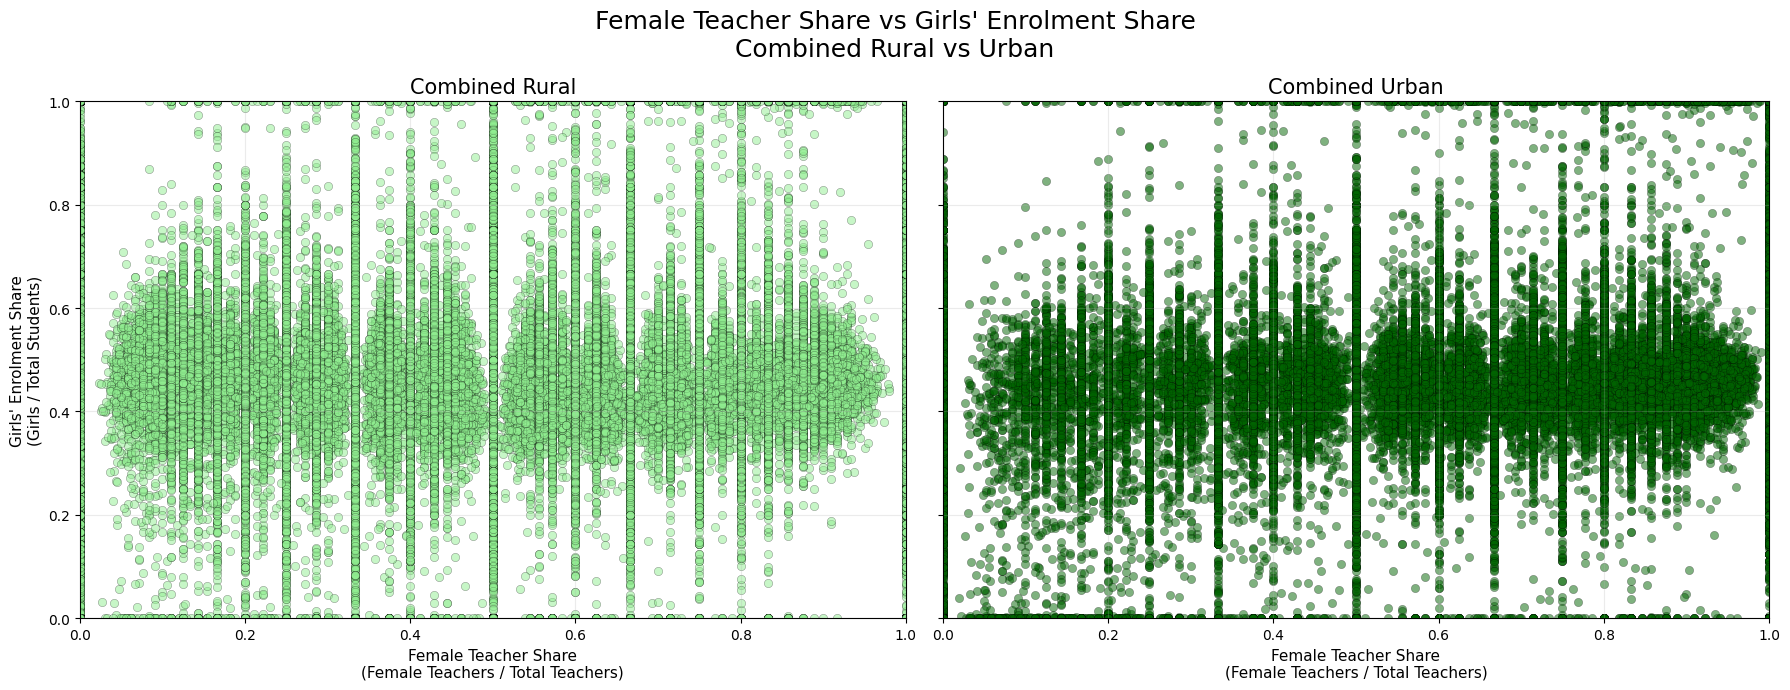

C:\Users\Gaurish Garg\AppData\Local\Temp\ipykernel_36184\390819444.py:264: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(
C:\Users\Gaurish Garg\AppData\Local\Temp\ipykernel_36184\390819444.py:273: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(
C:\Users\Gaurish Garg\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


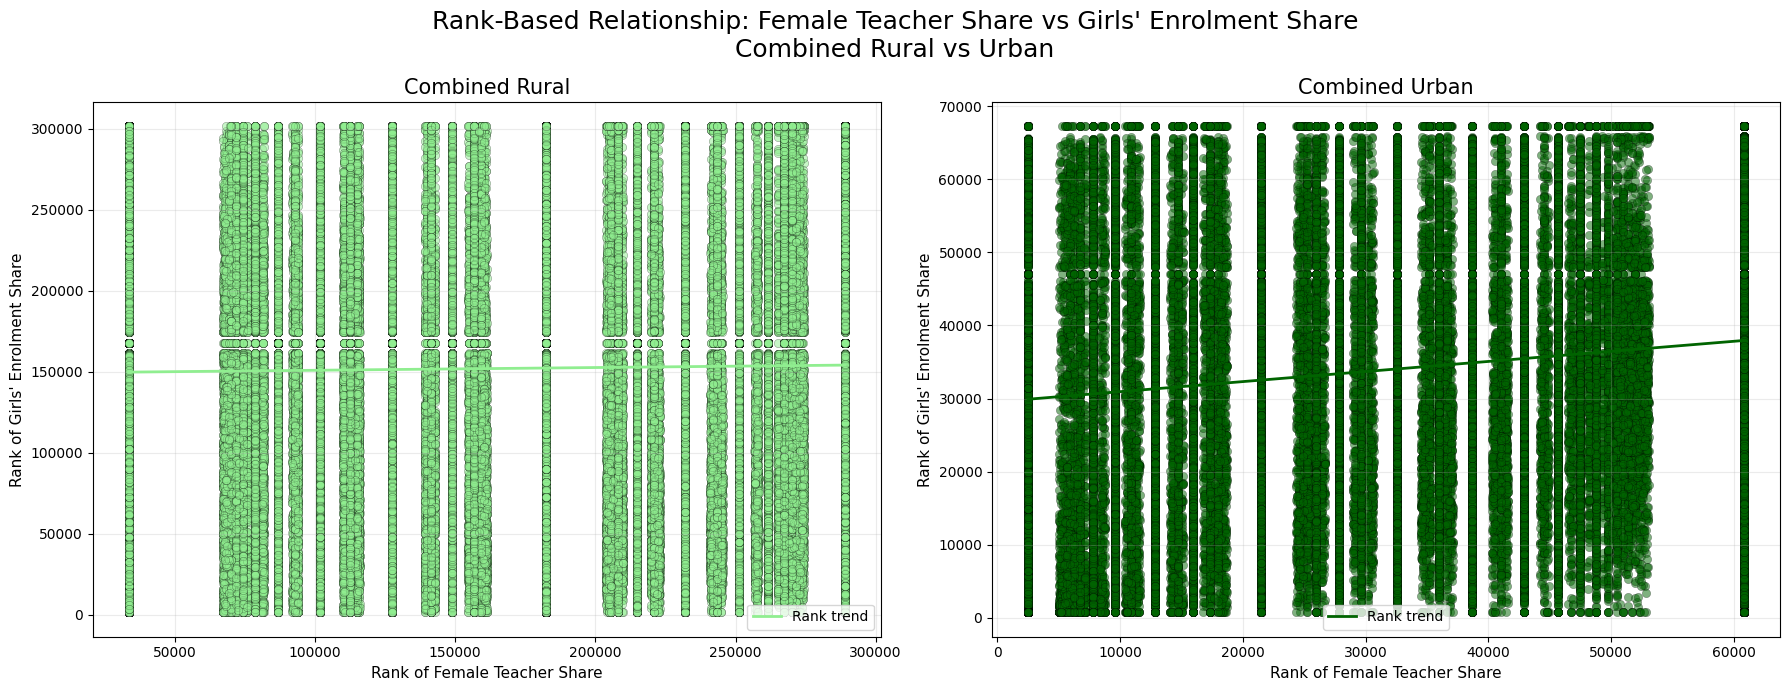

In [32]:
# =========================================================
# TWO LARGE PLOTS: RAW VALUES + RANK-BASED GRAPH
# COMBINED RURAL vs COMBINED URBAN
# =========================================================

import os
import matplotlib.pyplot as plt


combined_groups = [
    (
        "Combined Rural",
        combined_gender_data[
            combined_gender_data["rural_urban"] == "Rural"
        ]
    ),
    (
        "Combined Urban",
        combined_gender_data[
            combined_gender_data["rural_urban"] == "Urban"
        ]
    )
]


# ---------------------------------------------------------
# Standardized colors
# ---------------------------------------------------------

plot_colors = {
    "Combined Rural": "#90EE90",   # Light Green
    "Combined Urban": "#006400"    # Dark Green
}


# =========================================================
# FIGURE 1 — RAW VALUES
# =========================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 7),
    sharex=True,
    sharey=True
)


for ax, (group_name, df) in zip(axes, combined_groups):

    # Remove missing values
    plot_data = df[
        [x_variable, y_variable]
    ].dropna()

    # Scatter plot
    ax.scatter(
        plot_data[x_variable],
        plot_data[y_variable],
        color=plot_colors[group_name],
        alpha=0.5,
        edgecolor="black",
        linewidth=0.3
    )

    # Title
    ax.set_title(
        group_name,
        fontsize=15
    )

    # Same scales
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Grid
    ax.grid(alpha=0.25)


# X-axis labels
for ax in axes:
    ax.set_xlabel(
        "Female Teacher Share\n"
        "(Female Teachers / Total Teachers)",
        fontsize=11
    )


# Y-axis label
axes[0].set_ylabel(
    "Girls' Enrolment Share\n"
    "(Girls / Total Students)",
    fontsize=11
)


# Overall title
fig.suptitle(
    "Female Teacher Share vs Girls' Enrolment Share\n"
    "Combined Rural vs Urban",
    fontsize=18
)


# Save
os.makedirs("images", exist_ok=True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        "images",
        "female_teacher_share_vs_girls_enrolment_share_combined_rural_urban.svg"
    ),
    format="svg",
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        "images",
        "female_teacher_share_vs_girls_enrolment_share_combined_rural_urban.png"
    ),
    format="png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# =========================================================
# FIGURE 2 — RANK-BASED VALUES
# =========================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 7),
    sharex=False,
    sharey=False
)


for ax, (group_name, df) in zip(axes, combined_groups):

    # -----------------------------------------------------
    # Remove missing values
    # -----------------------------------------------------

    plot_data = df[
        [x_variable, y_variable]
    ].dropna().copy()


    # -----------------------------------------------------
    # Convert both variables to ranks
    # -----------------------------------------------------

    plot_data["x_rank"] = plot_data[x_variable].rank(
        method="average"
    )

    plot_data["y_rank"] = plot_data[y_variable].rank(
        method="average"
    )


    # -----------------------------------------------------
    # Rank scatter plot
    # -----------------------------------------------------

    ax.scatter(
        plot_data["x_rank"],
        plot_data["y_rank"],
        color=plot_colors[group_name],
        alpha=0.5,
        edgecolor="black",
        linewidth=0.3
    )


    # -----------------------------------------------------
    # Linear trend in rank space
    # -----------------------------------------------------

    slope, intercept = np.polyfit(
        plot_data["x_rank"],
        plot_data["y_rank"],
        1
    )

    x_line = np.linspace(
        plot_data["x_rank"].min(),
        plot_data["x_rank"].max(),
        100
    )

    y_line = slope * x_line + intercept


    ax.plot(
        x_line,
        y_line,
        color=plot_colors[group_name],
        linewidth=2,
        label="Rank trend"
    )


    # -----------------------------------------------------
    # Title
    # -----------------------------------------------------

    ax.set_title(
        group_name,
        fontsize=15
    )


    # -----------------------------------------------------
    # Axis labels
    # -----------------------------------------------------

    ax.set_xlabel(
        "Rank of Female Teacher Share",
        fontsize=11
    )

    ax.set_ylabel(
        "Rank of Girls' Enrolment Share",
        fontsize=11
    )


    # -----------------------------------------------------
    # Grid and legend
    # -----------------------------------------------------

    ax.grid(alpha=0.25)

    ax.legend()


# ---------------------------------------------------------
# Overall title
# ---------------------------------------------------------

fig.suptitle(
    "Rank-Based Relationship: Female Teacher Share vs "
    "Girls' Enrolment Share\n"
    "Combined Rural vs Urban",
    fontsize=18
)


# ---------------------------------------------------------
# Save rank-based plots
# ---------------------------------------------------------

plt.tight_layout()

plt.savefig(
    os.path.join(
        "images",
        "rank_female_teacher_share_vs_girls_enrolment_share_combined_rural_urban.svg"
    ),
    format="svg",
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        "images",
        "rank_female_teacher_share_vs_girls_enrolment_share_combined_rural_urban.png"
    ),
    format="png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [30]:
from scipy.stats import pearsonr, spearmanr, kendalltau
import pandas as pd


# =========================================================
# Function to calculate all three correlations
# =========================================================

def calculate_correlations(df):

    data = df[
        ["female_teacher_share", "girls_enrolment_ratio"]
    ].dropna()

    x = data["female_teacher_share"]
    y = data["girls_enrolment_ratio"]

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)
    kendall_tau, kendall_p = kendalltau(x, y)

    return {
        "Pearson r": pearson_r,
        "Spearman ρ": spearman_rho,
        "Kendall τ-b": kendall_tau
    }


# =========================================================
# Function to create table for Rural / Urban
# =========================================================

def correlation_table(setting):

    up = combined_gender_data[
        (combined_gender_data["State"] == "Uttar Pradesh") &
        (combined_gender_data["rural_urban"] == setting)
    ]

    mh = combined_gender_data[
        (combined_gender_data["State"] == "Maharashtra") &
        (combined_gender_data["rural_urban"] == setting)
    ]

    combined = combined_gender_data[
        combined_gender_data["rural_urban"] == setting
    ]

    results = {
        "UP": calculate_correlations(up),
        "MH": calculate_correlations(mh),
        "Combined": calculate_correlations(combined)
    }

    table = pd.DataFrame(results)

    return table


# =========================================================
# RURAL TABLE
# =========================================================

rural_correlation_table = correlation_table("Rural")

print("\n" + "=" * 60)
print("CORRELATIONS — RURAL")
print("=" * 60)

display(
    rural_correlation_table.round(4)
)


# =========================================================
# URBAN TABLE
# =========================================================

urban_correlation_table = correlation_table("Urban")

print("\n" + "=" * 60)
print("CORRELATIONS — URBAN")
print("=" * 60)

display(
    urban_correlation_table.round(4)
)


CORRELATIONS — RURAL


,UP,MH,Combined
Pearson r,0.0895,-0.0126,0.0586
Spearman ρ,0.0395,-0.0360,0.0168
Kendall τ-b,0.0274,-0.0266,0.0116



CORRELATIONS — URBAN


,UP,MH,Combined
Pearson r,0.2473,0.0653,0.1790
Spearman ρ,0.2073,0.0301,0.1370
Kendall τ-b,0.1480,0.0198,0.0965


Since girls enrolment ratio has outliers, spearman's correlation was considered more appropriate

1. **Pearson is higher than Spearman in both settings**, suggesting that some extreme numerical values/outliers influence the linear correlation; this is particularly relevant because girls' enrolment share has outliers.

2. **Spearman correlation is higher in Urban (0.137) than Rural (0.017)**, indicating a slightly stronger positive monotonic association in urban schools.

3. **Rural schools show almost no association** between female teacher share and girls' enrolment share: Pearson = 0.059, Spearman = 0.017, Kendall = 0.012.

4. **Urban schools show a small positive association**: Pearson = 0.179, Spearman = 0.137, Kendall = 0.097, but the relationship is still weak.

5. **Overall, the evidence points toward little/no practically meaningful association in Rural schools and a weak positive association in Urban schools**; More investigation is required, as distribution also doesn't tend to be monotonic

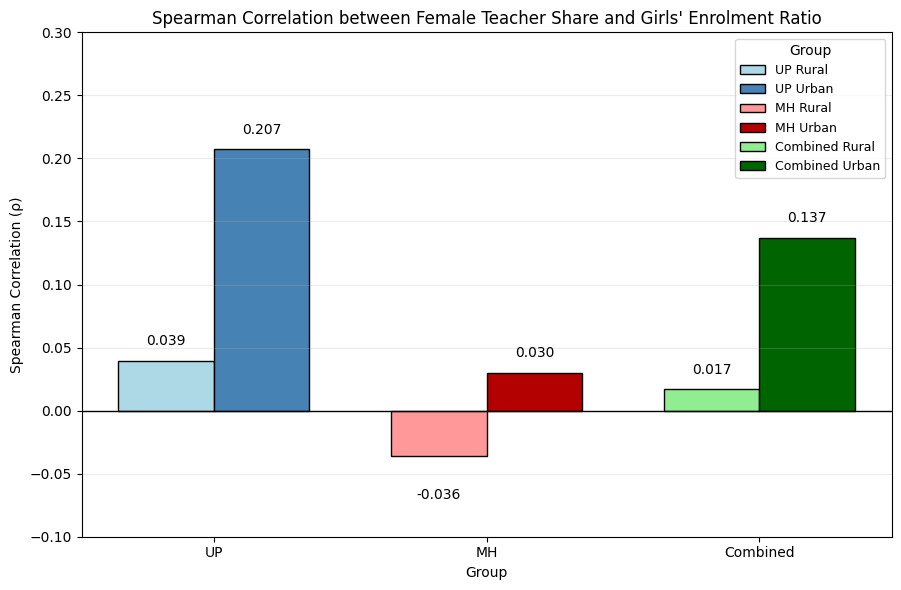

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# ---------------------------------------------------------
# Extract Spearman correlations
# ---------------------------------------------------------

states = ["UP", "MH", "Combined"]

rural_spearman = rural_correlation_table.loc[
    "Spearman ρ", states
].values

urban_spearman = urban_correlation_table.loc[
    "Spearman ρ", states
].values


# ---------------------------------------------------------
# Standardized colors
# ---------------------------------------------------------

rural_colors = [
    "#ADD8E6",   # UP Rural - Light Blue
    "#FF9999",   # MH Rural - Light Red
    "#90EE90"    # Combined Rural - Light Green
]

urban_colors = [
    "#4682B4",   # UP Urban - Dark Blue
    "#B30000",   # MH Urban - Dark Red
    "#006400"    # Combined Urban - Dark Green
]


# ---------------------------------------------------------
# Bar positions
# ---------------------------------------------------------

x = np.arange(len(states))
width = 0.35


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 6))

bars1 = ax.bar(
    x - width / 2,
    rural_spearman,
    width,
    color=rural_colors,
    edgecolor="black"
)

bars2 = ax.bar(
    x + width / 2,
    urban_spearman,
    width,
    color=urban_colors,
    edgecolor="black"
)


# ---------------------------------------------------------
# Reference line at zero
# ---------------------------------------------------------

ax.axhline(
    0,
    color="black",
    linewidth=1
)


# ---------------------------------------------------------
# Labels
# ---------------------------------------------------------

ax.set_xlabel("Group")
ax.set_ylabel("Spearman Correlation (ρ)")

ax.set_title(
    "Spearman Correlation between Female Teacher Share "
    "and Girls' Enrolment Ratio"
)

ax.set_xticks(x)
ax.set_xticklabels(states)


# ---------------------------------------------------------
# Custom legend: State + Rural/Urban
# ---------------------------------------------------------

legend_handles = [
    Patch(
        facecolor="#ADD8E6",
        edgecolor="black",
        label="UP Rural"
    ),
    Patch(
        facecolor="#4682B4",
        edgecolor="black",
        label="UP Urban"
    ),
    Patch(
        facecolor="#FF9999",
        edgecolor="black",
        label="MH Rural"
    ),
    Patch(
        facecolor="#B30000",
        edgecolor="black",
        label="MH Urban"
    ),
    Patch(
        facecolor="#90EE90",
        edgecolor="black",
        label="Combined Rural"
    ),
    Patch(
        facecolor="#006400",
        edgecolor="black",
        label="Combined Urban"
    )
]

ax.legend(
    handles=legend_handles,
    title="Group",
    loc="upper right",
    fontsize=9,
    title_fontsize=10
)


# ---------------------------------------------------------
# Grid
# ---------------------------------------------------------

ax.grid(
    axis="y",
    alpha=0.25
)


# ---------------------------------------------------------
# Add values on bars
# ---------------------------------------------------------

for bars in [bars1, bars2]:

    for bar in bars:

        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + (0.01 if height >= 0 else -0.025),
            f"{height:.3f}",
            ha="center",
            va="bottom" if height >= 0 else "top"
        )


# ---------------------------------------------------------
# Final formatting
# ---------------------------------------------------------

plt.tight_layout()
plt.ylim(-0.1, 0.3)
plt.show()

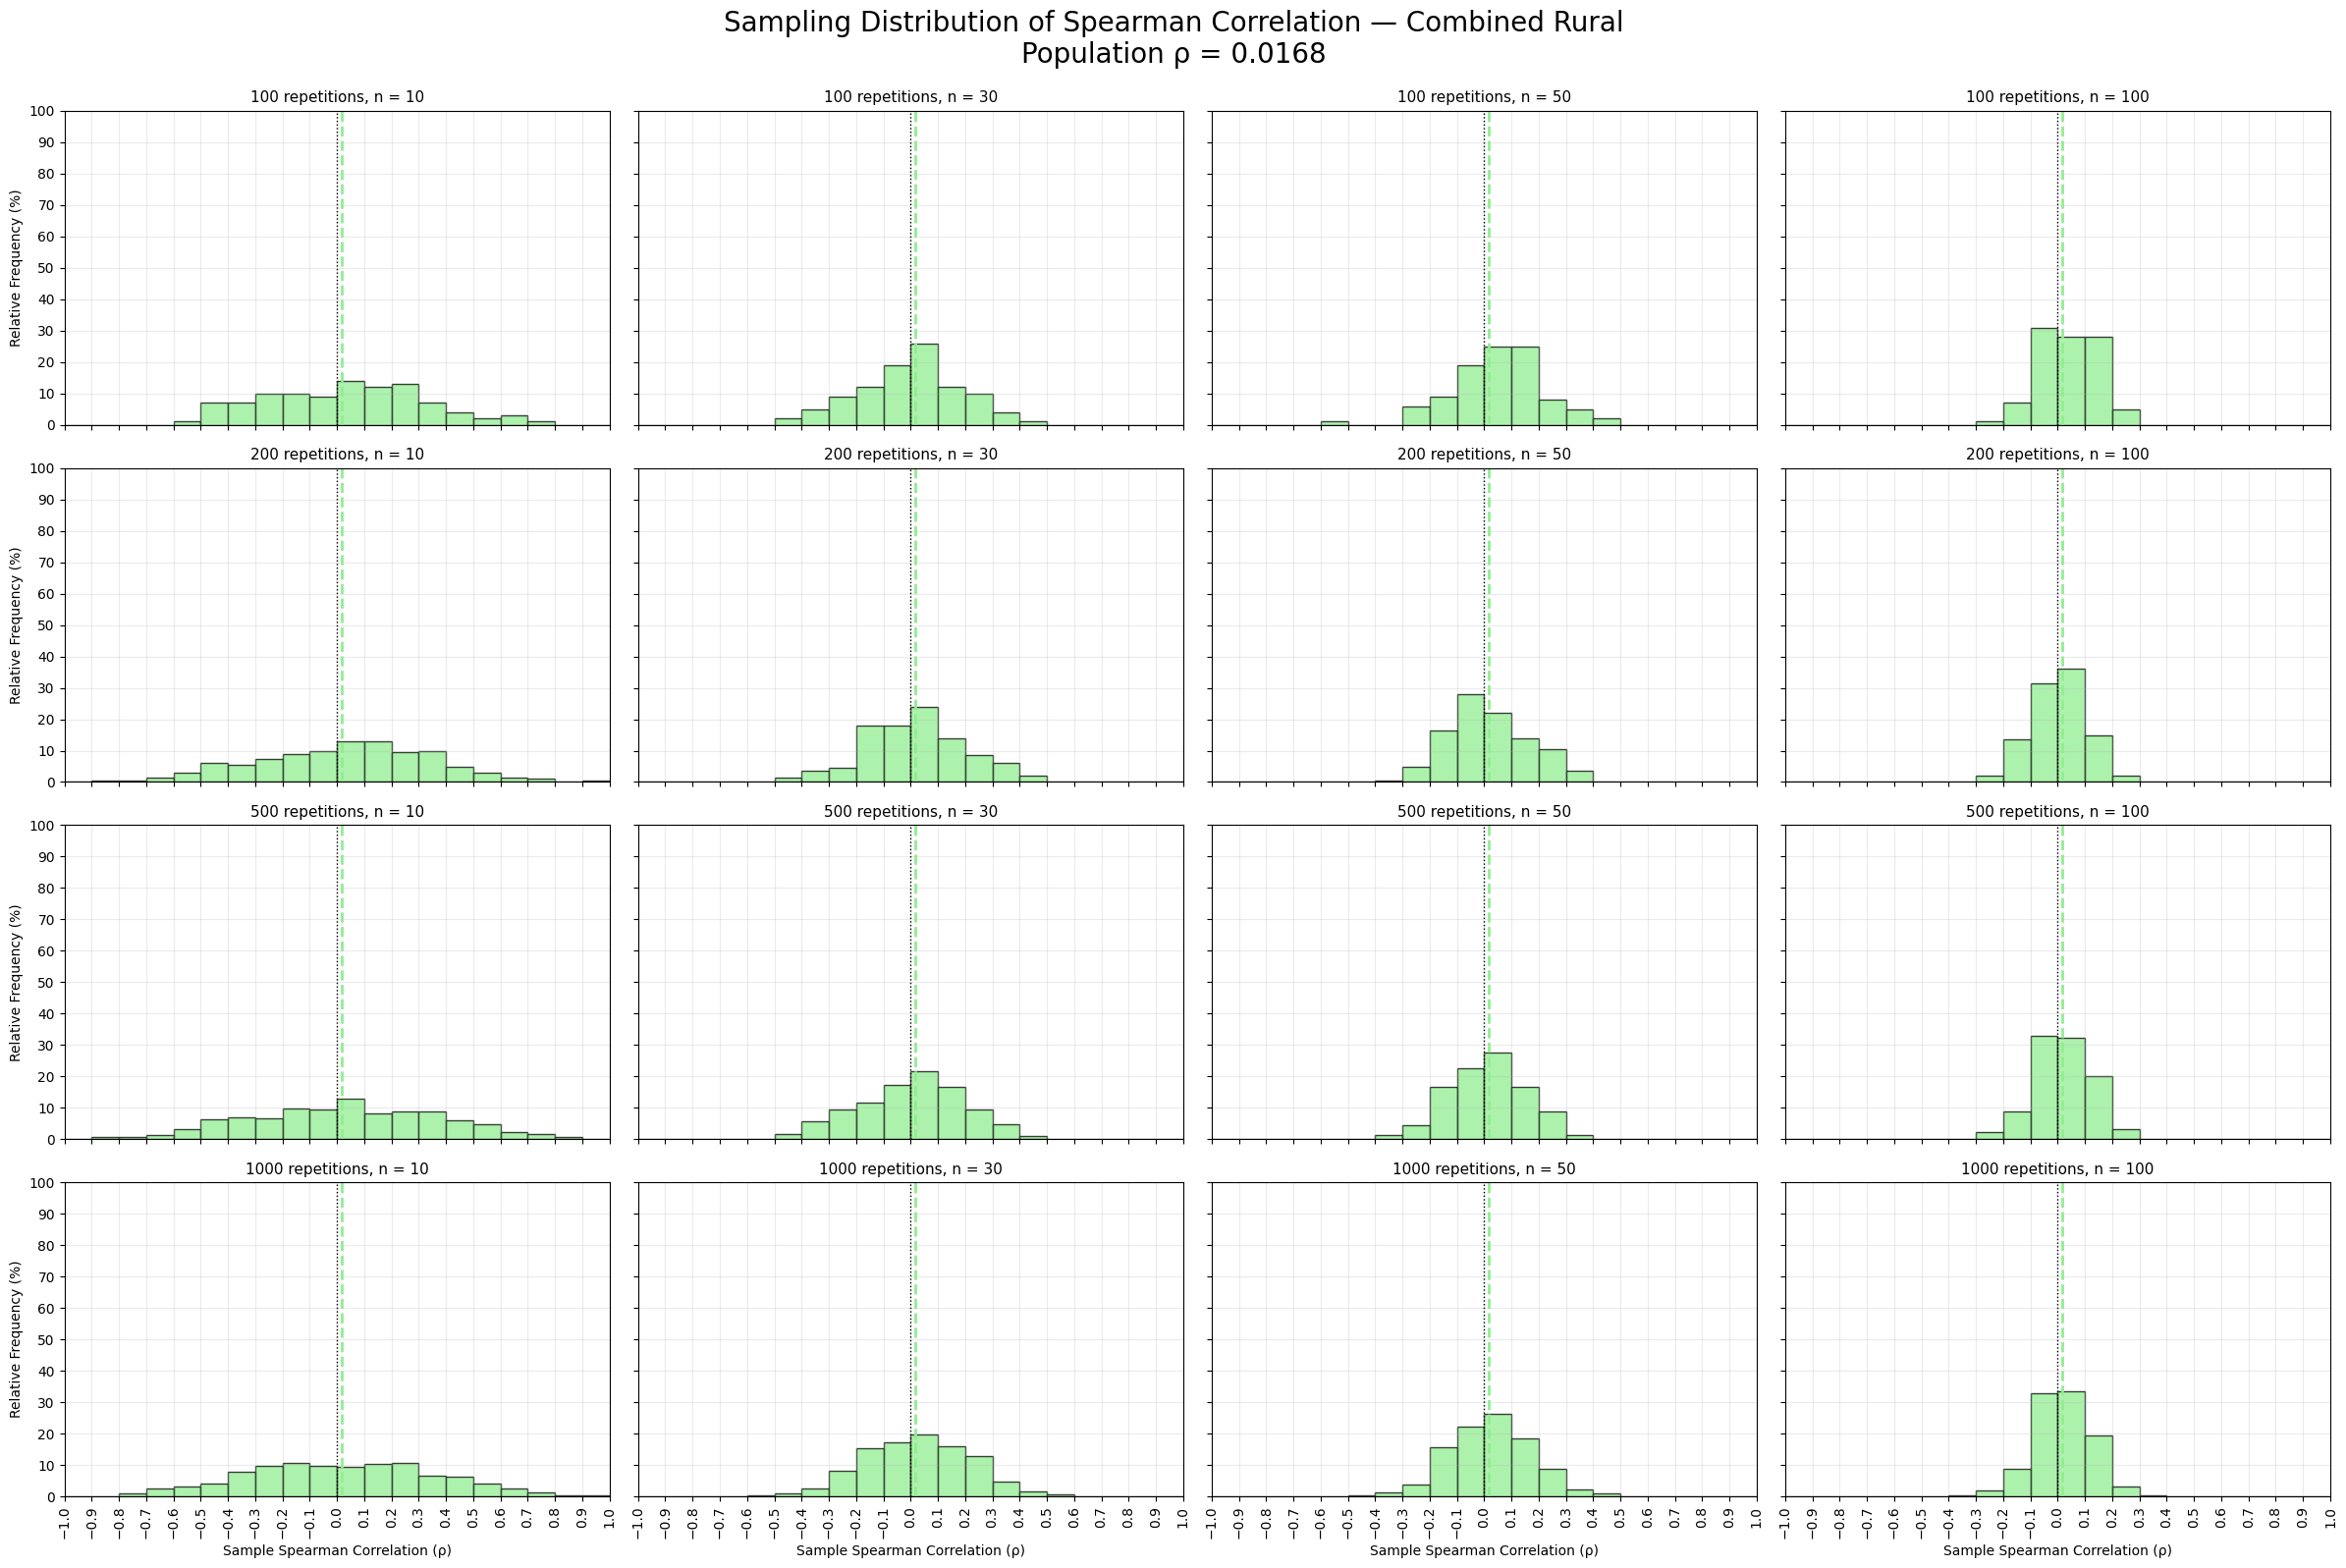

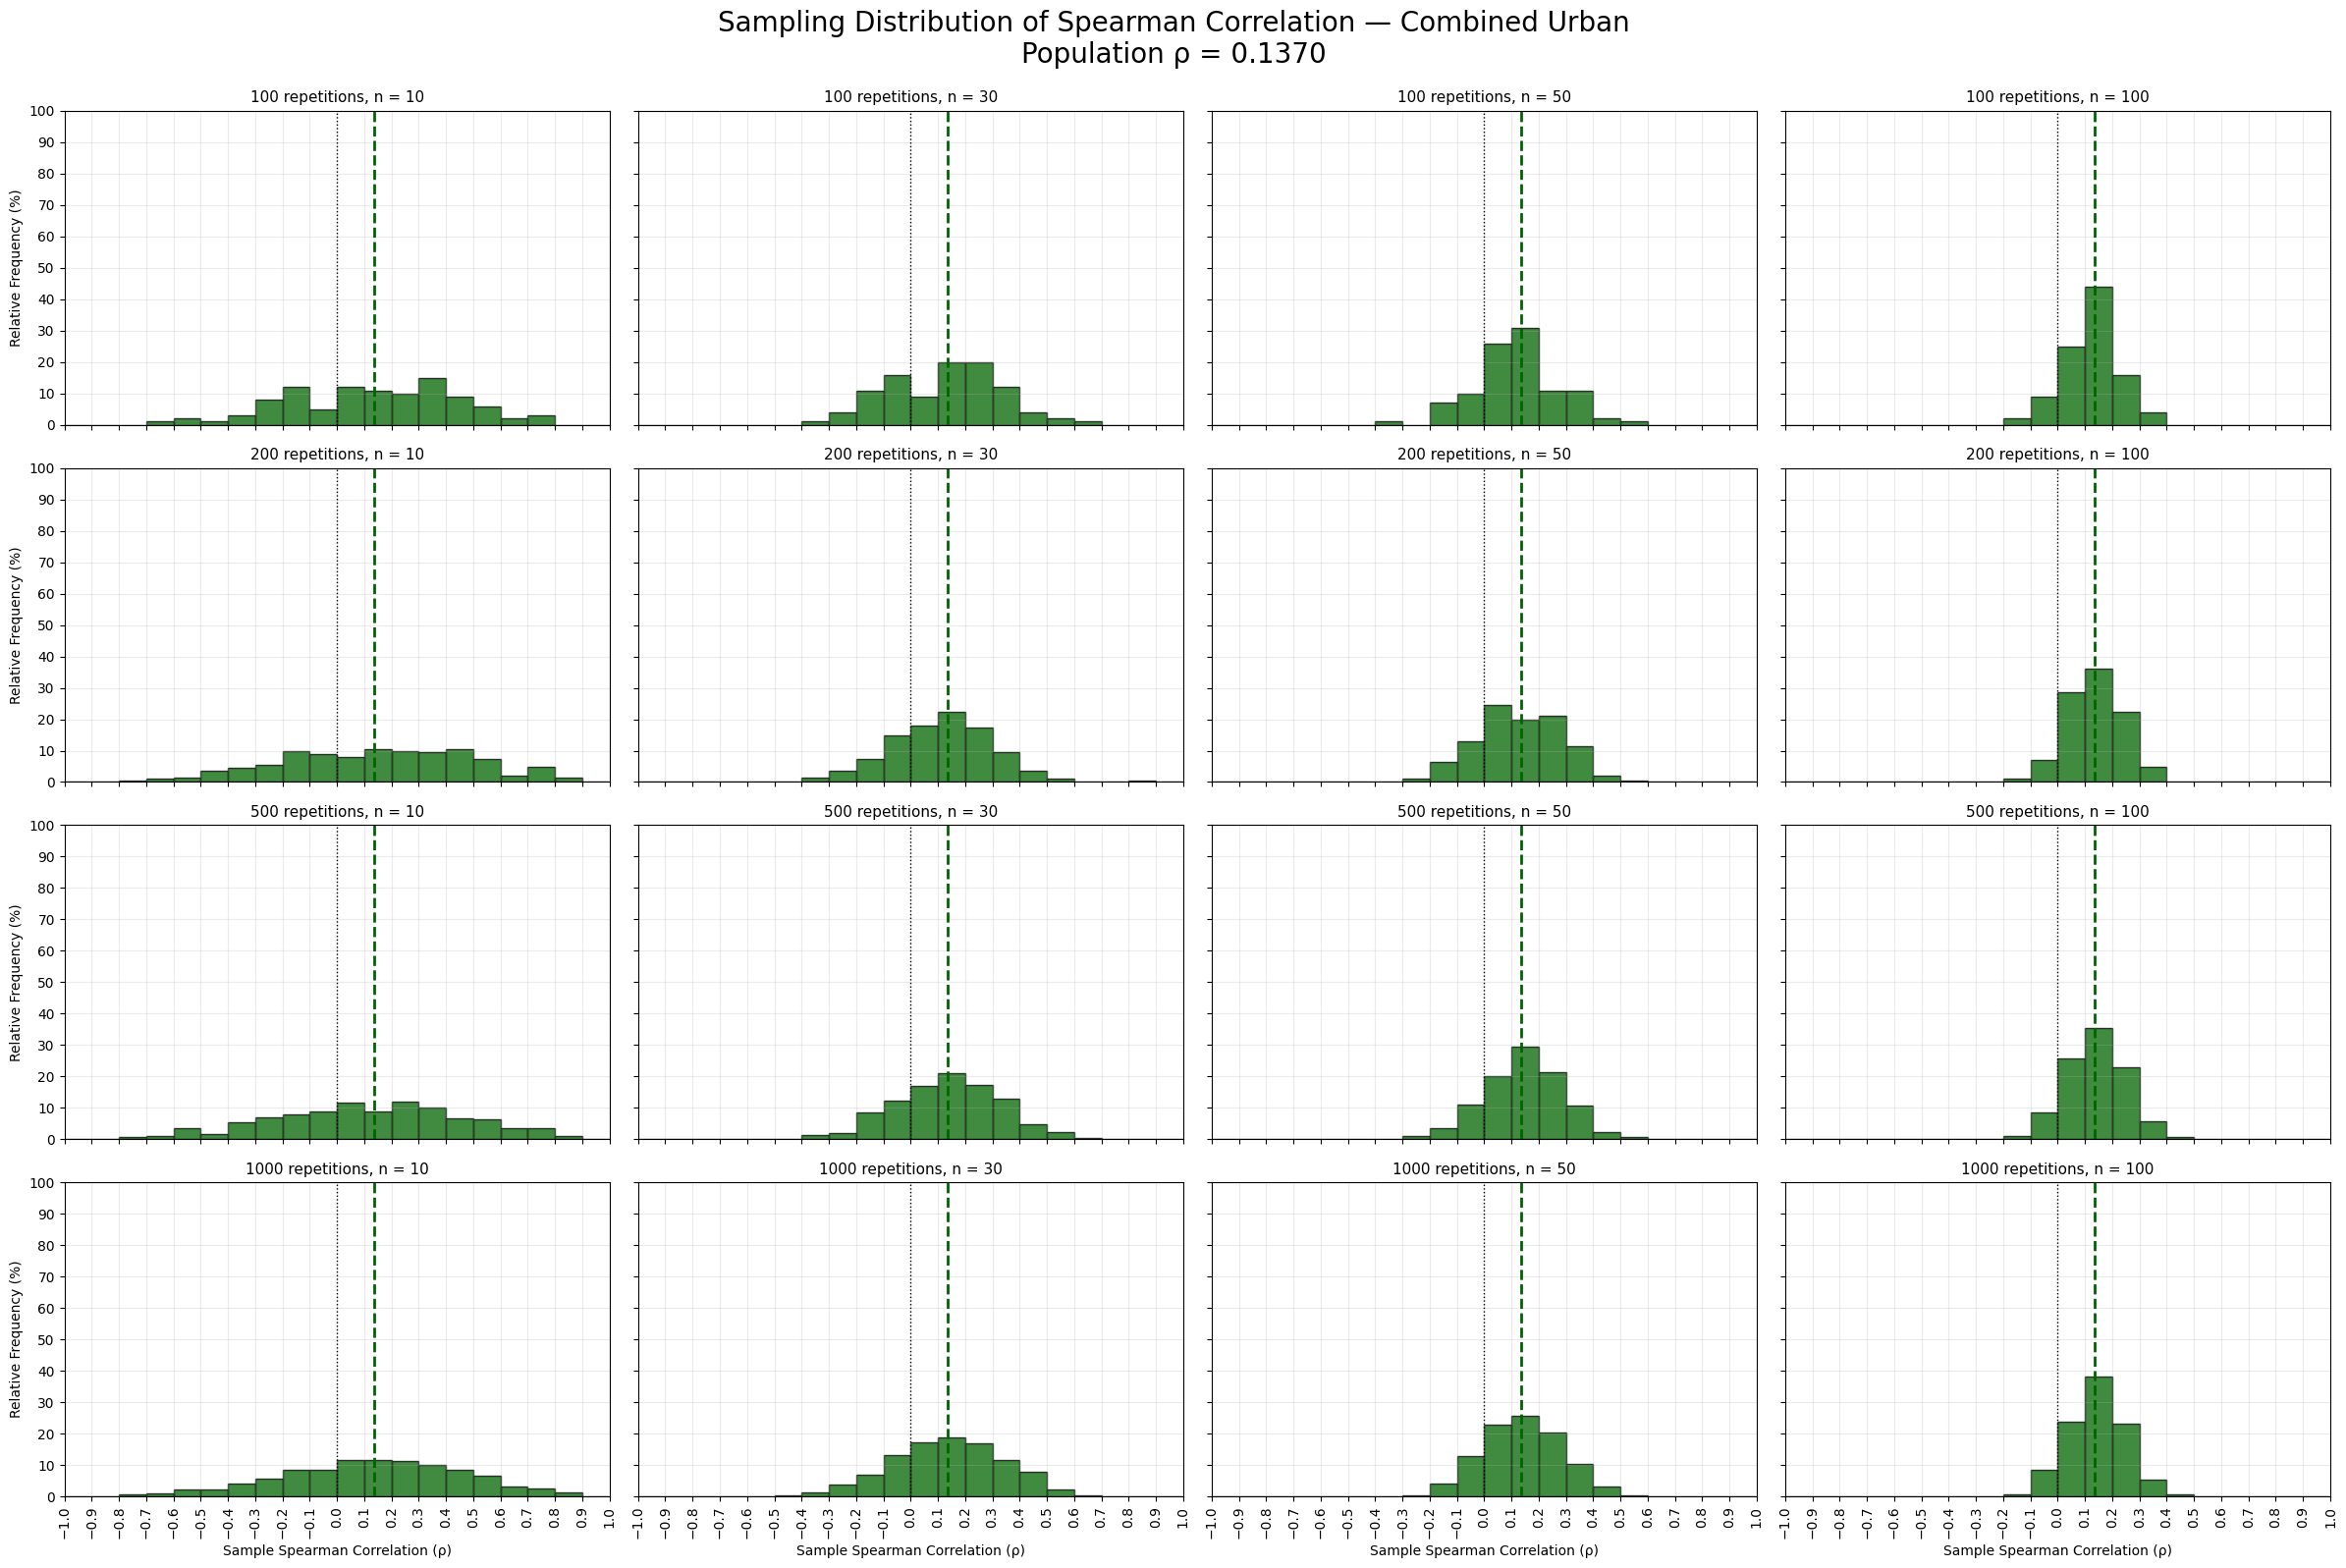

In [33]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr


# ---------------------------------------------------------
# Settings
# ---------------------------------------------------------

sample_sizes = [10, 30, 50, 100]
repetitions = [100, 200, 500, 1000]

# Fixed random seed
rng = np.random.default_rng(42)


# ---------------------------------------------------------
# Standardized colors
# ---------------------------------------------------------

population_colors = {
    "Combined Rural": "#90EE90",   # Light Green
    "Combined Urban": "#006400"    # Dark Green
}


# ---------------------------------------------------------
# Rural and Urban populations
# ---------------------------------------------------------

populations = {
    "Combined Rural": combined_gender_data[
        combined_gender_data["rural_urban"] == "Rural"
    ][
        ["female_teacher_share", "girls_enrolment_ratio"]
    ].dropna(),

    "Combined Urban": combined_gender_data[
        combined_gender_data["rural_urban"] == "Urban"
    ][
        ["female_teacher_share", "girls_enrolment_ratio"]
    ].dropna()
}


# ---------------------------------------------------------
# Create images folder
# ---------------------------------------------------------

os.makedirs("images", exist_ok=True)


# ---------------------------------------------------------
# Generate one figure for each population
# ---------------------------------------------------------

for population_name, population in populations.items():

    # -----------------------------------------------------
    # Population Spearman correlation
    # -----------------------------------------------------

    population_correlation, population_p = spearmanr(
        population["female_teacher_share"],
        population["girls_enrolment_ratio"]
    )

    # -----------------------------------------------------
    # Generate sampling distributions
    # -----------------------------------------------------

    sampling_distributions = {}

    for reps in repetitions:

        for n in sample_sizes:

            sample_correlations = []

            for _ in range(reps):

                # -----------------------------------------
                # Sample ROWS so X-Y pairing is preserved
                # -----------------------------------------

                sample_indices = rng.choice(
                    len(population),
                    size=n,
                    replace=False
                )

                sample = population.iloc[sample_indices]

                # -----------------------------------------
                # Calculate Spearman correlation
                # -----------------------------------------

                correlation, _ = spearmanr(
                    sample["female_teacher_share"],
                    sample["girls_enrolment_ratio"]
                )

                sample_correlations.append(
                    correlation
                )

            sampling_distributions[(reps, n)] = np.array(
                sample_correlations
            )


    # -----------------------------------------------------
    # Histogram bins
    # Correlation ranges from -1 to +1
    # -----------------------------------------------------

    bins = np.linspace(-1, 1, 21)


    # -----------------------------------------------------
    # Create 4 × 4 figure
    # -----------------------------------------------------

    fig, axes = plt.subplots(
        4,
        4,
        figsize=(24, 16),
        sharex=True,
        sharey=True
    )


    # Color for this population
    plot_color = population_colors[population_name]


    for row, reps in enumerate(repetitions):

        for col, n in enumerate(sample_sizes):

            ax = axes[row, col]

            values = sampling_distributions[(reps, n)]


            # -------------------------------------------------
            # Relative frequency (%)
            # -------------------------------------------------

            counts, bin_edges = np.histogram(
                values,
                bins=bins
            )

            relative_frequency_percent = (
                counts / len(values)
            ) * 100


            # -------------------------------------------------
            # Plot
            # -------------------------------------------------

            ax.bar(
                bin_edges[:-1],
                relative_frequency_percent,
                width=np.diff(bin_edges),
                align="edge",
                color=plot_color,
                edgecolor="black",
                alpha=0.75
            )


            # -------------------------------------------------
            # Population Spearman correlation
            # -------------------------------------------------

            ax.axvline(
                population_correlation,
                color=plot_color,
                linestyle="--",
                linewidth=2
            )


            # -------------------------------------------------
            # Zero correlation reference
            # -------------------------------------------------

            ax.axvline(
                0,
                color="black",
                linestyle=":",
                linewidth=1
            )


            # -------------------------------------------------
            # Same scale for every graph
            # -------------------------------------------------

            ax.set_xlim(-1, 1)
            ax.set_ylim(0, 100)


            # X-axis every 0.1

            ax.set_xticks(
                np.arange(-1, 1.01, 0.1)
            )

            ax.tick_params(
                axis="x",
                labelrotation=90
            )


            # Y-axis every 10%

            ax.set_yticks(
                np.arange(0, 101, 10)
            )


            # -------------------------------------------------
            # Title
            # -------------------------------------------------

            ax.set_title(
                f"{reps} repetitions, n = {n}",
                fontsize=11
            )


            ax.grid(
                axis="both",
                alpha=0.25
            )


            # X-axis label only bottom row

            if row == len(repetitions) - 1:

                ax.set_xlabel(
                    "Sample Spearman Correlation (ρ)",
                    fontsize=10
                )


            # Y-axis label only first column

            if col == 0:

                ax.set_ylabel(
                    "Relative Frequency (%)",
                    fontsize=10
                )


    # ---------------------------------------------------------
    # Overall title
    # ---------------------------------------------------------

    fig.suptitle(
        f"Sampling Distribution of Spearman Correlation — "
        f"{population_name}\n"
        f"Population ρ = {population_correlation:.4f}",
        fontsize=20,
        y=0.995
    )


    # ---------------------------------------------------------
    # Save figure
    # ---------------------------------------------------------

    plt.tight_layout()

    filename = (
        "spearman_sampling_distribution_"
        + population_name.lower().replace(" ", "_")
        + ".svg"
    )

    plt.savefig(
        os.path.join(
            "images",
            filename
        ),
        format="svg",
        bbox_inches="tight"
    )


    # ---------------------------------------------------------
    # Display
    # ---------------------------------------------------------

    plt.show()
    plt.close()

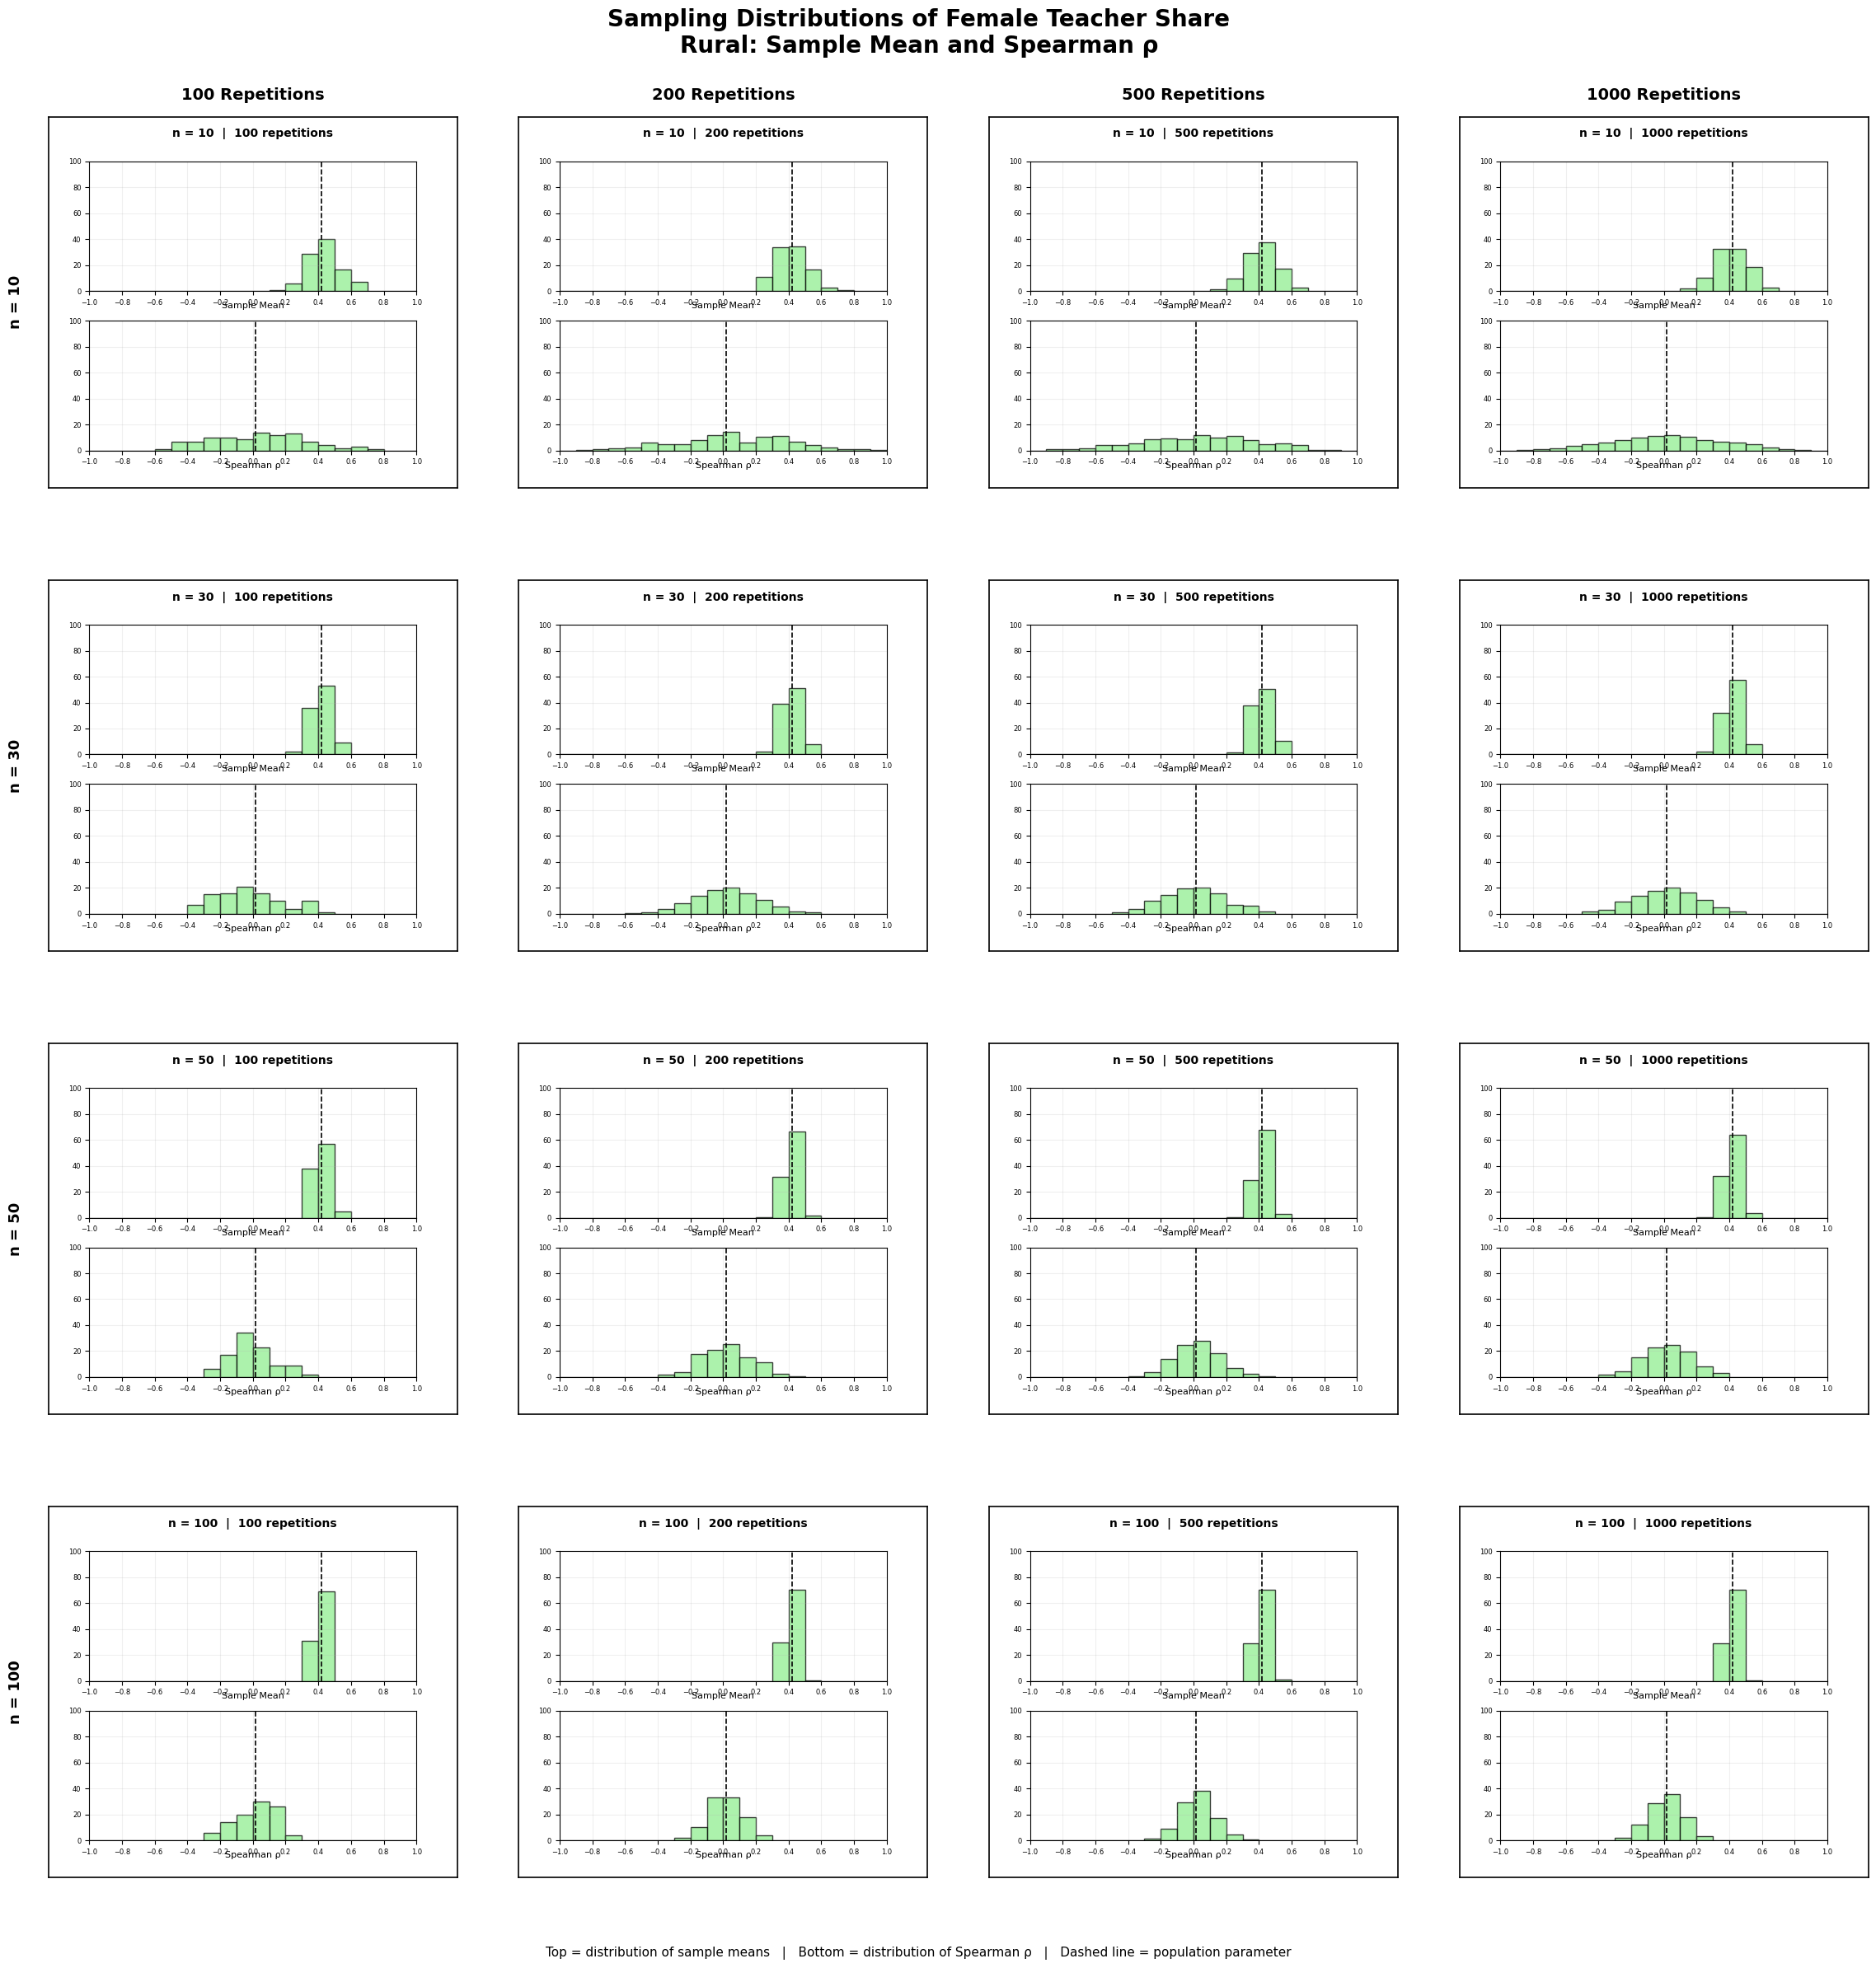

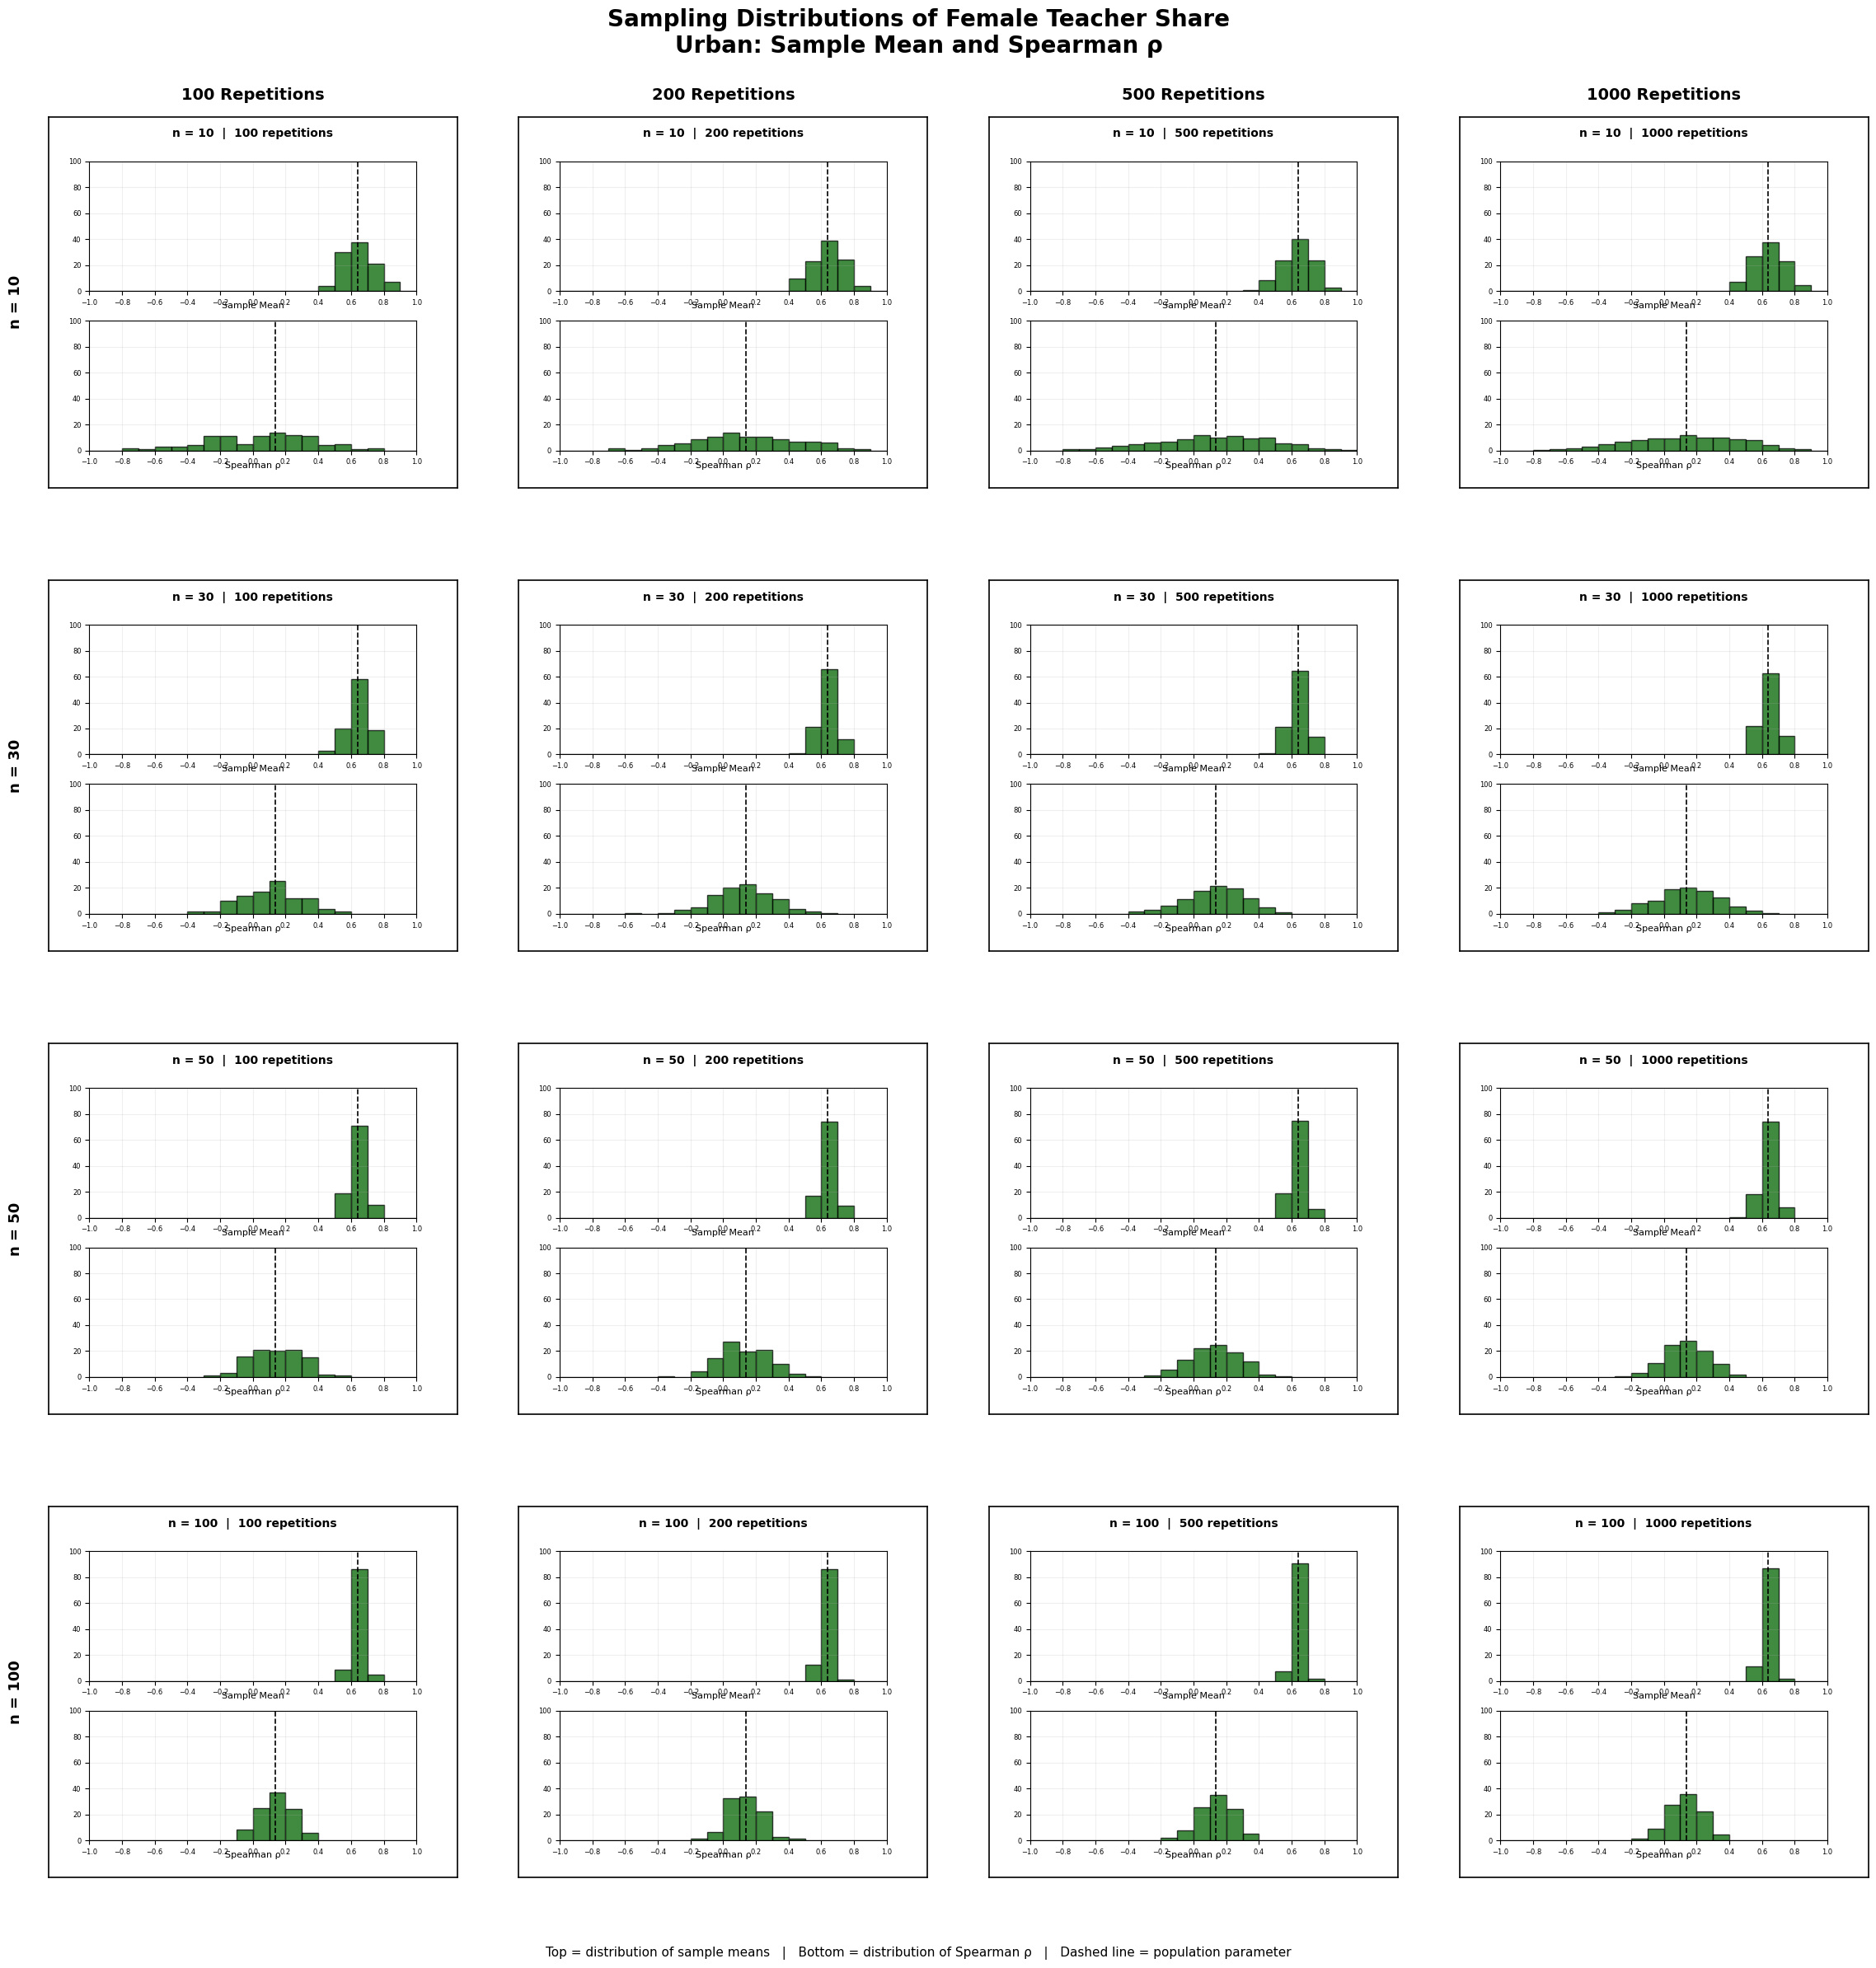

In [50]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr


# =========================================================
# SETTINGS
# =========================================================

sample_sizes = [10, 30, 50, 100]
repetitions = [100, 200, 500, 1000]

# Fixed random seed
rng = np.random.default_rng(42)


# =========================================================
# VARIABLES IN combined_gender_data
# =========================================================

group_variable = "rural_urban"

mean_variable = "female_teacher_share"

correlation_x = "female_teacher_share"
correlation_y = "girls_enrolment_ratio"


# =========================================================
# COLORS
# =========================================================

plot_colors = {
    "Rural": "#90EE90",
    "Urban": "#006400"
}


# =========================================================
# PREPARE DATA
# =========================================================

analysis_columns = [
    group_variable,
    mean_variable,
    correlation_y
]

analysis_data = (
    combined_gender_data[analysis_columns]
    .dropna()
    .copy()
)


populations = {

    "Rural": analysis_data[
        analysis_data[group_variable] == "Rural"
    ].reset_index(drop=True),

    "Urban": analysis_data[
        analysis_data[group_variable] == "Urban"
    ].reset_index(drop=True)
}


# =========================================================
# CREATE IMAGES FOLDER
# =========================================================

os.makedirs("images", exist_ok=True)


# =========================================================
# FIXED AXIS SETTINGS
# =========================================================

# ---------------------------------------------------------
# BOTH SAMPLE MEAN AND SPEARMAN USE THE SAME SCALE
# ---------------------------------------------------------

X_LIM = (-1, 1)
Y_LIM = (0, 100)

X_TICKS = np.arange(
    -1,
    1.01,
    0.2
)

Y_TICKS = np.arange(
    0,
    101,
    20
)


# ---------------------------------------------------------
# SAME BINS FOR BOTH DISTRIBUTIONS
# ---------------------------------------------------------

bins = np.linspace(
    -1,
    1,
    21
)


# =========================================================
# LOOP THROUGH RURAL AND URBAN
# =========================================================

for population_name, population_df in populations.items():

    # =====================================================
    # POPULATION SIZE
    # =====================================================

    N = len(population_df)

    if N < max(sample_sizes):

        raise ValueError(
            f"{population_name} has only {N} observations, "
            f"but n={max(sample_sizes)} is required."
        )


    # =====================================================
    # CONVERT TO NUMPY ARRAYS
    # =====================================================

    female_teacher_share = population_df[
        mean_variable
    ].to_numpy(dtype=float)

    girls_ratio = population_df[
        correlation_y
    ].to_numpy(dtype=float)


    # =====================================================
    # POPULATION PARAMETERS
    # =====================================================

    # Population mean of female teacher share
    population_mean = float(
        np.mean(female_teacher_share)
    )


    # Population Spearman correlation
    population_spearman, population_p = spearmanr(
        female_teacher_share,
        girls_ratio
    )

    population_spearman = float(
        population_spearman
    )


    # =====================================================
    # GENERATE ALL SAMPLING DISTRIBUTIONS
    # =====================================================

    sampling_results = {}


    for n in sample_sizes:

        for reps in repetitions:

            sample_means = []
            sample_correlations = []


            # =================================================
            # REPEATED SAMPLING
            # =================================================

            for _ in range(reps):

                # Sample complete rows.
                # This preserves the pairing between:
                #
                # female_teacher_share
                # and
                # girls_enrolment_ratio

                sample_indices = rng.choice(
                    N,
                    size=n,
                    replace=False
                )


                # -------------------------------------------------
                # SAMPLE DATA
                # -------------------------------------------------

                sample_female_share = (
                    female_teacher_share[sample_indices]
                )

                sample_girls_ratio = (
                    girls_ratio[sample_indices]
                )


                # -------------------------------------------------
                # SAMPLE MEAN
                # -------------------------------------------------

                sample_mean = np.mean(
                    sample_female_share
                )

                sample_means.append(
                    sample_mean
                )


                # -------------------------------------------------
                # SPEARMAN CORRELATION
                # -------------------------------------------------

                sample_rho, _ = spearmanr(
                    sample_female_share,
                    sample_girls_ratio
                )

                sample_correlations.append(
                    sample_rho
                )


            # -------------------------------------------------
            # STORE RESULTS
            # -------------------------------------------------

            sampling_results[(n, reps)] = {

                "means": np.array(
                    sample_means
                ),

                "correlations": np.array(
                    sample_correlations
                )
            }


    # =====================================================
    # CREATE 4 × 4 OUTER GRID
    #
    # ROWS    = SAMPLE SIZE
    # COLUMNS = REPETITIONS
    #
    # EACH CELL:
    #       TOP    = SAMPLE MEAN DISTRIBUTION
    #       BOTTOM = SPEARMAN ρ DISTRIBUTION
    # =====================================================

    fig, axes = plt.subplots(
        nrows=4,
        ncols=4,
        figsize=(24, 24)
    )


    # =====================================================
    # LOOP THROUGH 16 CELLS
    # =====================================================

    for row, n in enumerate(sample_sizes):

        for col, reps in enumerate(repetitions):

            # -------------------------------------------------
            # OUTER CELL
            # -------------------------------------------------

            cell_ax = axes[row, col]

            cell_ax.set_xticks([])
            cell_ax.set_yticks([])

            cell_ax.set_facecolor("white")

            for spine in cell_ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(1.2)


            # =================================================
            # GET RESULTS
            # =================================================

            results = sampling_results[
                (n, reps)
            ]

            sample_means = results[
                "means"
            ]

            sample_correlations = results[
                "correlations"
            ]


            # =================================================
            # CREATE TWO VERTICAL INSET PLOTS
            # =================================================

            # TOP = SAMPLE MEAN
            mean_ax = cell_ax.inset_axes(
                [0.10, 0.53, 0.80, 0.35]
            )

            # BOTTOM = SPEARMAN CORRELATION
            corr_ax = cell_ax.inset_axes(
                [0.10, 0.10, 0.80, 0.35]
            )


            # =================================================
            # TOP PLOT
            # DISTRIBUTION OF SAMPLE MEANS
            # =================================================

            # IMPORTANT:
            # Same -1 to +1 bins as Spearman

            counts, bin_edges = np.histogram(
                sample_means,
                bins=bins
            )

            relative_frequency = (
                counts / len(sample_means)
            ) * 100

            mean_ax.bar(
                bin_edges[:-1],
                relative_frequency,
                width=np.diff(bin_edges),
                align="edge",
                color=plot_colors[
                    population_name
                ],
                edgecolor="black",
                alpha=0.75
            )


            # Population mean
            mean_ax.axvline(
                population_mean,
                color="black",
                linestyle="--",
                linewidth=1.2
            )


            # -------------------------------------------------
            # SAME SCALE — SAMPLE MEAN
            # -------------------------------------------------

            mean_ax.set_xlim(
                *X_LIM
            )

            mean_ax.set_ylim(
                *Y_LIM
            )

            mean_ax.set_xticks(
                X_TICKS
            )

            mean_ax.set_yticks(
                Y_TICKS
            )

            mean_ax.tick_params(
                axis="both",
                labelsize=6
            )

            mean_ax.grid(
                True,
                which="major",
                axis="both",
                alpha=0.2
            )


            # =================================================
            # BOTTOM PLOT
            # DISTRIBUTION OF SPEARMAN ρ
            # =================================================

            counts, bin_edges = np.histogram(
                sample_correlations,
                bins=bins
            )

            relative_frequency = (
                counts / len(sample_correlations)
            ) * 100

            corr_ax.bar(
                bin_edges[:-1],
                relative_frequency,
                width=np.diff(bin_edges),
                align="edge",
                color=plot_colors[
                    population_name
                ],
                edgecolor="black",
                alpha=0.75
            )


            # Population Spearman rho
            corr_ax.axvline(
                population_spearman,
                color="black",
                linestyle="--",
                linewidth=1.2
            )


            # -------------------------------------------------
            # SAME SCALE — SPEARMAN
            # -------------------------------------------------

            corr_ax.set_xlim(
                *X_LIM
            )

            corr_ax.set_ylim(
                *Y_LIM
            )

            corr_ax.set_xticks(
                X_TICKS
            )

            corr_ax.set_yticks(
                Y_TICKS
            )

            corr_ax.tick_params(
                axis="both",
                labelsize=6
            )

            corr_ax.grid(
                True,
                which="major",
                axis="both",
                alpha=0.2
            )


            # =================================================
            # LABELS INSIDE CELL
            # =================================================

            cell_ax.text(
                0.5,
                0.97,
                f"n = {n}  |  {reps} repetitions",
                transform=cell_ax.transAxes,
                ha="center",
                va="top",
                fontsize=10,
                fontweight="bold"
            )


            # Top label
            cell_ax.text(
                0.5,
                0.49,
                "Sample Mean",
                transform=cell_ax.transAxes,
                ha="center",
                va="center",
                fontsize=8
            )


            # Bottom label
            cell_ax.text(
                0.5,
                0.06,
                "Spearman ρ",
                transform=cell_ax.transAxes,
                ha="center",
                va="center",
                fontsize=8
            )


    # =====================================================
    # COLUMN HEADERS
    # =====================================================

    for col, reps in enumerate(repetitions):

        axes[0, col].set_title(
            f"{reps} Repetitions",
            fontsize=14,
            fontweight="bold",
            pad=15
        )


    # =====================================================
    # ROW LABELS
    # =====================================================

    for row, n in enumerate(sample_sizes):

        axes[row, 0].text(
            -0.08,
            0.5,
            f"n = {n}",
            transform=axes[row, 0].transAxes,
            rotation=90,
            ha="center",
            va="center",
            fontsize=13,
            fontweight="bold"
        )


    # =====================================================
    # OVERALL TITLE
    # =====================================================

    fig.suptitle(
        "Sampling Distributions of Female Teacher Share\n"
        f"{population_name}: Sample Mean and Spearman ρ",
        fontsize=20,
        fontweight="bold",
        y=0.995
    )


    # =====================================================
    # EXPLANATION
    # =====================================================

    fig.text(
        0.5,
        0.01,
        "Top = distribution of sample means   |   "
        "Bottom = distribution of Spearman ρ   |   "
        "Dashed line = population parameter",
        ha="center",
        fontsize=11
    )


    # =====================================================
    # LAYOUT
    # =====================================================

    plt.subplots_adjust(
        left=0.06,
        right=0.98,
        top=0.94,
        bottom=0.05,
        wspace=0.15,
        hspace=0.25
    )


    # =====================================================
    # SAVE AS SVG
    # =====================================================

    filename = (
        f"sampling_distributions_female_teacher_share_"
        f"{population_name.lower()}.svg"
    )

    plt.savefig(
        os.path.join(
            "images",
            filename
        ),
        format="svg",
        bbox_inches="tight"
    )


    # =====================================================
    # DISPLAY
    # =====================================================

    plt.show()
    plt.close()


UTTAR PRADESH - RURAL — RANDOM SAMPLE OF 50

MEAN COMPARISON
Female Teacher Share
  Population Mean : 0.4409
  Sample Mean     : 0.5604
  Error           : +0.1195

Girls' Enrolment Ratio
  Population Mean : 0.4904
  Sample Mean     : 0.5148
  Error           : +0.0244

CORRELATION COMPARISON
Spearman ρ
  Population ρ    : 0.0395
  Sample ρ        : 0.4789
  Error           : +0.4394

Pearson r            : 0.3706
Spearman ρ           : 0.4789
Kendall τ-b          : 0.3535
Distance Correlation : 0.4200
Trend       : Positive


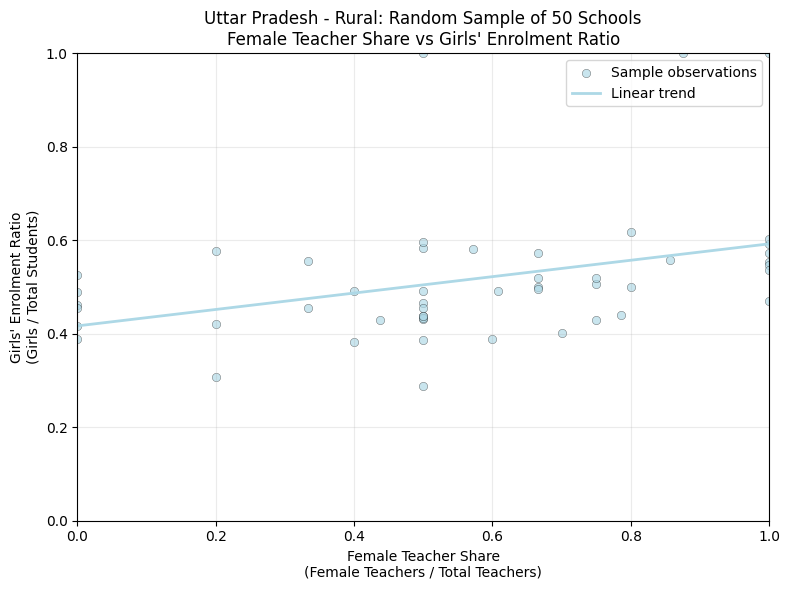


UTTAR PRADESH - URBAN — RANDOM SAMPLE OF 50

MEAN COMPARISON
Female Teacher Share
  Population Mean : 0.6392
  Sample Mean     : 0.6261
  Error           : -0.0131

Girls' Enrolment Ratio
  Population Mean : 0.4706
  Sample Mean     : 0.4857
  Error           : +0.0152

CORRELATION COMPARISON
Spearman ρ
  Population ρ    : 0.2073
  Sample ρ        : 0.2333
  Error           : +0.0260

Pearson r            : 0.2517
Spearman ρ           : 0.2333
Kendall τ-b          : 0.1643
Distance Correlation : 0.2942
Trend       : Positive


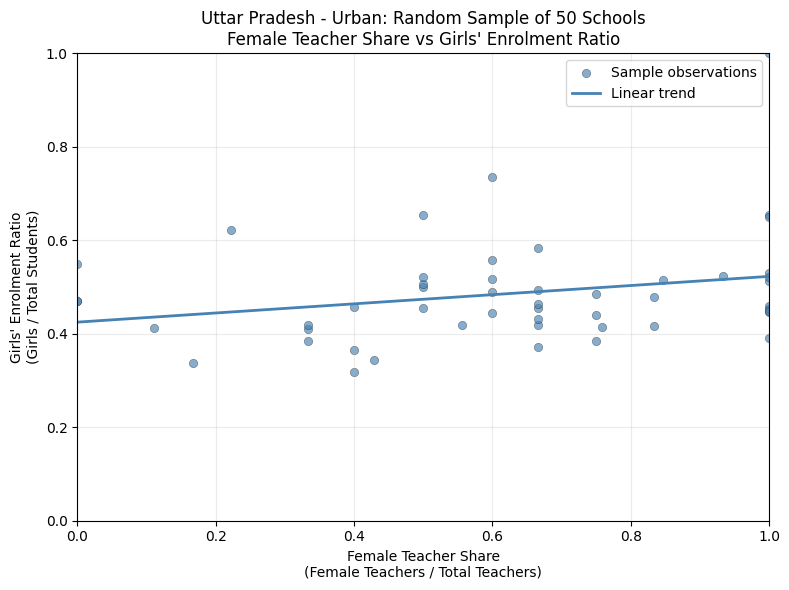


MAHARASHTRA - RURAL — RANDOM SAMPLE OF 50

MEAN COMPARISON
Female Teacher Share
  Population Mean : 0.3571
  Sample Mean     : 0.4576
  Error           : +0.1005

Girls' Enrolment Ratio
  Population Mean : 0.4883
  Sample Mean     : 0.4836
  Error           : -0.0048

CORRELATION COMPARISON
Spearman ρ
  Population ρ    : -0.0360
  Sample ρ        : -0.0527
  Error           : -0.0167

Pearson r            : 0.0402
Spearman ρ           : -0.0527
Kendall τ-b          : -0.0333
Distance Correlation : 0.2199
Trend       : Positive


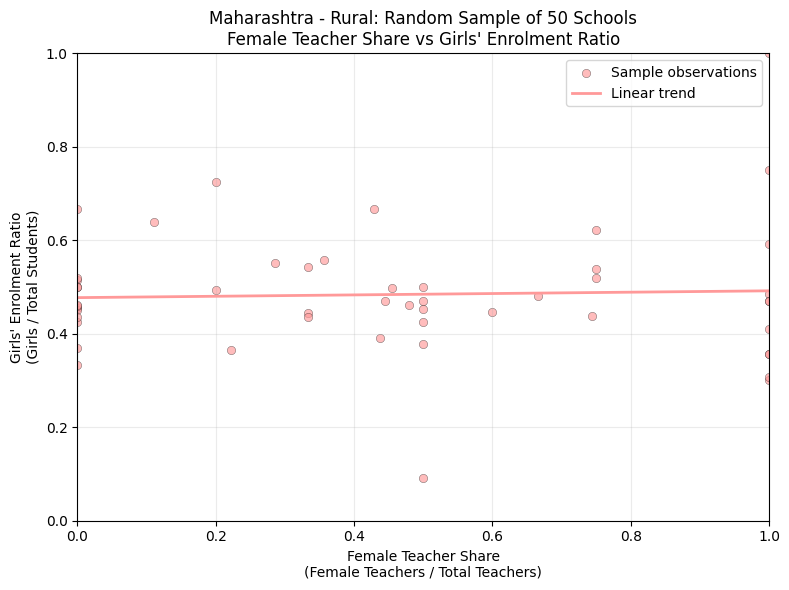


MAHARASHTRA - URBAN — RANDOM SAMPLE OF 50

MEAN COMPARISON
Female Teacher Share
  Population Mean : 0.6393
  Sample Mean     : 0.6944
  Error           : +0.0551

Girls' Enrolment Ratio
  Population Mean : 0.4756
  Sample Mean     : 0.4663
  Error           : -0.0093

CORRELATION COMPARISON
Spearman ρ
  Population ρ    : 0.0301
  Sample ρ        : 0.3242
  Error           : +0.2941

Pearson r            : 0.1877
Spearman ρ           : 0.3242
Kendall τ-b          : 0.2349
Distance Correlation : 0.3046
Trend       : Positive


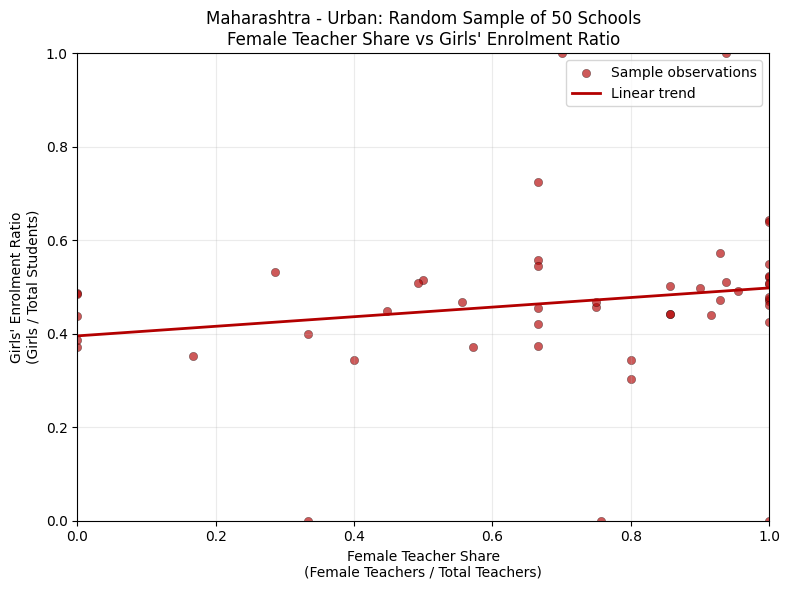


COMBINED - RURAL — RANDOM SAMPLE OF 50

MEAN COMPARISON
Female Teacher Share
  Population Mean : 0.4188
  Sample Mean     : 0.4671
  Error           : +0.0483

Girls' Enrolment Ratio
  Population Mean : 0.4899
  Sample Mean     : 0.4923
  Error           : +0.0024

CORRELATION COMPARISON
Spearman ρ
  Population ρ    : 0.0168
  Sample ρ        : 0.1120
  Error           : +0.0952

Pearson r            : 0.2000
Spearman ρ           : 0.1120
Kendall τ-b          : 0.0740
Distance Correlation : 0.2294
Trend       : Positive


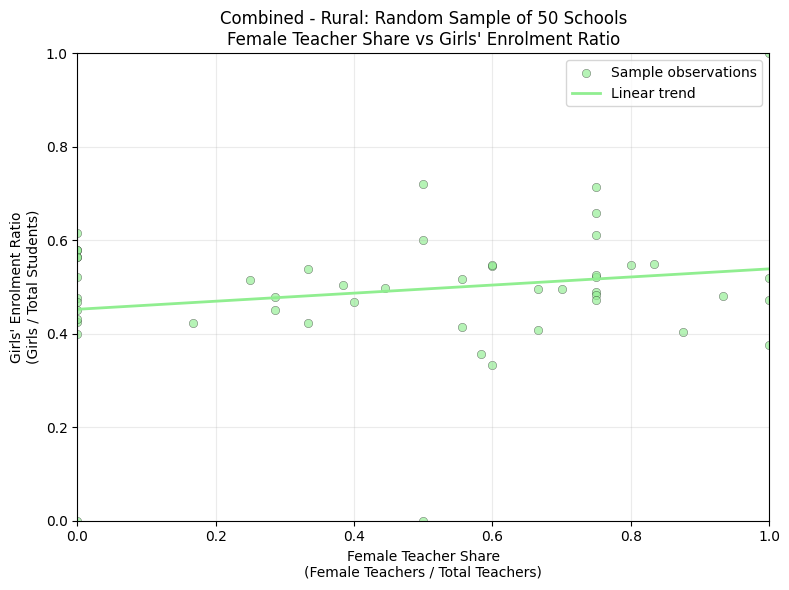


COMBINED - URBAN — RANDOM SAMPLE OF 50

MEAN COMPARISON
Female Teacher Share
  Population Mean : 0.6392
  Sample Mean     : 0.5932
  Error           : -0.0461

Girls' Enrolment Ratio
  Population Mean : 0.4726
  Sample Mean     : 0.4259
  Error           : -0.0467

CORRELATION COMPARISON
Spearman ρ
  Population ρ    : 0.1370
  Sample ρ        : 0.1851
  Error           : +0.0481

Pearson r            : 0.3185
Spearman ρ           : 0.1851
Kendall τ-b          : 0.1215
Distance Correlation : 0.3752
Trend       : Positive


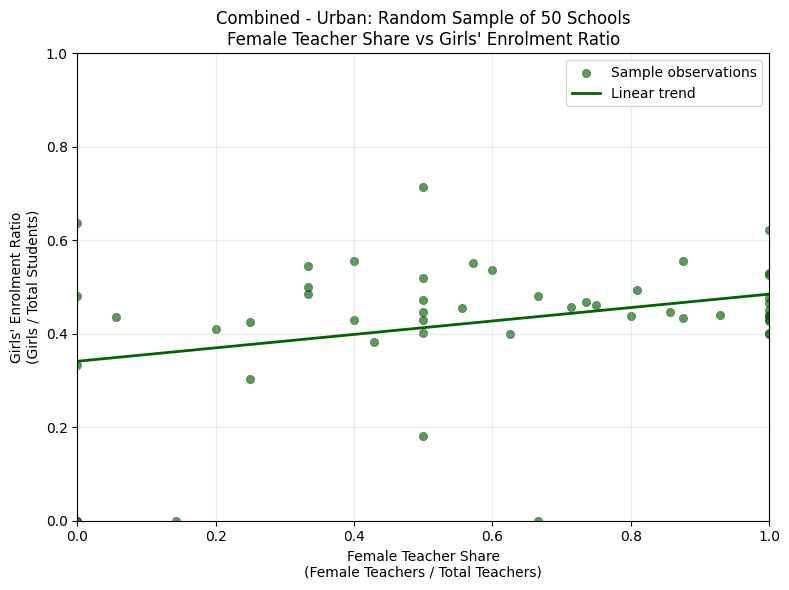

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau
from scipy.spatial.distance import pdist, squareform


# =========================================================
# Distance correlation
# =========================================================

def distance_correlation(x, y):

    x = np.asarray(x).reshape(-1, 1)
    y = np.asarray(y).reshape(-1, 1)

    # Pairwise distance matrices
    A = squareform(pdist(x))
    B = squareform(pdist(y))

    # Double-centering
    A_centered = (
        A
        - A.mean(axis=1, keepdims=True)
        - A.mean(axis=0, keepdims=True)
        + A.mean()
    )

    B_centered = (
        B
        - B.mean(axis=1, keepdims=True)
        - B.mean(axis=0, keepdims=True)
        + B.mean()
    )

    # Distance covariance and variances
    dcov2 = np.mean(A_centered * B_centered)

    dvar_x = np.mean(A_centered ** 2)
    dvar_y = np.mean(B_centered ** 2)

    if dvar_x == 0 or dvar_y == 0:
        return 0.0

    return np.sqrt(
        max(dcov2, 0) / np.sqrt(dvar_x * dvar_y)
    )


# =========================================================
# Settings
# =========================================================

sample_size = 50


# =========================================================
# Standardized colors
# =========================================================

plot_colors = {
    "Uttar Pradesh - Rural": "#ADD8E6",   # Light Blue
    "Uttar Pradesh - Urban": "#4682B4",   # Dark Blue
    "Maharashtra - Rural": "#FF9999",     # Light Red
    "Maharashtra - Urban": "#B30000",     # Dark Red
    "Combined - Rural": "#90EE90",        # Light Green
    "Combined - Urban": "#006400"         # Dark Green
}


# =========================================================
# Define populations: State × Rural/Urban
# =========================================================

populations = {

    "Uttar Pradesh - Rural": combined_gender_data[
        (combined_gender_data["State"] == "Uttar Pradesh") &
        (combined_gender_data["rural_urban"] == "Rural")
    ][
        ["female_teacher_share", "girls_enrolment_ratio"]
    ].dropna(),

    "Uttar Pradesh - Urban": combined_gender_data[
        (combined_gender_data["State"] == "Uttar Pradesh") &
        (combined_gender_data["rural_urban"] == "Urban")
    ][
        ["female_teacher_share", "girls_enrolment_ratio"]
    ].dropna(),

    "Maharashtra - Rural": combined_gender_data[
        (combined_gender_data["State"] == "Maharashtra") &
        (combined_gender_data["rural_urban"] == "Rural")
    ][
        ["female_teacher_share", "girls_enrolment_ratio"]
    ].dropna(),

    "Maharashtra - Urban": combined_gender_data[
        (combined_gender_data["State"] == "Maharashtra") &
        (combined_gender_data["rural_urban"] == "Urban")
    ][
        ["female_teacher_share", "girls_enrolment_ratio"]
    ].dropna(),

    "Combined - Rural": combined_gender_data[
        combined_gender_data["rural_urban"] == "Rural"
    ][
        ["female_teacher_share", "girls_enrolment_ratio"]
    ].dropna(),

    "Combined - Urban": combined_gender_data[
        combined_gender_data["rural_urban"] == "Urban"
    ][
        ["female_teacher_share", "girls_enrolment_ratio"]
    ].dropna()
}


# =========================================================
# Randomly draw one sample of 50 from each population
# =========================================================

samples = {}

for population_name, population in populations.items():

    sample = population.sample(
        n=sample_size,
        random_state=42
    )

    samples[population_name] = sample


# =========================================================
# Calculate correlations, means and errors
# =========================================================

for population_name, sample in samples.items():

    x = sample["female_teacher_share"].to_numpy()
    y = sample["girls_enrolment_ratio"].to_numpy()

    # Color for this group
    plot_color = plot_colors[population_name]


    # -----------------------------------------------------
    # Population statistics
    # -----------------------------------------------------

    population_x_mean = populations[population_name][
        "female_teacher_share"
    ].mean()

    population_y_mean = populations[population_name][
        "girls_enrolment_ratio"
    ].mean()

    population_spearman, _ = spearmanr(
        populations[population_name]["female_teacher_share"],
        populations[population_name]["girls_enrolment_ratio"]
    )


    # -----------------------------------------------------
    # Sample statistics
    # -----------------------------------------------------

    sample_x_mean = x.mean()
    sample_y_mean = y.mean()

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)
    kendall_tau, kendall_p = kendalltau(x, y)

    # Distance correlation for the sample
    distance_corr = distance_correlation(x, y)


    # -----------------------------------------------------
    # Errors from population values
    # -----------------------------------------------------

    female_teacher_mean_error = (
        sample_x_mean - population_x_mean
    )

    girls_enrolment_mean_error = (
        sample_y_mean - population_y_mean
    )

    spearman_error = (
        spearman_rho - population_spearman
    )


    # -----------------------------------------------------
    # Linear trend line
    # -----------------------------------------------------

    slope, intercept = np.polyfit(x, y, 1)

    x_line = np.linspace(
        x.min(),
        x.max(),
        100
    )

    y_line = slope * x_line + intercept


    # =====================================================
    # Print results
    # =====================================================

    print("\n" + "=" * 70)
    print(
        f"{population_name.upper()} — "
        f"RANDOM SAMPLE OF {sample_size}"
    )
    print("=" * 70)


    # -----------------------------------------------------
    # Population vs Sample Means
    # -----------------------------------------------------

    print("\nMEAN COMPARISON")

    print(
        f"Female Teacher Share"
        f"\n  Population Mean : {population_x_mean:.4f}"
        f"\n  Sample Mean     : {sample_x_mean:.4f}"
        f"\n  Error           : {female_teacher_mean_error:+.4f}"
    )

    print(
        f"\nGirls' Enrolment Ratio"
        f"\n  Population Mean : {population_y_mean:.4f}"
        f"\n  Sample Mean     : {sample_y_mean:.4f}"
        f"\n  Error           : {girls_enrolment_mean_error:+.4f}"
    )


    # -----------------------------------------------------
    # Correlation comparison
    # -----------------------------------------------------

    print("\nCORRELATION COMPARISON")

    print(
        f"Spearman ρ"
        f"\n  Population ρ    : {population_spearman:.4f}"
        f"\n  Sample ρ        : {spearman_rho:.4f}"
        f"\n  Error           : {spearman_error:+.4f}"
    )

    print(
        f"\nPearson r            : {pearson_r:.4f}"
    )

    print(
        f"Spearman ρ           : {spearman_rho:.4f}"
    )

    print(
        f"Kendall τ-b          : {kendall_tau:.4f}"
    )

    print(
        f"Distance Correlation : {distance_corr:.4f}"
    )


    # -----------------------------------------------------
    # Trend
    # -----------------------------------------------------

    if slope > 0:
        print("Trend       : Positive")
    elif slope < 0:
        print("Trend       : Negative")
    else:
        print("Trend       : No linear trend")


    # =====================================================
    # Scatter plot
    # =====================================================

    plt.figure(figsize=(8, 6))

    plt.scatter(
        x,
        y,
        color=plot_color,
        alpha=0.65,
        edgecolor="black",
        linewidth=0.3,
        label="Sample observations"
    )


    # -----------------------------------------------------
    # Trend line
    # -----------------------------------------------------

    plt.plot(
        x_line,
        y_line,
        color=plot_color,
        linewidth=2,
        label="Linear trend"
    )


    # -----------------------------------------------------
    # Labels
    # -----------------------------------------------------

    plt.xlabel(
        "Female Teacher Share\n"
        "(Female Teachers / Total Teachers)"
    )

    plt.ylabel(
        "Girls' Enrolment Ratio\n"
        "(Girls / Total Students)"
    )

    plt.title(
        f"{population_name}: Random Sample of {sample_size} Schools\n"
        "Female Teacher Share vs Girls' Enrolment Ratio"
    )


    # -----------------------------------------------------
    # Same scales
    # -----------------------------------------------------

    plt.xlim(0, 1)
    plt.ylim(0, 1)


    # -----------------------------------------------------
    # Grid and legend
    # -----------------------------------------------------

    plt.grid(
        alpha=0.25
    )

    plt.legend()


    # -----------------------------------------------------
    # Final formatting
    # -----------------------------------------------------

    plt.tight_layout()
    plt.show()
    plt.close()

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sample_sizes = [10, 20, 30, 50, 100]
repetitions = 100

populations = {
    "Combined Rural": combined_gender_data[
        combined_gender_data["rural_urban"] == "Rural"
    ]["female_teacher_share"].dropna(),

    "Combined Urban": combined_gender_data[
        combined_gender_data["rural_urban"] == "Urban"
    ]["female_teacher_share"].dropna()
}

rng = np.random.default_rng(42)

results = []

for population_name, population in populations.items():

    # Population standard deviation
    population_sd = population.std(ddof=0)

    for n in sample_sizes:

        # -----------------------------
        # Theoretical standard error
        # -----------------------------
        theoretical_se = population_sd / np.sqrt(n)

        # -----------------------------
        # Empirical sampling distribution
        # -----------------------------
        sample_means = []

        for _ in range(repetitions):

            sample = rng.choice(
                population.to_numpy(),
                size=n,
                replace=False
            )

            sample_mean = sample.mean()
            sample_means.append(sample_mean)

        # SD of the 100 sample means
        empirical_sd = np.std(sample_means, ddof=1)

        results.append({
            "Population": population_name,
            "Sample Size": n,
            "Population SD": population_sd,
            "Theoretical SE": theoretical_se,
            "Empirical SD": empirical_sd
        })

se_results = pd.DataFrame(results)

print(se_results)

       Population  Sample Size  Population SD  Theoretical SE  Empirical SD
0  Combined Rural           10       0.318192        0.100621      0.095731
1  Combined Rural           20       0.318192        0.071150      0.067445
2  Combined Rural           30       0.318192        0.058094      0.055811
3  Combined Rural           50       0.318192        0.044999      0.043536
4  Combined Rural          100       0.318192        0.031819      0.031666
5  Combined Urban           10       0.310297        0.098124      0.089566
6  Combined Urban           20       0.310297        0.069384      0.069448
7  Combined Urban           30       0.310297        0.056652      0.057566
8  Combined Urban           50       0.310297        0.043883      0.039082
9  Combined Urban          100       0.310297        0.031030      0.030128


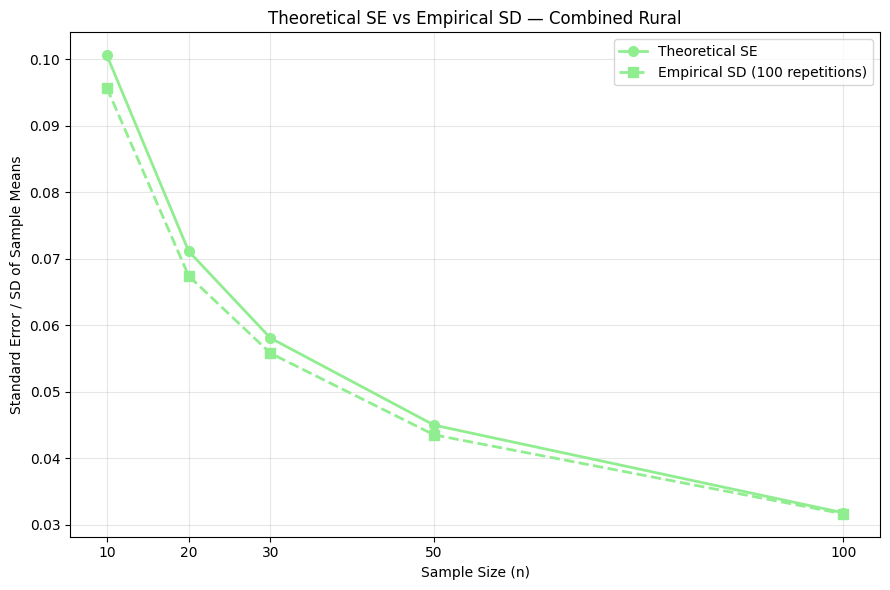

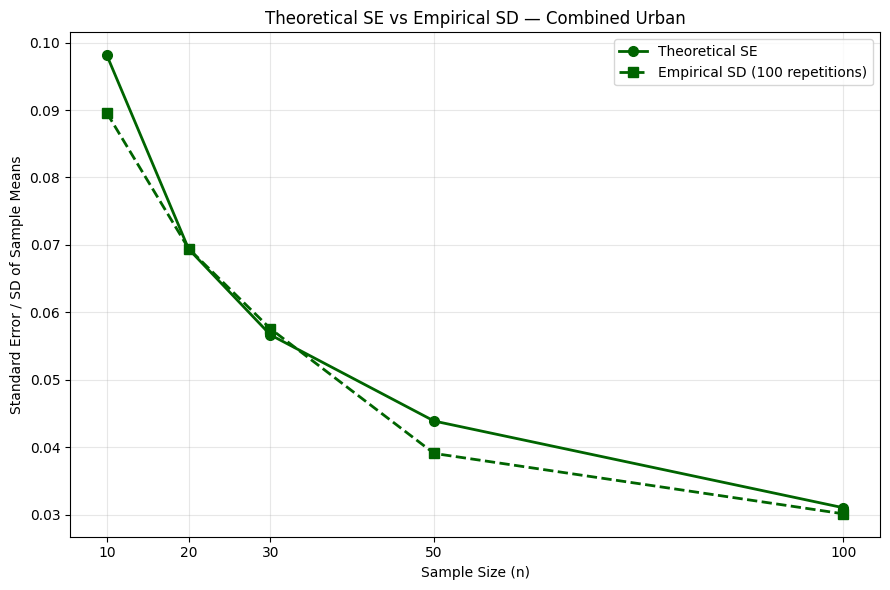

In [25]:
# Standard colors
population_colors = {
    "Combined Rural": "#90EE90",
    "Combined Urban": "#006400"
}

for population_name in ["Combined Rural", "Combined Urban"]:

    data = se_results[
        se_results["Population"] == population_name
    ]

    color = population_colors[population_name]

    plt.figure(figsize=(9, 6))

    # Theoretical SE
    plt.plot(
        data["Sample Size"],
        data["Theoretical SE"],
        marker="o",
        linestyle="-",
        color=color,
        linewidth=2,
        markersize=7,
        label="Theoretical SE"
    )

    # Empirical SD
    plt.plot(
        data["Sample Size"],
        data["Empirical SD"],
        marker="s",
        linestyle="--",
        color=color,
        linewidth=2,
        markersize=7,
        label="Empirical SD (100 repetitions)"
    )

    plt.xlabel("Sample Size (n)")
    plt.ylabel("Standard Error / SD of Sample Means")
    plt.title(f"Theoretical SE vs Empirical SD — {population_name}")

    plt.xticks(sample_sizes)

    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# Intuition: Mean vs. Correlation

## 1. Mean (For One Variable)

**Process:** Sample $\rightarrow$ Collect values $\rightarrow$ Aggregate them

For a single variable, given sample observations $X_1, X_2, X_3, \ldots, X_n$, calculate the sample mean as:

$$\bar{X} = \frac{X_1 + X_2 + \dots + X_n}{n}$$

> **Intuition:** The phrase *"we add the points"* captures this process accurately.

---

## 2. Correlation (For Two Variables)

For correlation, each observation is a **paired measurement**:

$$(X_1, Y_1), (X_2, Y_2), (X_3, Y_3), \ldots, (X_n, Y_n)$$

Because observations are linked, we **cannot** sample $X$ and $Y$ separately; we must sample the joint pairs (rows).

---

## 3. The "AND" Conceptual Model

The intuition behind combining observations using "AND":

* **Mean:** $X_1$ **AND** $X_2$ **AND** $X_3 \dots$ contribute to the estimate of $X$'s mean.
* **Correlation:** $(X_1 \text{ AND } Y_1)$, $(X_2 \text{ AND } Y_2)$, $(X_3 \text{ AND } Y_3) \dots$ contribute to the estimate of the relationship between $X$ and $Y$.


Sampling distribution: Any statistic calculated from repeated random samples has a sampling distribution because different samples produce different statistic values.
Mean: Directly averages observations, so the classical CLT directly explains why its sampling distribution becomes approximately normal as \(n\) increases.
Variance: Aggregates squared deviations from the mean; its sampling distribution becomes more concentrated as sample size increases.
Correlation: Pearson correlation aggregates the paired relationship between \(X\) and \(Y\); intuitively, it can be viewed as averaging products of paired standardized deviations.
Key observation: the correlation experiment showed the same CLT-like behavior—larger \(n\) produced a narrower, more stable sampling distribution around the population correlation.

* Sampling distribution: Any statistic calculated from repeated random samples has a sampling distribution because different samples produce different statistic values.
* Mean: Directly averages observations, so the classical CLT directly explains why its sampling distribution becomes approximately normal as $n$ increases.
* Variance: Aggregates squared deviations from the mean; its sampling distribution becomes more concentrated as sample size increases.
* Correlation: Pearson correlation aggregates the paired relationship between $X$ and $Y$; intuitively, it can be viewed as averaging products of paired standardized deviations.
* Key observation: the correlation experiment showed the same CLT-like behavior—larger $n$ produced a narrower, more stable sampling distribution around the population correlation.

Statistics can all have sampling distributions, but the way they use sample information determines how those sampling distributions behave. Correlation aggregates information from all paired observations, which is why its sampling distribution can show CLT-like stabilization as sample size increases.

In [26]:
import numpy as np
import pandas as pd

sample_sizes = [10, 30, 50, 100]
repetitions = [100, 200, 500, 1000]

rng = np.random.default_rng(42)

populations = {
    "Combined Rural": combined_gender_data[
        combined_gender_data["rural_urban"] == "Rural"
    ]["female_teacher_share"].dropna().to_numpy(),

    "Combined Urban": combined_gender_data[
        combined_gender_data["rural_urban"] == "Urban"
    ]["female_teacher_share"].dropna().to_numpy()
}

results = []

for population_name, population in populations.items():

    true_mean = population.mean()

    for n in sample_sizes:

        for reps in repetitions:

            sample_means = []

            # -----------------------------
            # 1. Random sampling
            # 2. Calculate sample mean
            # -----------------------------

            for _ in range(reps):

                sample = rng.choice(
                    population,
                    size=n,
                    replace=False
                )

                sample_means.append(sample.mean())

            sample_means = np.array(sample_means)

            # ---------------------------------------
            # 3. How far do sample means fall
            #    from the true population mean?
            # ---------------------------------------

            errors = sample_means - true_mean

            # ---------------------------------------
            # 4. Empirically construct an interval
            #    containing the central 95% of errors
            # ---------------------------------------

            lower_error = np.percentile(errors, 2.5)
            upper_error = np.percentile(errors, 97.5)

            # ---------------------------------------
            # 5. Build interval around EACH
            #    sample mean and check coverage
            # ---------------------------------------

            lower_bounds = sample_means + lower_error
            upper_bounds = sample_means + upper_error

            contains_true_mean = (
                (lower_bounds <= true_mean) &
                (true_mean <= upper_bounds)
            )

            covered = contains_true_mean.sum()

            coverage = (covered / reps) * 100

            results.append({
                "Population": population_name,
                "Sample Size": n,
                "Repetitions": reps,
                "True Mean": true_mean,
                "Samples Containing True Mean": covered,
                "Total Samples": reps,
                "Coverage (%)": coverage
            })

empirical_ci_df = pd.DataFrame(results)

print(empirical_ci_df.to_string(index=False))

    Population  Sample Size  Repetitions  True Mean  Samples Containing True Mean  Total Samples  Coverage (%)
Combined Rural           10          100   0.418812                            89            100          89.0
Combined Rural           10          200   0.418812                           191            200          95.5
Combined Rural           10          500   0.418812                           475            500          95.0
Combined Rural           10         1000   0.418812                           946           1000          94.6
Combined Rural           30          100   0.418812                            93            100          93.0
Combined Rural           30          200   0.418812                           189            200          94.5
Combined Rural           30          500   0.418812                           476            500          95.2
Combined Rural           30         1000   0.418812                           938           1000          93.8
C

In [27]:
import numpy as np
import pandas as pd

sample_size = 30
total_repetitions = 1000
derivation_repetitions = 500
test_repetitions = 500

rng = np.random.default_rng(42)

populations = {
    "Combined Rural": combined_gender_data[
        combined_gender_data["rural_urban"] == "Rural"
    ]["female_teacher_share"].dropna().to_numpy(),

    "Combined Urban": combined_gender_data[
        combined_gender_data["rural_urban"] == "Urban"
    ]["female_teacher_share"].dropna().to_numpy()
}

sample_level_results = []

for population_name, population in populations.items():

    true_mean = population.mean()

    # ---------------------------------------
    # 1. Generate 1000 random samples
    #    of size 30
    # ---------------------------------------

    sample_means = []

    for _ in range(total_repetitions):

        sample = rng.choice(
            population,
            size=sample_size,
            replace=False
        )

        sample_means.append(sample.mean())

    sample_means = np.array(sample_means)

    # ---------------------------------------
    # 2. Split into:
    #    First 500 → derive error range
    #    Next 500  → test coverage
    # ---------------------------------------

    derivation_means = sample_means[:derivation_repetitions]
    test_means = sample_means[derivation_repetitions:]

    # ---------------------------------------
    # 3. Calculate errors using ONLY
    #    the first 500 samples
    # ---------------------------------------

    derivation_errors = derivation_means - true_mean

    # ---------------------------------------
    # 4. Derive central 95% empirical
    #    range of errors
    # ---------------------------------------

    lower_error = np.percentile(
        derivation_errors, 2.5
    )

    upper_error = np.percentile(
        derivation_errors, 97.5
    )

    # ---------------------------------------
    # 5. Construct intervals around ONLY
    #    the next 500 sample means
    # ---------------------------------------

    lower_bounds = test_means + lower_error
    upper_bounds = test_means + upper_error

    # ---------------------------------------
    # 6. Check whether true mean is
    #    contained in each test interval
    # ---------------------------------------

    contains_true_mean = (
        (lower_bounds <= true_mean) &
        (true_mean <= upper_bounds)
    )

    covered = contains_true_mean.sum()

    coverage = (
        covered / test_repetitions
    ) * 100

    # ---------------------------------------
    # 7. Store results for the 500
    #    independent test samples
    # ---------------------------------------

    for i in range(test_repetitions):

        sample_level_results.append({
            "Population": population_name,
            "Sample Size": sample_size,
            "Sample Number": i + 501,
            "Sample Mean": test_means[i],
            "Lower Error": lower_error,
            "Upper Error": upper_error,
            "Lower CI": lower_bounds[i],
            "Upper CI": upper_bounds[i],
            "True Mean": true_mean,
            "Contains True Mean": contains_true_mean[i]
        })

    # ---------------------------------------
    # 8. Print summary for each population
    # ---------------------------------------

    print(f"\n{population_name}")
    print("-" * 50)
    print(f"True Mean:       {true_mean:.6f}")
    print(f"Lower Error:     {lower_error:.6f}")
    print(f"Upper Error:     {upper_error:.6f}")
    print(f"Interval Width:  {upper_error - lower_error:.6f}")
    print(f"Covered:         {covered}/{test_repetitions}")
    print(f"Coverage:        {coverage:.2f}%")

# ---------------------------------------
# 9. Create sample-level DataFrame
# ---------------------------------------

sample_level_ci_df = pd.DataFrame(sample_level_results)

# ---------------------------------------
# 10. Print all 1000 test intervals
# ---------------------------------------

# print("\nSample-level results:")
# print(sample_level_ci_df.to_string(index=False))

# ---------------------------------------
# 11. Coverage summary
# ---------------------------------------

coverage_summary = (
    sample_level_ci_df
    .groupby("Population")["Contains True Mean"]
    .agg(
        True_Count="sum",
        Total_Count="count"
    )
    .reset_index()
)

coverage_summary["Coverage (%)"] = (
    coverage_summary["True_Count"] /
    coverage_summary["Total_Count"] * 100
)

print("\nCoverage summary:")
print(coverage_summary.to_string(index=False))


Combined Rural
--------------------------------------------------
True Mean:       0.418812
Lower Error:     -0.115451
Upper Error:     0.106240
Interval Width:  0.221691
Covered:         476/500
Coverage:        95.20%

Combined Urban
--------------------------------------------------
True Mean:       0.639227
Lower Error:     -0.129033
Upper Error:     0.092637
Interval Width:  0.221670
Covered:         475/500
Coverage:        95.00%

Coverage summary:
    Population  True_Count  Total_Count  Coverage (%)
Combined Rural         476          500          95.2
Combined Urban         475          500          95.0


```text
Random Sample
      ↓
Sample Mean
      ↓
Repeat Many Times
      ↓
Calculate Sampling Error
(Sample Mean − True Mean)
      ↓
Find Central 95% of Errors
      ↓
Use Errors as Bounds Around
the Observed Sample Mean
      ↓
≈ 95% of Intervals Contain
the True Mean
```

If we construct intervals using a range that captures the central 95% of the sampling-error distribution, then repeated application of that procedure gives approximately 95% coverage of the true population mean. We just proved the definition of C.I. and not C.I. itself

Why 95% of sampling error distribution? A sample mean can be different from the true mean. By looking at how different it can be, we can make a range around the sample mean that contains the true mean by considering the middle 95% of sampling error distribution. When we repeat this process many times, the range contains the true mean approximately 95% of the time.

In [28]:
import numpy as np
import pandas as pd

sample_size = 30
total_repetitions = 1000
test_repetitions = 500

rng = np.random.default_rng(42)

populations = {
    "Combined Rural": combined_gender_data[
        combined_gender_data["rural_urban"] == "Rural"
    ]["female_teacher_share"].dropna().to_numpy(),

    "Combined Urban": combined_gender_data[
        combined_gender_data["rural_urban"] == "Urban"
    ]["female_teacher_share"].dropna().to_numpy()
}

results = []

for population_name, population in populations.items():

    # ---------------------------------------
    # 1. Population parameters
    # ---------------------------------------

    true_mean = population.mean()
    population_sd = population.std(ddof=0)

    # ---------------------------------------
    # 2. Standard error and margin of error
    # ---------------------------------------

    standard_error = population_sd / np.sqrt(sample_size)

    margin_of_error = 1.96 * standard_error

    # ---------------------------------------
    # 3. Generate 1000 random samples
    # ---------------------------------------

    sample_means = []

    for _ in range(total_repetitions):

        sample = rng.choice(
            population,
            size=sample_size,
            replace=False
        )

        sample_means.append(sample.mean())

    sample_means = np.array(sample_means)

    # ---------------------------------------
    # 4. Use the last 500 as test samples
    # ---------------------------------------

    test_means = sample_means[500:]

    # ---------------------------------------
    # 5. Construct textbook 95% CI
    #    x̄ ± 1.96(σ/√n)
    # ---------------------------------------

    lower_ci = test_means - margin_of_error
    upper_ci = test_means + margin_of_error

    # ---------------------------------------
    # 6. Check whether true mean is
    #    contained in each CI
    # ---------------------------------------

    contains_true_mean = (
        (lower_ci <= true_mean) &
        (true_mean <= upper_ci)
    )

    covered = contains_true_mean.sum()

    coverage = covered / test_repetitions * 100

    # ---------------------------------------
    # 7. Store summary
    # ---------------------------------------

    results.append({
        "Population": population_name,
        "Sample Size": sample_size,
        "Population Mean": true_mean,
        "Population SD": population_sd,
        "Standard Error": standard_error,
        "Z": 1.96,
        "Margin of Error": margin_of_error,
        "Lower Error": -margin_of_error,
        "Upper Error": margin_of_error,
        "Interval Width": 2 * margin_of_error,
        "Covered": covered,
        "Total Test Samples": test_repetitions,
        "Coverage (%)": coverage
    })

# ---------------------------------------
# 8. Display results
# ---------------------------------------

z_ci_results = pd.DataFrame(results)

print(z_ci_results.to_string(index=False))

    Population  Sample Size  Population Mean  Population SD  Standard Error    Z  Margin of Error  Lower Error  Upper Error  Interval Width  Covered  Total Test Samples  Coverage (%)
Combined Rural           30         0.418812       0.318192        0.058094 1.96         0.113863    -0.113863     0.113863        0.227727      478                 500          95.6
Combined Urban           30         0.639227       0.310297        0.056652 1.96         0.111038    -0.111038     0.111038        0.222077      484                 500          96.8
